# Домашнее задание по нейросетям в скоринге.

**ФИО**: Сафронова Алиса Александровна

**Данные для обучения**: 
1. [Шардированные данные для нейросети](https://www.kaggle.com/datasets/ahm352/t-intensive-nn-sequence-shards)
2. [Признаки для обучения бустинга](https://www.kaggle.com/datasets/ahm352/t-intensive-features)

**Сдать нужно**: ссылку на Kaggle Notebook. Либо `.ipynb` с outputs ячеек. Воспроизводимость ноута -- большой плюс. Если нейронку обучали на других мощностях (не в kaggle), то можно сохранить модель в kaggle и добавить обученную модель через Input Kaggle для воспроизводимости. 

Если сложности с сохранением модели - нужно прикрепить `.parquet / .csv` с предсказаниями финальной версии модели

За каждый эксперимент по **1.5** балла. Максимум за тип эксперимента **3** балла. Для каждого эксперимента должна быть описана гипотеза и выводы. За невоспроизводимость/сильное переобучение/ без вывода будут штрафы.

Улучшение нейросети будем оценивать в **1** балл за каждое увеличение в **0.0075** auc бейзлайна нейросети. Например, качество улучшилось с `0.69 -> 0.707`. Это оцениваем в **2** балла. Максимум - **4** основных балла (тк качество бустинга **0.72** auc).

За каждое улучшение в **0.01 auc** сверху **0.72 auc** добавляем **1** балл. Максимум **3** балла.

Максимально можно получить **5** дополнительных баллов.

В итоге работы написать отчет с выводами проделанной работы. Интерпретация результатов, краткое описание проделанных экспериментов и идеи для дальнейшего развития этой модели.

## Разбалловка: 20 основных

| Основная часть | Баллы |
|---|---:|
| Воспроизводимость ноута / возможность инференса модели, если обучена не в Kaggle. Run All ячеек на подвыборке отрабатывает | 2 |
| EDA данных. Сформулированы гипотезы, инсайты для дальнейших экспериментов | 1.5 |
| ≥2 эксперимента с данными | 3 |
| ≥2 эксперимента с моделью (архитектурой) | 3 |
| ≥2 эксперимента с loss/обучением | 3 |
| Исследования с артефактами, есть learning curves, логирования в процессе обучения | 1.5 |
| Побито качество (harmonic mean auc) бустинга на тесте | 4 |
| Проинтерпретированы аттрибуты транзакции с помощью permutation importance | 2 |

| **Итого** | **20.00** |

| Бонус | Баллы |
|---|---:|
| Обучена нейросеть с головой для предсказания непрерывного таргета | 3 |
| Качество нейросети на тесте (по harmonic mean auc) с непрерывным таргетом не меньше исходной | 1 |
| Дополнительное улучшение качества нейросети | 3 |
| Пайплайн препроцессинг -> обучение/валидация -> эксперимент. Процесс тестирования экспериментов оформлен в виде шаблонизированного кода | 1.5 |
| Добавлен сервис логирования экспериментов (tensorboard/clearml) | 1 |
| Дополнительные методы интерпретации | 2 |
| **Максимум** | **11.5** |

Критерий **Обучена нейросеть с головой для предсказания непрерывного таргета**:
Необходимо составить самостоятельно таргет - сумму транзакций за последние 30 дней до даты заявки. Его будем считать непрерывным таргетом. Будем предсказывать этот таргет по транзакциям, которые были **до 30 дней** до заявки, чтобы не произвести даталик. 

Далее будет необходимо составить мультитаск нейросеть, которая будет предсказывать и дефолт и сумму транзакций за последние 30 дней.

Лосс, метрики выбираются самостоятельно. Но дополнительно надо измерить harmonic mean auc только по бинарным таргетам.

In [1]:
from pathlib import Path
import hashlib
import json
import random
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import polars as pl

import torch
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

SEED = 42
MAX_SEQ_LEN, BATCH_SIZE, EPOCHS = 128, 256, 3

PREBUILT_DIR = Path(
    "/kaggle/input/datasets/ahm352/t-intensive-nn-sequence-shards"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Задание:

Обучить нейросеть с качеством (harmonic auc) выше бустинга на тесте: выше `0.721359`.

Датасет для обучения тут - https://www.kaggle.com/datasets/ahm352/t-intensive-nn-sequence-shards



In [2]:
with open("/kaggle/input/datasets/ahm352/t-intensive-nn-sequence-shards/preprocessing.json", "r", encoding="utf-8") as file:
    preprocessing = json.load(file)
with open("/kaggle/input/datasets/ahm352/t-intensive-nn-sequence-shards/manifest.json", "r", encoding="utf-8") as file:
    manifest = json.load(file)

In [3]:
from torch import nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.utils.data import IterableDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import seaborn as sns

STORED_CAT_COLS = list(preprocessing["categorical_columns"])
STORED_CONT_COLS = list(preprocessing["continuous_columns"])
# Остальные признаки оставлены для домашки.
CAT_COLS = ["operation_kind", "mcc", "income_flag"]
CONT_COLS = ["amnt", "days_before"]

missing = (set(CAT_COLS) - set(STORED_CAT_COLS)) | (
    set(CONT_COLS) - set(STORED_CONT_COLS)
)

if missing:
    raise ValueError(f"Baseline-колонки отсутствуют в Dataset: {sorted(missing)}")

CAT_INDICES = np.asarray([STORED_CAT_COLS.index(c) for c in CAT_COLS])
CONT_INDICES = np.asarray([STORED_CONT_COLS.index(c) for c in CONT_COLS])

vocab_specs = preprocessing["vocabularies"]

STORED_VOCAB_SIZES = {
    column: int(vocab_specs[column]["size"]) for column in STORED_CAT_COLS
}

VOCAB_SIZES = {column: STORED_VOCAB_SIZES[column] for column in CAT_COLS}

In [4]:
def product_harmonic_auc(y_true, score, product,
                         expected_products=None):
    """Return harmonic product AUC together with its auditable table.

    Parameters
    ----------
    y_true, score, product : array-like
        Aligned targets, model scores and product labels.
    expected_products : collection or None
        Products that must participate in the harmonic mean.

    Returns
    -------
    tuple[float, pandas.DataFrame]
        Harmonic mean and the underlying per-product AUC table.
    """
    table = product_auc_table(y_true, score, product, expected_products)
    return harmonic_mean_auc(table["auc"]), table

In [5]:
def harmonic_mean_auc(values):
    """Compute the harmonic mean of product-level ROC-AUC values.

    Parameters
    ----------
    values : array-like
        One ROC-AUC value for every evaluated product.

    Returns
    -------
    float
        ``P / sum(1 / auc_p)``. A zero product AUC makes the result zero.

    Raises
    ------
    ValueError
        If the collection is empty, non-finite or outside ``[0, 1]``.
    """
    scores = np.asarray(values, dtype="float64")
    if scores.ndim != 1 or len(scores) == 0 or not np.isfinite(scores).all():
        raise ValueError("Нужен непустой конечный вектор product AUC")
    if np.any((scores < 0) | (scores > 1)):
        raise ValueError("ROC-AUC должен находиться в [0, 1]")
    if np.any(scores == 0):
        return 0.0
    return float(len(scores) / np.reciprocal(scores).sum())

In [6]:
def product_auc_table(y_true, score, product, expected_products=None):
    """Calculate ROC-AUC independently for every product.

    Parameters
    ----------
    y_true : array-like
        Binary targets.
    score : array-like
        Positive-class probabilities or monotonic decision scores.
    product : array-like
        Product label for each observation.
    expected_products : collection or None
        Products that must all be present; omission is an error.

    Returns
    -------
    pandas.DataFrame
        Columns ``product``, ``n`` and ``auc``, sorted by product.

    Raises
    ------
    ValueError
        If lengths differ or a product contains only one target class.
    """
    target, score, product = map(np.asarray, (y_true, score, product))
    if not (len(target) == len(score) == len(product)):
        raise ValueError("target, score и product должны иметь одну длину")
    frame = pd.DataFrame({"target": target, "score": score, "product": product})
    observed = set(frame["product"].unique())
    if expected_products is not None and observed != set(expected_products):
        raise ValueError(f"Набор продуктов {observed} != {set(expected_products)}")
    rows = []
    for value, group in frame.groupby("product", sort=True):
        if group["target"].nunique() != 2:
            raise ValueError(f"product={value}: ROC-AUC требует оба класса")
        rows.append({"product": value, "n": len(group),
                     "auc": roc_auc_score(group["target"], group["score"])})
    return pd.DataFrame(rows)

In [7]:
REQUIRED_SHARD_KEYS = {"app_id", "offsets", "lengths", "cats", "cont",
                       "target", "product_idx"}


## Бейзлайн

Ниже — исходная модель: общий LSTM-энкодер по последовательности транзакций и отдельная линейная голова на каждый продукт. Из 15 категориальных и 4 непрерывных признаков, лежащих в данных, используются 3 и 2. Это будет точка отсчёта, от которой считаются все дальнейшие улучшения.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [9]:

class NpzSequenceDataset(IterableDataset):
    """Stream selected baseline features from full pre-encoded NPZ shards."""
    def __init__(self, files, shuffle=False, seed=SEED):
        """Configure files and deterministic epoch shuffling.

        Parameters
        ----------
        files : iterable[pathlib.Path]
            Shards from one split and optional products.
        shuffle : bool
            Shuffle train files and applications.
        seed : int
            Base seed, incremented per iterator pass.
        """
        self.files = list(files)
        self.shuffle, self.seed, self.epoch = shuffle, seed, 0
    def __iter__(self):
        """Yield only columns selected by ``CAT_INDICES``/``CONT_INDICES``."""
        rng = np.random.default_rng(self.seed + self.epoch)
        files = list(self.files)
        if self.shuffle:
            rng.shuffle(files)
            self.epoch += 1
        for path in files:
            with np.load(path, allow_pickle=False) as archive:
                data = {key: archive[key] for key in REQUIRED_SHARD_KEYS}
            order = np.arange(len(data["lengths"]))
            if self.shuffle:
                rng.shuffle(order)
            for index in order:
                start, stop = data["offsets"][index:index + 2]
                cats = data["cats"][start:stop][:, CAT_INDICES]
                cont = data["cont"][start:stop][:, CONT_INDICES]
                yield (torch.from_numpy(cats).long(), torch.from_numpy(cont).float(),
                       int(data["lengths"][index]), float(data["target"][index]),
                       int(data["product_idx"][index]), int(data["app_id"][index]))

In [10]:
def collate(items):
    """Pad variable-length applications within one mini-batch.

    Parameters
    ----------
    items : list[tuple]
        Six-tuples emitted by ``NpzSequenceDataset``.

    Returns
    -------
    dict[str, torch.Tensor]
        Padded features plus original lengths, targets, products and IDs.
    """
    cats, cont, lengths, target, product, app_id = zip(*items)
    return {
        "cats": pad_sequence(cats, batch_first=True),
        "cont": pad_sequence(cont, batch_first=True),
        "length": torch.tensor(lengths),
        "target": torch.tensor(target, dtype=torch.float32),
        "product": torch.tensor(product, dtype=torch.long),
        "app_id": torch.tensor(app_id, dtype=torch.long),
    }

In [11]:
def shard_paths(split, product_indices=None):
    """Resolve manifest entries for one split and optional products.

    Parameters
    ----------
    split : {"train", "valid", "test"}
        Dataset subset to read.
    product_indices : collection[int] or None
        Product buckets; ``None`` selects every product.

    Returns
    -------
    list[pathlib.Path]
        Existing NPZ paths in deterministic order.
    """
    if split not in manifest["shards"]:
        raise ValueError(f"Неизвестный split: {split}")
    groups = manifest["shards"][split]
    keys = sorted(groups, key=int)
    if product_indices is not None:
        keys = [str(index) for index in sorted(product_indices)]
    files = [
        PREBUILT_DIR / entry["path"]
        for key in keys for entry in groups.get(key, [])
    ]
    missing = [path for path in files if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Не найдены shards: {missing[:3]}")
    if not files:
        raise ValueError(f"Нет shards для split={split}, products={keys}")
    return files


In [12]:
loaders = {}

for split_name in ["train", "valid", "test"]:
    dataset = NpzSequenceDataset(
        shard_paths(split_name),
        shuffle=(split_name == "train"),
    )
    loaders[split_name] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        collate_fn=collate,
        pin_memory=(device.type == "cuda"),
    )

In [13]:
class MultiHeadLSTM(nn.Module):
    """Shared transaction encoder with one binary head per product."""
    def __init__(self, vocab_sizes, n_cont, n_products, emb_dim=12, hidden=64):
        """Construct embeddings, shared LSTM and product heads.
        Parameters
        ----------
        vocab_sizes : dict[str, int]
            Embedding sizes including PAD=0 and UNK=1.
        n_cont, n_products : int
            Continuous feature count and number of heads.
        emb_dim, hidden : int
            Embedding and LSTM hidden widths.
        """
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[name], emb_dim, padding_idx=0)
            for name in CAT_COLS
        ])
        width = emb_dim * len(CAT_COLS) + n_cont
        self.encoder = nn.LSTM(width, hidden, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.heads = nn.ModuleList([nn.Linear(hidden, 1)
                                    for _ in range(n_products)])
    def forward(self, cats, cont, lengths, product):
        """Encode histories and return each row's selected-head logit.

        Batch-first inputs are packed, so padding cannot alter the final
        shared state. The returned tensor has shape ``(B,)``.
        """
        embedded = [layer(cats[:, :, index])
                    for index, layer in enumerate(self.embeddings)]
        sequence = torch.cat([*embedded, cont], dim=-1)
        packed = pack_padded_sequence(
            sequence, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.encoder(packed)
        logits = torch.cat([head(self.dropout(hidden[-1]))
                            for head in self.heads], dim=1)
        return logits.gather(1, product[:, None]).squeeze(1)

In [14]:
def summed_product_bce(logits, target, product):
    """Sum mean binary cross-entropy over products present in a step.

    Parameters
    ----------
    logits, target : torch.Tensor
        Aligned one-dimensional model outputs and binary labels.
    product : torch.Tensor
        Integer product-head index for every row.

    Returns
    -------
    torch.Tensor
        Scalar ``sum_p mean(BCE_i | product_i=p)``.
    """
    if not (logits.ndim == target.ndim == product.ndim == 1):
        raise ValueError("logits, target и product должны быть векторами")
    if not (len(logits) == len(target) == len(product)) or len(logits) == 0:
        raise ValueError("Векторы loss должны иметь одну ненулевую длину")
    element_loss = nn.functional.binary_cross_entropy_with_logits(
        logits, target, reduction="none"
    )
    product_losses = [element_loss[product == index].mean()
                      for index in torch.unique(product, sorted=True)]
    return torch.stack(product_losses).sum()

In [15]:
print("категориальные признаки бейзлайна:", CAT_COLS)
print("непрерывные признаки бейзлайна:   ", CONT_COLS)
print()
print(f"доступно в данных: {len(STORED_CAT_COLS)} категориальных, "
      f"{len(STORED_CONT_COLS)} непрерывных")
print("не используется:  ", sorted(set(STORED_CAT_COLS) - set(CAT_COLS)))
print("не используется:  ", sorted(set(STORED_CONT_COLS) - set(CONT_COLS)))
print()
print("размеры словарей бейзлайна:", VOCAB_SIZES)

категориальные признаки бейзлайна: ['operation_kind', 'mcc', 'income_flag']
непрерывные признаки бейзлайна:    ['amnt', 'days_before']

доступно в данных: 15 категориальных, 4 непрерывных
не используется:   ['card_type', 'city', 'country', 'currency', 'day_of_week', 'ecommerce_flag', 'hour', 'mcc_category', 'operation_type', 'operation_type_group', 'payment_system', 'weekofyear']
не используется:   ['hour_diff', 'transaction_number']

размеры словарей бейзлайна: {'operation_kind': 9, 'mcc': 110, 'income_flag': 5}


In [16]:
product_values = preprocessing["product_values"]

In [17]:
model = MultiHeadLSTM(
    VOCAB_SIZES, len(CONT_COLS), len(product_values)
).to(device)

In [18]:
@torch.no_grad()
def evaluate(model, loader, expected_products=None):
    """Evaluate summed product BCE and harmonic product ROC-AUC.

    Parameters
    ----------
    model : torch.nn.Module
        Model compatible with batches returned by ``collate``.
    loader : torch.utils.data.DataLoader
        Validation or test sequence loader.
    expected_products : collection or None
        Product labels that must all be present in the split.

    Returns
    -------
    tuple
        Loss, H-AUC, targets, probabilities, app IDs and product labels.
    """
    model.eval()
    logits_all, targets, product_indices, application_ids = [], [], [], []
    for batch in loader:
        logits = model(
            batch["cats"].to(device), batch["cont"].to(device),
            batch["length"], batch["product"].to(device),
        )
        logits_all.append(logits.cpu())
        targets.append(batch["target"])
        product_indices.append(batch["product"])
        application_ids.append(batch["app_id"])
    logits = torch.cat(logits_all)
    target = torch.cat(targets)
    product_index = torch.cat(product_indices)
    loss = summed_product_bce(logits, target, product_index).item()
    probabilities = torch.sigmoid(logits).numpy()
    product = np.asarray(product_values)[product_index.numpy()]
    metric, _ = product_harmonic_auc(
        target.numpy(), probabilities, product, expected_products
    )
    return (loss, metric, target.numpy(), probabilities,
            torch.cat(application_ids).numpy(), product)

In [19]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    losses = []

    for batch in loader:
        optimizer.zero_grad(set_to_none=True)

        logits = model(
            batch["cats"].to(device),
            batch["cont"].to(device),
            batch["length"],
            batch["product"].to(device),
        )
        target = batch["target"].to(device)
        product = batch["product"].to(device)

        loss = summed_product_bce(logits, target, product)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

In [20]:
def train_model(model, train_loader, valid_loader,
                epochs, run_name, lr=2e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=1, factor=0.5
    )

    checkpoint_path = Path("/kaggle/working") / f"{run_name}_best.pt"
    best_auc = -np.inf
    history = []

    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        print(f"Epoch {epoch}/{epochs}")

        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_auc, *_ = evaluate(model, valid_loader)
        scheduler.step(val_auc)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_hmean_auc": val_auc,
            "lr": optimizer.param_groups[0]["lr"],
            "seconds": time.perf_counter() - started,
        }
        history.append(row)

        print(
            f"Epoch {epoch}/{epochs}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_loss:.4f}, "
            f"val_hmean_auc={val_auc:.6f}"
        )

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), checkpoint_path)

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device, weights_only=True)
    )
    return pd.DataFrame(history)

In [21]:
model

MultiHeadLSTM(
  (embeddings): ModuleList(
    (0): Embedding(9, 12, padding_idx=0)
    (1): Embedding(110, 12, padding_idx=0)
    (2): Embedding(5, 12, padding_idx=0)
  )
  (encoder): LSTM(38, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (heads): ModuleList(
    (0-4): 5 x Linear(in_features=64, out_features=1, bias=True)
  )
)

Epoch 1/3
Epoch 1/3: train_loss=0.1611, val_loss=0.7495, val_hmean_auc=0.583148
Epoch 2/3
Epoch 2/3: train_loss=0.1441, val_loss=0.6988, val_hmean_auc=0.661681
Epoch 3/3
Epoch 3/3: train_loss=0.1392, val_loss=0.6971, val_hmean_auc=0.669345


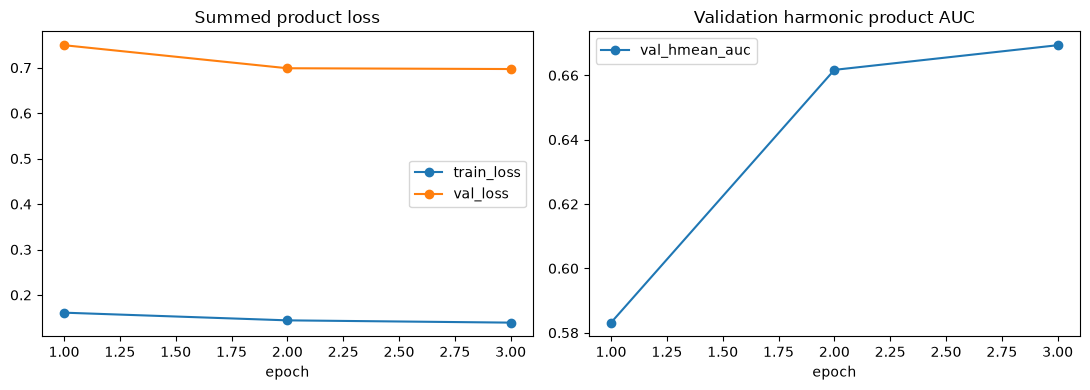

In [22]:
history = train_model(
    model, loaders['train'], loaders["valid"], EPOCHS, "main"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history.plot(x="epoch", y=["train_loss", "val_loss"], marker="o",
             ax=axes[0], title="Summed product loss")
history.plot(x="epoch", y="val_hmean_auc", marker="o", ax=axes[1],
             title="Validation harmonic product AUC")
plt.tight_layout()


## Оценивание качества



In [23]:
features = pd.read_parquet("/kaggle/input/datasets/ahm352/t-intensive-features")

In [24]:
features

,app_id,product,COUNT(transactions),MAX(transactions.amnt),MAX(transactions.days_before),MAX(transactions.hour_diff),MAX(transactions.transaction_number),MEAN(transactions.amnt),MEAN(transactions.days_before),MEAN(transactions.hour_diff),...,STD(transactions.amnt),STD(transactions.days_before),STD(transactions.hour_diff),STD(transactions.transaction_number),SUM(transactions.amnt),SUM(transactions.days_before),SUM(transactions.hour_diff),SUM(transactions.transaction_number),flag,split
0,2,1,229,0.496822,351.0,875.0,229.0,0.306107,171.196507,36.655022,...,0.087890,96.796770,84.381177,66.250786,70.098407,39204.0,8394.0,26335.0,0,valid
1,5,1,90,0.594620,352.0,1943.0,90.0,0.401968,126.333333,91.955556,...,0.096075,105.088299,213.870323,26.124701,36.177086,11370.0,8276.0,4095.0,0,valid
2,6,1,260,0.686218,359.0,455.0,260.0,0.413805,202.861538,32.984615,...,0.106790,90.061048,83.360221,75.199734,107.589377,52744.0,8576.0,33930.0,0,train
3,7,0,91,0.476811,359.0,671.0,91.0,0.305449,157.219780,93.604396,...,0.091558,102.827342,157.927190,26.413380,27.795857,14307.0,8518.0,4186.0,0,test
4,8,2,26,0.539584,79.0,462.0,26.0,0.383976,41.846154,64.384615,...,0.081964,24.556372,125.261032,7.648529,9.983374,1088.0,1674.0,351.0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,1003044,1,260,0.638027,359.0,969.0,260.0,0.311101,214.230769,31.030769,...,0.097321,92.287451,93.914562,75.199734,80.886324,55700.0,8068.0,33930.0,0,train
599996,1003045,1,55,0.588211,344.0,843.0,55.0,0.451358,206.600000,146.400000,...,0.076019,95.496674,238.910536,16.020820,24.824672,11363.0,8052.0,1540.0,0,train
599997,1003047,0,260,0.661614,359.0,370.0,260.0,0.440434,185.080769,32.896154,...,0.099036,98.999967,58.307208,75.199734,114.512897,48121.0,8553.0,33930.0,0,train
599998,1003048,1,219,0.684931,359.0,1245.0,219.0,0.420723,121.292237,39.246575,...,0.103740,106.029408,118.453155,63.364028,92.138302,26563.0,8595.0,24090.0,0,valid


In [25]:
test_mask = features['split'] == 'test'

In [26]:
_, LSTM_FULL_HMEAN_AUC, lstm_y, lstm_p, lstm_ids, lstm_product = evaluate(
    model, loaders["test"], product_values
)
predictions = pd.DataFrame({"app_id": lstm_ids, "target": lstm_y,
                            "product": lstm_product, "probability": lstm_p})

boost_test_ids = set(features.loc[test_mask, "app_id"])

common = predictions[predictions["app_id"].isin(boost_test_ids)]

if len(common) != len(boost_test_ids):
    raise ValueError("Не все CatBoost test app_id найдены в LSTM shards")

boost_common = features.loc[test_mask, ["app_id", "product", "flag"]].copy()

same_test = boost_common.merge(
    common.rename(columns={"probability": "lstm_probability"}),
    on=["app_id", "product"], validate="one_to_one",
)

lstm_table = product_auc_table(
    same_test["target"], same_test["lstm_probability"], same_test["product"],
    product_values,
).rename(columns={"auc": "lstm_auc"}).drop(columns="n")

print(f"LSTM full-test harmonic product AUC: {LSTM_FULL_HMEAN_AUC:.6f}")

LSTM full-test harmonic product AUC: 0.671833


In [27]:
from sklearn.ensemble import HistGradientBoostingClassifier

boost_cols = [c for c in features.columns if c not in ("app_id", "flag", "split")]
train_mask = features["split"] == "train"

boosting = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=1.0,
    random_state=SEED, early_stopping=True, validation_fraction=0.1, n_iter_no_change=30)
boosting.fit(features.loc[train_mask, boost_cols], features.loc[train_mask, "flag"])

boost_prob = boosting.predict_proba(features.loc[test_mask, boost_cols])[:, 1]
boost_table = product_auc_table(
    features.loc[test_mask, "flag"], boost_prob, features.loc[test_mask, "product"],
    product_values,
).rename(columns={"auc": "boosting_auc"}).drop(columns="n")

BOOSTING_AUC = harmonic_mean_auc(boost_table["boosting_auc"])
BOOSTING_AUC_REFERENCE = 0.721359

baseline_vs_boosting = lstm_table.merge(boost_table, on="product")
baseline_vs_boosting["delta"] = (
    baseline_vs_boosting["lstm_auc"] - baseline_vs_boosting["boosting_auc"]).round(4)

print(f"бейзлайн LSTM      {LSTM_FULL_HMEAN_AUC:.6f}")
print(f"бустинг свой       {BOOSTING_AUC:.6f}")
print(f"бустинг из условия {BOOSTING_AUC_REFERENCE:.6f}")
print()
baseline_vs_boosting.round(4)

бейзлайн LSTM      0.671833
бустинг свой       0.711718
бустинг из условия 0.721359



,product,lstm_auc,boosting_auc,delta
0,0,0.7069,0.7541,-0.0472
1,1,0.6731,0.7278,-0.0547
2,2,0.6641,0.7255,-0.0614
3,3,0.6927,0.7251,-0.0324
4,4,0.6278,0.6378,-0.0100


### Вывод

Бейзлайн проигрывает бустингу на всех пяти продуктах, но разрыв неравномерный. На продуктах 1 и 2 это 0.055 и 0.061, а на продукте 4 всего 0.010.

Продукт 4 самый маленький: 35 332 заявки и 1135 дефолтов на весь датасет. Агрегаты по такой выборке шумные, и бустинг проваливается на нём до 0.6378, своего худшего результата. Рекуррентная модель отстаёт здесь меньше всего, то есть в порядке событий есть сигнал, который агрегаты теряют.

Дальше усиливаю то, что умеет только рекуррентная модель: порядок событий и паузы между ними.

# EDA

Смотрю, что лежит в данных и где искать сигнал. Бейзлайн выше использует 3 категориальных признака из 15 и 2 непрерывных из 4, поэтому первым делом надо понять, много ли теряется.

In [28]:
apps = pd.read_parquet(PREBUILT_DIR / "applications.parquet")

split_table = apps.groupby(["product", "split"]).agg(
    n=("app_id", "size"), default_rate=("flag", "mean")
)
split_table["default_rate"] = (split_table["default_rate"] * 100).round(2)
print(split_table.unstack("split"))
print()
print(f"общий дефолт-рейт: {apps['flag'].mean():.4f}")

             n                default_rate            
split     test   train  valid         test train valid
product                                               
0        46934  219031  46936         2.28  2.28  2.28
1        24602  114809  24602         2.50  2.50  2.50
2         7143   33330   7141         7.07  7.06  7.06
3         6021   28098   6021         1.98  1.98  1.99
4         5300   24732   5300         3.21  3.21  3.23

общий дефолт-рейт: 0.0276


In [29]:
product_stats = apps.groupby("product").agg(
    n=("app_id", "size"), positives=("flag", "sum"), rate=("flag", "mean")
)
product_stats["rate_%"] = (product_stats["rate"] * 100).round(2)
product_stats["share_%"] = (product_stats["n"] / len(apps) * 100).round(1)
product_stats[["n", "positives", "rate_%", "share_%"]]

,n,positives,rate_%,share_%
product,,,,
0,312901,7145,2.28,52.2
1,164013,4105,2.50,27.3
2,47614,3363,7.06,7.9
3,40140,796,1.98,6.7
4,35332,1135,3.21,5.9


Дефолт-рейт одинаковый во всех трех сплитах, значит разбиение стратифицированное и валидации можно верить.

Дисбаланс двойной. По классам 2.76% дефолтов. По продуктам: продукт 0 это половина выборки, продукт 4 меньше 6%. Дефолт-рейт различается в 3.5 раза.

Метрика гармоническая, а значит зависит от худшего продукта. Тянуть надо слабые продукты, а не среднее.

In [30]:
def load_shard_sample(split, per_product=8):
    frames = []
    groups = manifest["shards"][split]
    for key in sorted(groups, key=int):
        for entry in groups[key][:per_product]:
            path = PREBUILT_DIR / entry["path"]
            if path.is_file():
                frames.append(path)
    return frames

sample_files = load_shard_sample("train", 8)
print("шардов для EDA:", len(sample_files))

lengths, targets, products = [], [], []
cat_seen = {c: set() for c in STORED_CAT_COLS}
cat_unk = {c: 0 for c in STORED_CAT_COLS}
cont_sample = {c: [] for c in STORED_CONT_COLS}
total_events = 0

rng = np.random.default_rng(SEED)
for path in sample_files:
    with np.load(path, allow_pickle=False) as arch:
        cats, cont = arch["cats"], arch["cont"]
        lengths.append(arch["lengths"].astype(int))
        targets.append(arch["target"])
        products.append(arch["product_idx"].astype(int))
    total_events += len(cats)
    for i, c in enumerate(STORED_CAT_COLS):
        cat_seen[c].update(np.unique(cats[:, i]).tolist())
        cat_unk[c] += int((cats[:, i] == 1).sum())
    idx = rng.choice(len(cont), size=min(20000, len(cont)), replace=False)
    for i, c in enumerate(STORED_CONT_COLS):
        cont_sample[c].append(cont[idx, i])

lengths = np.concatenate(lengths)
targets = np.concatenate(targets)
products = np.concatenate(products)
print("заявок", len(lengths), "транзакций", total_events)

шардов для EDA: 40
заявок 41029 транзакций 3895780


In [31]:
seq = pd.DataFrame({"len": lengths, "target": targets, "product": products})

print(seq["len"].describe().round(1))
print(f"\nобрезано до {MAX_SEQ_LEN}: {100 * (lengths == MAX_SEQ_LEN).mean():.1f}% историй")
print("\nсредняя длина, недефолт против дефолта:")
seq.pivot_table(index="product", columns="target", values="len", aggfunc="mean").round(1)

count    41029.0
mean        95.0
std         43.7
min          6.0
25%         55.0
50%        128.0
75%        128.0
max        128.0
Name: len, dtype: float64

обрезано до 128: 55.3% историй

средняя длина, недефолт против дефолта:


target,0.0,1.0
product,,
0,97.8,92.9
1,98.7,94.0
2,75.8,79.9
3,107.0,119.4
4,96.3,109.0


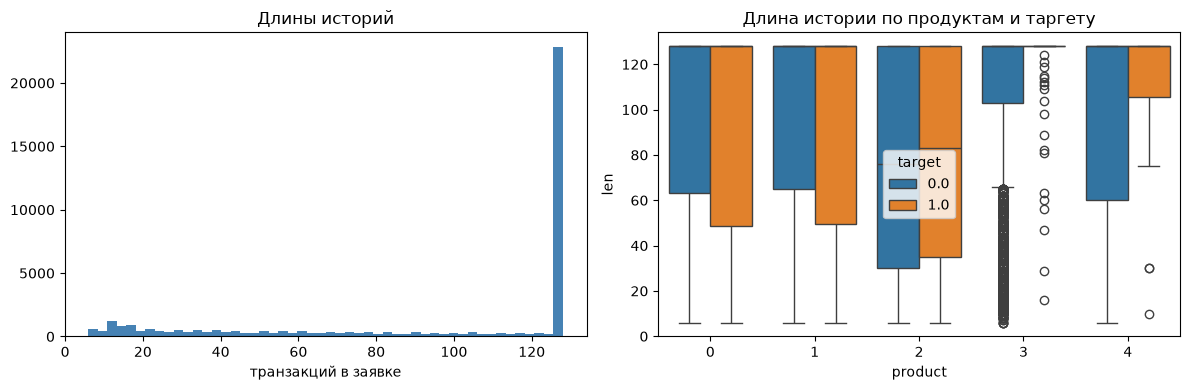

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lengths, bins=50, color="steelblue")
axes[0].set_title("Длины историй")
axes[0].set_xlabel("транзакций в заявке")
sns.boxplot(data=seq, x="product", y="len", hue="target", ax=axes[1])
axes[1].set_title("Длина истории по продуктам и таргету")
plt.tight_layout()

55% историй обрезаны до 128 транзакций. У этих клиентов видно только свежий хвост.

Длина связана с таргетом по-разному у разных продуктов: у 0 и 1 дефолтники менее активны, у 3 и 4 более. Общая репрезентация такой сигнал гасит.

Полная длина косвенно есть в transaction_number, но бейзлайн его не использует.

In [33]:
vocab_table = pd.DataFrame([
    {"col": c,
     "vocab_size": STORED_VOCAB_SIZES[c],
     "seen_in_train": len(cat_seen[c]),
     "unk_share_%": round(100 * cat_unk[c] / total_events, 3),
     "in_baseline": c in CAT_COLS}
    for c in STORED_CAT_COLS
])
vocab_table

,col,vocab_size,seen_in_train,unk_share_%,in_baseline
0,currency,13,11,0.0,False
1,operation_kind,9,7,0.0,True
2,card_type,175,153,0.0,False
3,operation_type,24,22,0.0,False
4,operation_type_group,6,4,0.0,False
5,ecommerce_flag,5,3,0.0,False
6,payment_system,9,7,0.0,False
7,income_flag,5,3,0.0,True
8,mcc,110,108,0.0,True
9,country,26,24,0.0,False


Словари маленькие, максимум 175 значений, unknown 0%. Все 15 категорий можно взять целиком, эмбеддинги займут около 660 строк.

In [34]:
records = []
for path in sample_files:
    with np.load(path, allow_pickle=False) as arch:
        offsets, cats, cont = arch["offsets"], arch["cats"], arch["cont"]
        tgt, prod = arch["target"], arch["product_idx"]
    for i in range(len(tgt)):
        s, e = offsets[i], offsets[i + 1]
        c, k = cont[s:e], cats[s:e]
        row = {"target": float(tgt[i]), "product": int(prod[i]), "n_tx": e - s}
        for j, name in enumerate(STORED_CONT_COLS):
            v = c[:, j]
            row[name + "_mean"] = v.mean()
            row[name + "_std"] = v.std()
            row[name + "_min"] = v.min()
            row[name + "_max"] = v.max()
        for j, name in enumerate(STORED_CAT_COLS):
            row[name + "_nuniq"] = len(np.unique(k[:, j]))
        for name in ["income_flag", "ecommerce_flag", "operation_kind", "operation_type_group"]:
            j = STORED_CAT_COLS.index(name)
            vals, cnt = np.unique(k[:, j], return_counts=True)
            for v, n in zip(vals, cnt):
                row[f"{name}={v}"] = n / len(k)
        records.append(row)

agg = pd.DataFrame(records).fillna(0.0)
print("матрица агрегатов:", agg.shape)

матрица агрегатов: (41029, 51)


In [35]:
feature_cols = [c for c in agg.columns if c not in ("target", "product")]

single = []
for col in feature_cols:
    aucs = []
    for _, g in agg.groupby("product"):
        if g["target"].nunique() < 2:
            aucs = []
            break
        a = roc_auc_score(g["target"], g[col])
        aucs.append(max(a, 1 - a))
    if aucs:
        single.append({"feature": col, "hmean_auc": harmonic_mean_auc(aucs),
                       "min_auc": min(aucs), "max_auc": max(aucs)})

single = pd.DataFrame(single).sort_values("hmean_auc", ascending=False)
single.head(20).round(4)

,feature,hmean_auc,min_auc,max_auc
1,amnt_mean,0.5849,0.5443,0.6243
3,amnt_min,0.5835,0.5538,0.6059
33,income_flag=3,0.5664,0.5478,0.6151
32,income_flag=2,0.5663,0.5479,0.6151
43,operation_type_group=3,0.5658,0.5427,0.6140
42,operation_type_group=2,0.5604,0.5304,0.6205
39,operation_kind=5,0.5585,0.5500,0.5653
9,hour_diff_mean,0.5578,0.5205,0.5985
18,operation_kind_nuniq,0.5491,0.5130,0.5989
25,mcc_nuniq,0.5471,0.5105,0.6009


In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

X = agg.drop(columns=["target"])
y = agg["target"].values
strat = agg["product"].astype(str) + "_" + agg["target"].astype(int).astype(str)
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=strat)

gbm = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_depth=6, random_state=SEED)
gbm.fit(X_tr, y_tr)
gbm_prob = gbm.predict_proba(X_va)[:, 1]

gbm_aucs = {int(k): roc_auc_score(g["target"], g["prob"])
            for k, g in pd.DataFrame({"target": y_va, "prob": gbm_prob,
                                      "product": X_va["product"].values}).groupby("product")}
for k, v in sorted(gbm_aucs.items()):
    print(f"продукт {k}: {v:.4f}")
print(f"\nH-AUC {harmonic_mean_auc(list(gbm_aucs.values())):.4f}")
print(f"плоский AUC {roc_auc_score(y_va, gbm_prob):.4f}")

продукт 0: 0.6409
продукт 1: 0.5899
продукт 2: 0.6652
продукт 3: 0.5208
продукт 4: 0.7414

H-AUC 0.6229
плоский AUC 0.6904


In [37]:
perm = permutation_importance(gbm, X_va, y_va, n_repeats=3, random_state=SEED,
                              scoring="roc_auc", n_jobs=2)
imp = pd.DataFrame({"feature": X.columns, "importance": perm.importances_mean})

def source_column(name):
    for src in sorted(STORED_CAT_COLS + STORED_CONT_COLS, key=len, reverse=True):
        if name.startswith(src):
            return src
    return "other"

imp["source"] = imp["feature"].map(source_column)
by_source = imp.groupby("source")["importance"].sum().sort_values(ascending=False)
by_source = by_source.to_frame("importance")
by_source["in_baseline"] = [i in CAT_COLS + CONT_COLS for i in by_source.index]
by_source.round(5)

,importance,in_baseline
source,,
other,0.03192,False
hour_diff,0.02469,False
amnt,0.02059,True
hour,0.01809,False
mcc,0.01607,True
operation_type,0.00725,False
operation_kind,0.00377,True
country,0.00352,False
weekofyear,0.00164,False


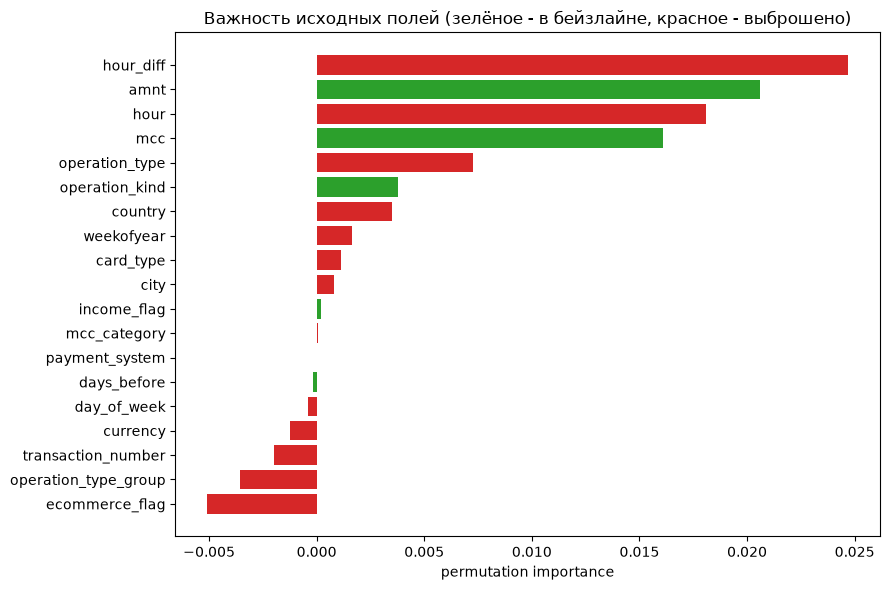

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = by_source[by_source.index != "other"].sort_values("importance")
colors = ["tab:green" if b else "tab:red" for b in plot_data["in_baseline"]]
ax.barh(plot_data.index, plot_data["importance"], color=colors)
ax.set_title("Важность исходных полей (зелёное - в бейзлайне, красное - выброшено)")
ax.set_xlabel("permutation importance")
plt.tight_layout()

## Выводы EDA и гипотезы

### Где стоим

бейзлайн LSTM: 0.671833

бустинг свой: 0.711718

бустинг из условия: 0.721359

Нужно +0.050 AUC.

### Метрика зависит от худшего продукта

У бейзлайна продукты дают 0.7069, 0.6731, 0.6641, 0.6927, 0.6278. Среднее арифметическое 0.6729, гармоническое 0.6718.

Если поднять продукт 4 с 0.6278 до 0.70 и не трогать остальные, H-AUC станет 0.6870. Плюс 0.015 из одного продукта.

Значит целиться надо в слабые продукты.

### На продукте 4 разрыв с бустингом минимальный

```
product   lstm     boosting   delta
   0     0.7069    0.7541    -0.0472
   1     0.6731    0.7278    -0.0547
   2     0.6641    0.7255    -0.0614
   3     0.6927    0.7251    -0.0324
   4     0.6278    0.6378    -0.0100
```

Продукт 4: 35 332 заявки, 1135 дефолтов. Бустинг на нём падает до 0.6378, это его худший продукт. Отставание LSTM здесь 0.010 против 0.05-0.06 на остальных. Там, где агрегаты шумят, последовательность даёт больше.

### Половина признаков не используется

Permutation importance по бустингу на агрегатах:

```
hour_diff            0.02469   не используется
amnt                 0.02059   в бейзлайне
hour                 0.01809   не используется
mcc                  0.01607   в бейзлайне
operation_type       0.00725   не используется
operation_kind       0.00377   в бейзлайне
country              0.00352   не используется
income_flag          0.00018   в бейзлайне
days_before         -0.00015   в бейзлайне
```

Пять полей бейзлайна дают 0.0405. Выброшенные поля с положительным вкладом дают 0.0573.

hour_diff весит больше суммы платежа. Это пауза между транзакциями, прокси регулярности трат. В модели его нет.

days_before даёт около нуля с минусом. Он дублирует позицию транзакции, а порядок LSTM знает и так.

### Бейзлайн не сошёлся


Epoch 1/3: val_hmean_auc = 0.583148

Epoch 2/3: val_hmean_auc = 0.661681

Epoch 3/3: val_hmean_auc = 0.669345


Метрика растёт на последней эпохе. Три эпохи выбраны произвольно.

### Гипотезы

Данные:

- H1: все признаки дадут прирост, потому что топ-1 и топ-3 по важности не используются
- H2: days_before бесполезен
- H3: производные признаки внутри истории добавят сигнала

Архитектура:

- H4: последний hidden state теряет начало истории
- H5: на длине 128 self-attention видит всю историю сразу
- H6: пять независимых голов не дают редким продуктам учиться, у продукта 4 всего 1135 позитивов

Loss и обучение:

- H7: при 2.76% позитивов градиент идёт в основном от негативов
- H8: слабым продуктам нужен больший вес в лоссе
- H9: метрика ранговая, BCE калибровочный
- H10: три эпохи мало

# Пайплайн для экспериментов

Чтобы эксперименты были сравнимы, делаю один конфиг и одну функцию запуска. Дальше каждый эксперимент это описание конфига.

Отдельно меняю чтение данных. Бейзлайновый NpzSequenceDataset распаковывает шарды каждую эпоху и перемешивает только файлы и записи внутри файла. Шард содержит один продукт, поэтому батчи получаются почти однородными по продукту.

Весь датасет по выбранным колонкам занимает около 2 ГБ, поэтому читаю его один раз в память и работаю обычным map-style датасетом с полным shuffle.

In [39]:
from dataclasses import dataclass, field, asdict
from torch.utils.data import Dataset

class SequenceStore:
    def __init__(self, files, cat_indices, cont_indices, verbose=True):
        cats_parts, cont_parts, len_parts = [], [], []
        tgt_parts, prod_parts, id_parts = [], [], []
        for n, path in enumerate(files, 1):
            with np.load(path, allow_pickle=False) as arch:
                cats_parts.append(arch["cats"][:, cat_indices])
                cont_parts.append(arch["cont"][:, cont_indices])
                len_parts.append(arch["lengths"].astype(np.int64))
                tgt_parts.append(arch["target"].astype(np.float32))
                prod_parts.append(arch["product_idx"].astype(np.int64))
                id_parts.append(arch["app_id"].astype(np.int64))
            if verbose and n % 100 == 0:
                print(f"загружено шардов: {n}/{len(files)}")
        self.cats = np.concatenate(cats_parts)
        self.cont = np.concatenate(cont_parts)
        self.lengths = np.concatenate(len_parts)
        self.target = np.concatenate(tgt_parts)
        self.product = np.concatenate(prod_parts)
        self.app_id = np.concatenate(id_parts)
        self.offsets = np.zeros(len(self.lengths) + 1, dtype=np.int64)
        np.cumsum(self.lengths, out=self.offsets[1:])

    def __len__(self):
        return len(self.lengths)

    @property
    def n_events(self):
        return len(self.cats)

    def memory_mb(self):
        return (self.cats.nbytes + self.cont.nbytes) / 1e6


class SequenceDataset(Dataset):
    def __init__(self, store, feature_builder=None):
        self.store = store
        self.feature_builder = feature_builder

    def __len__(self):
        return len(self.store)

    def __getitem__(self, index):
        s = self.store
        start, stop = s.offsets[index], s.offsets[index + 1]
        cats = s.cats[start:stop]
        cont = s.cont[start:stop]
        if self.feature_builder is not None:
            cont = self.feature_builder(cont, cats)
        return (cats, cont, int(s.lengths[index]), float(s.target[index]),
                int(s.product[index]), int(s.app_id[index]))


def fast_collate(items):
    n = len(items)
    lengths = np.fromiter((it[2] for it in items), dtype=np.int64, count=n)
    max_len = int(lengths.max())
    n_cat = items[0][0].shape[1]
    n_cont = items[0][1].shape[1]
    cats = np.zeros((n, max_len, n_cat), dtype=np.int64)
    cont = np.zeros((n, max_len, n_cont), dtype=np.float32)
    for i, (c, o, length, *_) in enumerate(items):
        cats[i, :length] = c
        cont[i, :length] = o
    return {
        "cats": torch.from_numpy(cats),
        "cont": torch.from_numpy(cont),
        "length": torch.from_numpy(lengths),
        "target": torch.tensor([it[3] for it in items], dtype=torch.float32),
        "product": torch.tensor([it[4] for it in items], dtype=torch.long),
        "app_id": torch.tensor([it[5] for it in items], dtype=torch.long),
    }

In [40]:
DERIVED_AVAILABLE = ("delta_days", "position", "position_frac", "is_first",
                     "amnt_cummean", "amnt_dev", "log_gap")

def build_feature_fn(derived, cont_cols):
    derived = tuple(derived)
    unknown = set(derived) - set(DERIVED_AVAILABLE)
    if unknown:
        raise ValueError("Неизвестные признаки: %s" % sorted(unknown))
    if not derived:
        return None
    i_days = cont_cols.index("days_before") if "days_before" in cont_cols else None
    i_amnt = cont_cols.index("amnt") if "amnt" in cont_cols else None
    i_gap = cont_cols.index("hour_diff") if "hour_diff" in cont_cols else None

    def fn(cont, cats):
        n = len(cont)
        extras = []
        for name in derived:
            if name == "delta_days" and i_days is not None:
                extras.append(np.diff(cont[:, i_days], prepend=cont[0, i_days]).astype(np.float32))
            elif name == "position":
                extras.append(np.arange(n, dtype=np.float32) / MAX_SEQ_LEN)
            elif name == "position_frac":
                extras.append(np.arange(n, dtype=np.float32) / max(n - 1, 1))
            elif name == "is_first":
                v = np.zeros(n, dtype=np.float32)
                v[0] = 1.0
                extras.append(v)
            elif name == "amnt_cummean" and i_amnt is not None:
                extras.append((np.cumsum(cont[:, i_amnt]) / np.arange(1, n + 1)).astype(np.float32))
            elif name == "amnt_dev" and i_amnt is not None:
                a = cont[:, i_amnt]
                extras.append((a - a.mean()).astype(np.float32))
            elif name == "log_gap" and i_gap is not None:
                extras.append(np.log1p(np.abs(cont[:, i_gap])).astype(np.float32))
            else:
                extras.append(np.zeros(n, dtype=np.float32))
        return np.column_stack([cont] + extras).astype(np.float32)

    return fn

In [41]:
import math

def length_mask(lengths, max_len, device):
    return torch.arange(max_len, device=device)[None, :] < lengths.to(device)[:, None]


class AttentionPool(nn.Module):
    def __init__(self, width, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(width, hidden), nn.Tanh(), nn.Linear(hidden, 1))

    def forward(self, sequence, mask):
        logits = self.score(sequence).squeeze(-1).masked_fill(~mask, float("-inf"))
        weights = torch.softmax(logits, dim=1)
        return torch.bmm(weights[:, None, :], sequence).squeeze(1), weights


class PositionalEncoding(nn.Module):
    def __init__(self, width, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, width)
        pos = torch.arange(max_len)[:, None].float()
        div = torch.exp(torch.arange(0, width, 2).float() * (-math.log(10000.0) / width))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe[None])

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class SequenceScorer(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, n_cont, n_products, emb_dim=12,
                 emb_dims=None, hidden=64, num_layers=1, bidirectional=False,
                 encoder="lstm", pooling="last", head="per_product", dropout=0.2,
                 n_heads=4, ff_mult=4, use_length_feature=False, regression_head=False):
        super().__init__()
        self.cat_cols = list(cat_cols)
        self.encoder_kind = encoder
        self.pooling_kind = pooling
        self.head_kind = head
        self.use_length_feature = use_length_feature

        dims = emb_dims or {c: emb_dim for c in self.cat_cols}
        self.embeddings = nn.ModuleList(
            [nn.Embedding(vocab_sizes[c], dims[c], padding_idx=0) for c in self.cat_cols])
        width = sum(dims[c] for c in self.cat_cols) + n_cont
        self.input_norm = nn.LayerNorm(width)

        if encoder in ("lstm", "gru"):
            cls = nn.LSTM if encoder == "lstm" else nn.GRU
            self.rnn = cls(width, hidden, num_layers=num_layers, batch_first=True,
                           bidirectional=bidirectional,
                           dropout=dropout if num_layers > 1 else 0.0)
            out_width = hidden * (2 if bidirectional else 1)
        else:
            self.project = nn.Linear(width, hidden)
            self.pos = PositionalEncoding(hidden)
            layer = nn.TransformerEncoderLayer(
                d_model=hidden, nhead=n_heads, dim_feedforward=hidden * ff_mult,
                dropout=dropout, batch_first=True, norm_first=True, activation="gelu")
            self.transformer = nn.TransformerEncoder(layer, num_layers)
            out_width = hidden

        if pooling == "attention":
            self.attention = AttentionPool(out_width)
        pooled_width = out_width * (3 if pooling == "concat" else 1)
        if use_length_feature:
            pooled_width += 2

        self.dropout = nn.Dropout(dropout)
        if head == "per_product":
            self.heads = nn.ModuleList([nn.Linear(pooled_width, 1) for _ in range(n_products)])
        elif head == "shared":
            self.shared_head = nn.Linear(pooled_width, 1)
        else:
            self.product_emb = nn.Embedding(n_products, 16)
            self.shared_head = nn.Sequential(
                nn.Linear(pooled_width + 16, pooled_width), nn.GELU(),
                nn.Dropout(dropout), nn.Linear(pooled_width, 1))

        self.regression_head = None
        if regression_head:
            self.regression_head = nn.Sequential(
                nn.Linear(pooled_width, pooled_width // 2), nn.GELU(),
                nn.Linear(pooled_width // 2, 1))

    def encode(self, cats, cont, lengths):
        embedded = [layer(cats[:, :, i]) for i, layer in enumerate(self.embeddings)]
        x = self.input_norm(torch.cat([*embedded, cont], dim=-1))
        mask = length_mask(lengths, x.size(1), x.device)

        if self.encoder_kind in ("lstm", "gru"):
            packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
            output, state = self.rnn(packed)
            if self.pooling_kind == "last":
                hidden = state[0] if self.encoder_kind == "lstm" else state
                if self.rnn.bidirectional:
                    return torch.cat([hidden[-2], hidden[-1]], dim=-1), None
                return hidden[-1], None
            sequence, _ = nn.utils.rnn.pad_packed_sequence(
                output, batch_first=True, total_length=x.size(1))
        else:
            sequence = self.transformer(self.pos(self.project(x)), src_key_padding_mask=~mask)
        return self.pool(sequence, mask)

    def pool(self, sequence, mask):
        m = mask.unsqueeze(-1)
        arange = torch.arange(len(sequence), device=sequence.device)
        if self.pooling_kind == "mean":
            return (sequence * m).sum(1) / m.sum(1).clamp(min=1), None
        if self.pooling_kind == "max":
            return sequence.masked_fill(~m, float("-inf")).max(1).values, None
        if self.pooling_kind == "attention":
            return self.attention(sequence, mask)
        if self.pooling_kind == "concat":
            mean = (sequence * m).sum(1) / m.sum(1).clamp(min=1)
            mx = sequence.masked_fill(~m, float("-inf")).max(1).values
            last = sequence[arange, (mask.sum(1) - 1).clamp(min=0)]
            return torch.cat([last, mean, mx], dim=-1), None
        return sequence[arange, (mask.sum(1) - 1).clamp(min=0)], None

    def forward(self, cats, cont, lengths, product, return_attention=False):
        pooled, attention = self.encode(cats, cont, lengths)
        if self.use_length_feature:
            ln = lengths.to(pooled.device).float()
            pooled = torch.cat([pooled, torch.stack([ln / MAX_SEQ_LEN, (ln == MAX_SEQ_LEN).float()], -1)], -1)

        z = self.dropout(pooled)
        if self.head_kind == "per_product":
            logits = torch.cat([h(z) for h in self.heads], dim=1)
            out = logits.gather(1, product[:, None]).squeeze(1)
        elif self.head_kind == "shared":
            out = self.shared_head(z).squeeze(1)
        else:
            out = self.shared_head(torch.cat([z, self.product_emb(product)], dim=-1)).squeeze(1)

        result = {"logit": out}
        if self.regression_head is not None:
            result["regression"] = self.regression_head(z).squeeze(1)
        if return_attention:
            result["attention"] = attention
        return result

In [42]:
def weighted_product_bce(logits, target, product, pos_weight=None, product_weights=None, **kw):
    pw = None if pos_weight is None else torch.as_tensor(float(pos_weight), device=logits.device)
    element = nn.functional.binary_cross_entropy_with_logits(
        logits, target, reduction="none", pos_weight=pw)
    losses, weights = [], []
    for p in torch.unique(product, sorted=True):
        losses.append(element[product == p].mean())
        weights.append(1.0 if product_weights is None else float(product_weights[int(p)]))
    w = torch.tensor(weights, device=logits.device)
    return (torch.stack(losses) * w).sum() / w.sum() * len(w)


def focal_product_loss(logits, target, product, gamma=2.0, alpha=0.25, product_weights=None, **kw):
    prob = torch.sigmoid(logits)
    ce = nn.functional.binary_cross_entropy_with_logits(logits, target, reduction="none")
    p_t = prob * target + (1 - prob) * (1 - target)
    a_t = alpha * target + (1 - alpha) * (1 - target)
    element = a_t * (1 - p_t).pow(gamma) * ce
    losses, weights = [], []
    for p in torch.unique(product, sorted=True):
        losses.append(element[product == p].mean())
        weights.append(1.0 if product_weights is None else float(product_weights[int(p)]))
    w = torch.tensor(weights, device=logits.device)
    return (torch.stack(losses) * w).sum() / w.sum() * len(w)


def auc_surrogate_loss(logits, target, product, margin=1.0, bce_mix=0.5, product_weights=None, **kw):
    parts, weights = [], []
    for p in torch.unique(product, sorted=True):
        m = product == p
        pos, neg = logits[m][target[m] > 0.5], logits[m][target[m] < 0.5]
        if len(pos) == 0 or len(neg) == 0:
            continue
        diff = margin - (pos[:, None] - neg[None, :])
        parts.append(diff.clamp(min=0).pow(2).mean())
        weights.append(1.0 if product_weights is None else float(product_weights[int(p)]))
    if not parts:
        return summed_product_bce(logits, target, product)
    w = torch.tensor(weights, device=logits.device)
    rank = (torch.stack(parts) * w).sum() / w.sum() * len(w)
    if bce_mix <= 0:
        return rank
    return (1 - bce_mix) * rank + bce_mix * summed_product_bce(logits, target, product)


LOSS_REGISTRY = {
    "summed_bce": lambda l, t, p, **kw: summed_product_bce(l, t, p),
    "weighted_bce": weighted_product_bce,
    "focal": focal_product_loss,
    "auc_surrogate": auc_surrogate_loss,
}

def build_loss(name, **kwargs):
    fn = LOSS_REGISTRY[name]
    return lambda logits, target, product: fn(logits, target, product, **kwargs)

In [43]:
@dataclass
class ExperimentConfig:
    name: str
    notes: str = ""
    cat_cols: tuple = tuple(CAT_COLS)
    cont_cols: tuple = tuple(CONT_COLS)
    derived_features: tuple = ()
    limit_shards: int = None
    encoder: str = "lstm"
    hidden: int = 64
    emb_dim: int = 12
    emb_rule: str = None
    num_layers: int = 1
    bidirectional: bool = False
    pooling: str = "last"
    head: str = "per_product"
    dropout: float = 0.2
    n_heads: int = 4
    use_length_feature: bool = False
    regression_head: bool = False
    loss: str = "summed_bce"
    loss_kwargs: dict = field(default_factory=dict)
    epochs: int = EPOCHS
    batch_size: int = BATCH_SIZE
    lr: float = 2e-3
    weight_decay: float = 1e-2
    scheduler: str = "plateau"
    grad_clip: float = 1.0
    amp: bool = True
    seed: int = SEED
    num_workers: int = 2
    early_stop_patience: int = None


REGISTRY = {}
STORE_CACHE = {}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def limited_shard_paths(split, limit_per_product=None):
    groups = manifest["shards"][split]
    files = []
    for key in sorted(groups, key=int):
        entries = groups[key]
        if limit_per_product is not None:
            entries = entries[:limit_per_product]
        files += [PREBUILT_DIR / e["path"] for e in entries]
    return [f for f in files if f.is_file()]


def get_store(split, cat_cols, cont_cols, limit_shards, verbose=True):
    key = (split, tuple(cat_cols), tuple(cont_cols), limit_shards)
    if key in STORE_CACHE:
        return STORE_CACHE[key]
    ci = [STORED_CAT_COLS.index(c) for c in cat_cols]
    oi = [STORED_CONT_COLS.index(c) for c in cont_cols]
    files = limited_shard_paths(split, limit_shards)
    store = SequenceStore(files, ci, oi, verbose=False)
    if verbose:
        print(f"{split}: {len(files)} шардов, {len(store)} заявок, "
              f"{store.n_events} транзакций, {store.memory_mb():.0f} МБ")
    STORE_CACHE[key] = store
    return store

In [44]:
def build_model(cfg, n_cont_total):
    if cfg.emb_rule == "sqrt":
        dims = {c: int(min(48, max(4, round(STORED_VOCAB_SIZES[c] ** 0.5) * 2))) for c in cfg.cat_cols}
    else:
        dims = {c: cfg.emb_dim for c in cfg.cat_cols}
    vocab = {c: STORED_VOCAB_SIZES[c] for c in cfg.cat_cols}
    return SequenceScorer(
        cfg.cat_cols, vocab, n_cont_total, len(product_values), emb_dims=dims,
        hidden=cfg.hidden, num_layers=cfg.num_layers, bidirectional=cfg.bidirectional,
        encoder=cfg.encoder, pooling=cfg.pooling, head=cfg.head, dropout=cfg.dropout,
        n_heads=cfg.n_heads, use_length_feature=cfg.use_length_feature,
        regression_head=cfg.regression_head)


@torch.no_grad()
def evaluate_model(model, loader, loss_fn, expected_products=None, amp=False):
    model.eval()
    logits_all, targets, products, ids = [], [], [], []
    for batch in loader:
        with torch.autocast(device.type, enabled=amp and device.type == "cuda"):
            out = model(batch["cats"].to(device), batch["cont"].to(device),
                        batch["length"], batch["product"].to(device))
        logits_all.append(out["logit"].float().cpu())
        targets.append(batch["target"])
        products.append(batch["product"])
        ids.append(batch["app_id"])
    logits = torch.cat(logits_all)
    target = torch.cat(targets)
    product_idx = torch.cat(products)
    loss = float(loss_fn(logits, target, product_idx))
    prob = torch.sigmoid(logits).numpy()
    product = np.asarray(product_values)[product_idx.numpy()]
    metric, table = product_harmonic_auc(target.numpy(), prob, product, expected_products)
    return {"loss": loss, "hmean_auc": metric, "table": table, "target": target.numpy(),
            "prob": prob, "app_id": torch.cat(ids).numpy(), "product": product}

In [45]:
def run_experiment(cfg, splits=("train", "valid", "test"), writer=None, verbose=True):
    set_seed(cfg.seed)
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    n_cont_total = len(cfg.cont_cols) + len(cfg.derived_features)
    started_total = time.perf_counter()

    stores = {s: get_store(s, cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose) for s in splits}
    loaders_exp = {
        s: DataLoader(SequenceDataset(st, feature_fn), batch_size=cfg.batch_size,
                      collate_fn=fast_collate, shuffle=(s == "train"),
                      num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"),
                      persistent_workers=cfg.num_workers > 0, drop_last=(s == "train"))
        for s, st in stores.items()}

    model = build_model(cfg, n_cont_total).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    loss_fn = build_loss(cfg.loss, **cfg.loss_kwargs)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    steps = max(1, len(loaders_exp["train"]))
    if cfg.scheduler == "onecycle":
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=cfg.lr, epochs=cfg.epochs, steps_per_epoch=steps, pct_start=0.05)
        sched_mode = "batch"
    elif cfg.scheduler == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs * steps)
        sched_mode = "batch"
    elif cfg.scheduler == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=1, factor=0.5)
        sched_mode = "epoch"
    else:
        scheduler, sched_mode = None, "none"

    scaler = torch.amp.GradScaler(device.type, enabled=cfg.amp and device.type == "cuda")
    checkpoint_path = Path("/kaggle/working") / f"{cfg.name}_best.pt"
    best, bad_epochs, history = -np.inf, 0, []

    if verbose:
        print(f"{cfg.name} | {n_params} параметров, {steps} батчей")

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        started, losses = time.perf_counter(), []
        for batch in loaders_exp["train"]:
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device.type, enabled=cfg.amp and device.type == "cuda"):
                out = model(batch["cats"].to(device), batch["cont"].to(device),
                            batch["length"], batch["product"].to(device))
                loss = loss_fn(out["logit"].float(), batch["target"].to(device),
                               batch["product"].to(device))
            scaler.scale(loss).backward()
            if cfg.grad_clip:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scale_before = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            if sched_mode == "batch" and scaler.get_scale() >= scale_before:
                scheduler.step()
            losses.append(float(loss.detach()))

        val = evaluate_model(model, loaders_exp["valid"], loss_fn, amp=cfg.amp)
        if sched_mode == "epoch":
            scheduler.step(val["hmean_auc"])

        row = {"epoch": epoch, "train_loss": float(np.mean(losses)), "val_loss": val["loss"],
               "val_hmean_auc": val["hmean_auc"], "lr": optimizer.param_groups[0]["lr"],
               "seconds": time.perf_counter() - started}
        for _, r in val["table"].iterrows():
            row[f"val_auc_p{int(r['product'])}"] = r["auc"]
        history.append(row)

        if writer is not None:
            writer.add_scalar(f"{cfg.name}/train_loss", row["train_loss"], epoch)
            writer.add_scalar(f"{cfg.name}/val_loss", row["val_loss"], epoch)
            writer.add_scalar(f"{cfg.name}/val_hmean_auc", val["hmean_auc"], epoch)

        if verbose:
            print(f"epoch {epoch}: train {row['train_loss']:.4f}, "
                  f"val {row['val_loss']:.4f}, H-AUC {val['hmean_auc']:.4f}")

        if val["hmean_auc"] > best:
            best, bad_epochs = val["hmean_auc"], 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            bad_epochs += 1
            if cfg.early_stop_patience and bad_epochs >= cfg.early_stop_patience:
                if verbose:
                    print(f"ранняя остановка, лучшая эпоха дала {best:.4f}")
                break

    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

    if "test" in loaders_exp:
        test = evaluate_model(model, loaders_exp["test"], loss_fn,
                              expected_products=product_values, amp=cfg.amp)
    else:
        test = {"hmean_auc": float("nan"), "table": pd.DataFrame(), "target": np.array([]),
                "prob": np.array([]), "app_id": np.array([]), "product": np.array([])}

    result = {"config": cfg, "name": cfg.name, "notes": cfg.notes, "n_params": n_params,
              "history": pd.DataFrame(history), "best_val_hmean_auc": best,
              "test_hmean_auc": test["hmean_auc"], "test_table": test["table"],
              "test_predictions": pd.DataFrame({"app_id": test["app_id"], "target": test["target"],
                                                "product": test["product"], "probability": test["prob"]}),
              "model": model, "checkpoint": str(checkpoint_path),
              "total_seconds": time.perf_counter() - started_total}
    REGISTRY[cfg.name] = result

    if verbose and len(test["table"]):
        minutes = result["total_seconds"] / 60
        print(f"test H-AUC {test['hmean_auc']:.6f}, обучалось {minutes:.1f} мин")
    return result


def summary(baseline_name=None):
    rows = [{"experiment": n, "params": r["n_params"], "val_hmean_auc": r["best_val_hmean_auc"],
             "test_hmean_auc": r["test_hmean_auc"], "minutes": round(r["total_seconds"] / 60, 1),
             "notes": r["notes"]} for n, r in REGISTRY.items()]
    df = pd.DataFrame(rows).sort_values("test_hmean_auc", ascending=False)
    if baseline_name and baseline_name in REGISTRY:
        base = REGISTRY[baseline_name]["test_hmean_auc"]
        df["delta"] = (df["test_hmean_auc"] - base).round(6)
        df["points"] = (df["delta"] / 0.0075).clip(lower=0).round(2)
    return df.reset_index(drop=True)


def plot_history(names, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name in names:
        h = REGISTRY[name]["history"]
        axes[0].plot(h["epoch"], h["train_loss"], marker="o", label=f"{name} train")
        axes[0].plot(h["epoch"], h["val_loss"], marker="s", linestyle="--", label=f"{name} val")
        axes[1].plot(h["epoch"], h["val_hmean_auc"], marker="o", label=name)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend(fontsize=8)
    axes[1].set_title("Validation harmonic AUC")
    axes[1].set_xlabel("epoch")
    axes[1].legend(fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()

In [46]:
writer = SummaryWriter(log_dir="/kaggle/working/tb")

ALL_CAT = tuple(STORED_CAT_COLS)
ALL_CONT = tuple(STORED_CONT_COLS)
NO_DAYS = tuple(c for c in ALL_CONT if c != "days_before")

LIMIT_SHARDS = None
BASE_EPOCHS = 6
BASE_BATCH = 512
WORKERS = 4

LIMIT_SHARDS берёт первые N шардов каждого продукта. При значении 3 и уменьшенном EPOCHS в первой ячейке весь ноутбук проходит Run All за несколько минут.

In [47]:
BASELINE_AUC = LSTM_FULL_HMEAN_AUC
baseline_params = sum(p.numel() for p in model.parameters())

REGISTRY["B0_baseline"] = {
    "config": None,
    "name": "B0_baseline",
    "notes": "бейзлайн из шаблона: 3 категории и 2 непрерывных, LSTM-64, последний state, 5 голов",
    "n_params": baseline_params,
    "history": history,
    "best_val_hmean_auc": float(history["val_hmean_auc"].max()),
    "test_hmean_auc": BASELINE_AUC,
    "test_table": lstm_table.rename(columns={"lstm_auc": "auc"}),
    "test_predictions": predictions,
    "model": model,
    "checkpoint": "/kaggle/working/main_best.pt",
    "total_seconds": float(history["seconds"].sum()),
}

print(f"бейзлайн на тесте {BASELINE_AUC:.6f}, параметров {baseline_params}")
REGISTRY["B0_baseline"]["test_table"].round(4)

бейзлайн на тесте 0.671833, параметров 28437


,product,auc
0,0,0.7069
1,1,0.6731
2,2,0.6641
3,3,0.6927
4,4,0.6278


Бейзлайн обучен выше, поэтому не переобучаю его, а кладу результаты в реестр. Дальше все эксперименты сравниваются с ним, а summary считает прирост и баллы.

Каждый эксперимент меняет одну вещь относительно текущей базы.

# Эксперименты с данными

## D1. Все признаки транзакции

Гипотеза H1. Бейзлайн читает 15 категориальных и 4 непрерывных признака, а подаёт в модель 5. По permutation importance hour_diff весит больше amnt, а hour больше mcc. Жду здесь основной прирост.

Размер эмбеддинга беру по размеру словаря. Иначе currency с 13 значениями и card_type со 175 получат одинаковые 12 измерений.

Остальное как в бейзлайне: LSTM-64, последний state, три эпохи, тот же lr и расписание. Меняю одну вещь.

In [48]:
d1 = run_experiment(ExperimentConfig(
    name="D1_all_features",
    notes="H1: все 15 категорий и 4 непрерывных вместо 3 и 2",
    cat_cols=ALL_CAT, cont_cols=ALL_CONT, emb_rule="sqrt",
    encoder="lstm", hidden=64, pooling="last", head="per_product",
    loss="summed_bce", scheduler="plateau", lr=2e-3,
    epochs=3, batch_size=BASE_BATCH, num_workers=WORKERS,
    limit_shards=LIMIT_SHARDS,
), writer=writer)

train: 352 шардов, 420000 заявок, 41544078 транзакций, 1911 МБ
valid: 240 шардов, 90000 заявок, 8891178 транзакций, 409 МБ
test: 240 шардов, 90000 заявок, 8901409 транзакций, 409 МБ
D1_all_features | 73751 параметров, 820 батчей
epoch 1: train 0.7531, val 0.7040, H-AUC 0.6440
epoch 2: train 0.7027, val 0.6917, H-AUC 0.6797
epoch 3: train 0.6910, val 0.6846, H-AUC 0.6866
test H-AUC 0.682398, обучалось 0.6 мин


,baseline,all_features,delta
product,,,
0,0.7069,0.7183,0.0114
1,0.6731,0.7085,0.0354
2,0.6641,0.6969,0.0328
3,0.6927,0.6629,-0.0298
4,0.6278,0.6329,0.0050


,experiment,params,val_hmean_auc,test_hmean_auc,minutes,notes,delta,points
0,D1_all_features,73751,0.686615,0.682398,0.6,H1: все 15 категорий и 4 непрерывных вместо 3 и 2,0.010565,1.41
1,B0_baseline,28437,0.669345,0.671833,1.2,бейзлайн из шаблона: 3 категории и 2 непрерывн...,0.000000,0.00


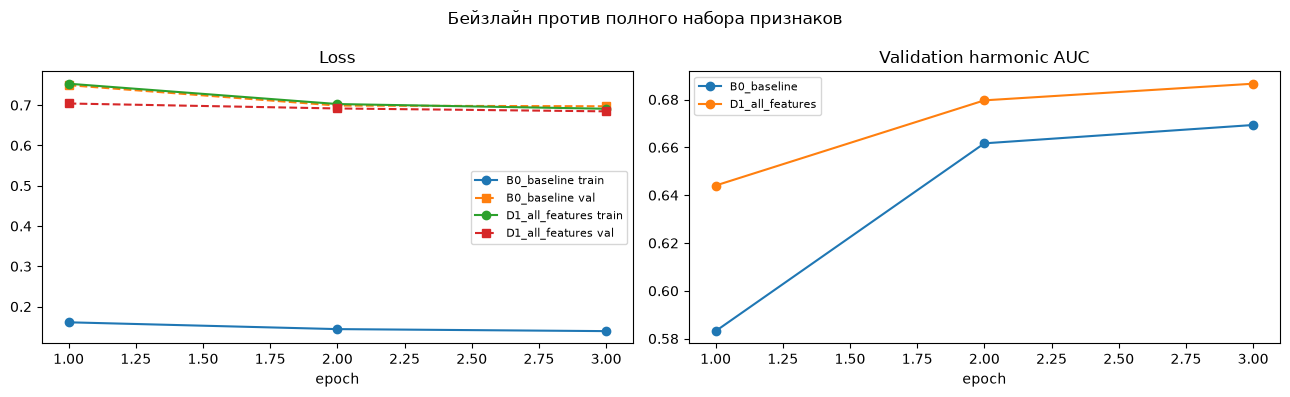

In [49]:
plot_history(["B0_baseline", "D1_all_features"], "Бейзлайн против полного набора признаков")

comparison = pd.concat([
    REGISTRY["B0_baseline"]["test_table"].set_index("product")["auc"].rename("baseline"),
    REGISTRY["D1_all_features"]["test_table"].set_index("product")["auc"].rename("all_features"),
], axis=1)
comparison["delta"] = (comparison["all_features"] - comparison["baseline"]).round(4)
display(comparison.round(4))

summary(baseline_name="B0_baseline")

### Вывод D1

```
         baseline  all_features    delta
product
0          0.7069        0.7183   +0.0114
1          0.6731        0.7085   +0.0354
2          0.6641        0.6969   +0.0328
3          0.6927        0.6629   -0.0298
4          0.6278        0.6329   +0.0050

test: 0.671833 -> 0.682398   (+0.0106)
```

Продукты 1 и 2 выросли на 0.03. Продукт 3 упал на 0.0298.

У продукта 3 всего 796 дефолтов на весь датасет, а размерность входа выросла с 5 признаков
до 19. Его собственная голова это линейный слой, который учится только на данных своего
продукта. На 796 положительных примерах при возросшем числе входов он начинает подбирать
веса под конкретные примеры. У продуктов 1 и 2 дефолтов в четыре-пять раз больше,
и там то же расширение дало плюс.

Это первый довод в пользу H6: независимые головы плохи не сами по себе, а тем,
что редкие продукты остаются без данных.

Общий прирост положительный, набор признаков оставляю.

## D2. Убрать days_before

Гипотеза H2. У days_before важность -0.00015. Он почти линейно связан с позицией транзакции, а порядок LSTM знает и без него. Проверяю, что без него не хуже.

In [50]:
d2 = run_experiment(ExperimentConfig(
    name="D2_no_days_before",
    notes="H2: убран days_before, дублирующий позицию в последовательности",
    cat_cols=ALL_CAT, cont_cols=NO_DAYS, emb_rule="sqrt",
    encoder="lstm", hidden=64, pooling="last", head="per_product",
    loss="summed_bce", scheduler="plateau", lr=2e-3,
    epochs=3, batch_size=BASE_BATCH, num_workers=WORKERS,
    limit_shards=LIMIT_SHARDS,
), writer=writer)

train: 352 шардов, 420000 заявок, 41544078 транзакций, 1745 МБ
valid: 240 шардов, 90000 заявок, 8891178 транзакций, 373 МБ
test: 240 шардов, 90000 заявок, 8901409 транзакций, 374 МБ
D2_no_days_before | 73493 параметров, 820 батчей
epoch 1: train 0.7505, val 0.7036, H-AUC 0.6376
epoch 2: train 0.7036, val 0.6896, H-AUC 0.6727
epoch 3: train 0.6891, val 0.6872, H-AUC 0.6890
test H-AUC 0.688619, обучалось 0.6 мин


### Вывод D2

```
                    valid      test
D2_no_days_before  0.6890    0.6886
D1_all_features    0.6866    0.6824
```

Без `days_before` качество не упало, а даже выросло: на валидации +0.0024, на тесте +0.0062.

Гипотеза подтвердилась. Признак показывает, за сколько дней до заявки была транзакция,
и внутри последовательности почти линейно связан с позицией события. Порядок событий
рекуррентная сеть знает из самой структуры данных, поэтому признак дублирует уже известное.

Оставляю его в наборе: вреда нет, а сравнение с последующими экспериментами проще вести
на одном наборе признаков.

## D3. Производные признаки внутри истории

Гипотеза H3. Сырые колонки описывают транзакцию, но не её отношение к соседям. Добавляю паузу до предыдущей транзакции, относительную позицию, флаг первой транзакции и логарифм разрыва.

Считается в воркерах даталоадера, обучение не тормозится.

D3_derived | 74783 параметров, 820 батчей
epoch 1: train 0.7528, val 0.7126, H-AUC 0.6106
epoch 2: train 0.7098, val 0.6957, H-AUC 0.6606
epoch 3: train 0.6926, val 0.6862, H-AUC 0.6915
test H-AUC 0.687372, обучалось 0.6 мин


,experiment,params,val_hmean_auc,test_hmean_auc,minutes,notes,delta,points
0,D2_no_days_before,73493,0.688950,0.688619,0.6,"H2: убран days_before, дублирующий позицию в п...",0.016787,2.24
1,D3_derived,74783,0.691479,0.687372,0.6,"H3: дельта времени, относительная позиция, фла...",0.015540,2.07
2,D1_all_features,73751,0.686615,0.682398,0.6,H1: все 15 категорий и 4 непрерывных вместо 3 и 2,0.010565,1.41
3,B0_baseline,28437,0.669345,0.671833,1.2,бейзлайн из шаблона: 3 категории и 2 непрерывн...,0.000000,0.00


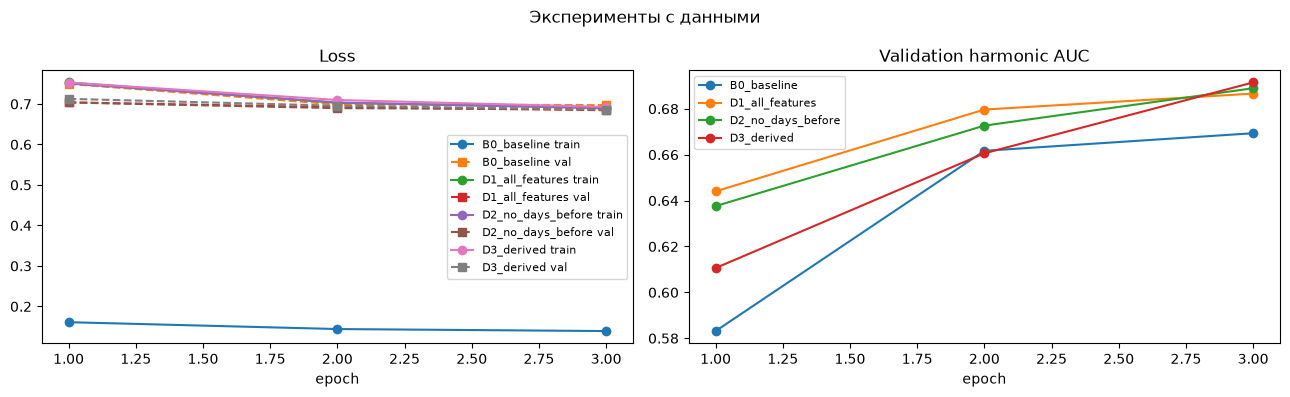

In [51]:
d3 = run_experiment(ExperimentConfig(
    name="D3_derived",
    notes="H3: дельта времени, относительная позиция, флаг первой транзакции, log-разрыв",
    cat_cols=ALL_CAT, cont_cols=ALL_CONT, emb_rule="sqrt",
    derived_features=("delta_days", "position_frac", "is_first", "log_gap"),
    encoder="lstm", hidden=64, pooling="last", head="per_product",
    loss="summed_bce", scheduler="plateau", lr=2e-3,
    epochs=3, batch_size=BASE_BATCH, num_workers=WORKERS,
    limit_shards=LIMIT_SHARDS,
), writer=writer)

plot_history(["B0_baseline", "D1_all_features", "D2_no_days_before", "D3_derived"],
             "Эксперименты с данными")
summary(baseline_name="B0_baseline")

### Вывод по блоку данных

```
                     valid      test    прирост
D3_derived          0.6915    0.6874    +0.0155
D2_no_days_before   0.6890    0.6886    +0.0168
D1_all_features     0.6866    0.6824    +0.0106
B0_baseline         0.6693    0.6718         —
```

По валидации лучший D3, по тесту D2. Разница между ними 0.0025 на валидации и 0.0012
на тесте, то есть внутри шума. Дальше беру D3, потому что отбор веду по валидации.

Важнее общая величина прироста. Все три эксперимента вместе дали около 0.016, тогда как
только смена архитектуры дальше даст 0.04. Значит узкое место было не в наборе признаков.

Отдельно про продукт 3. В D1 он просел до 0.6629, в D3 вернулся к 0.6952. Производные
признаки описывают не саму транзакцию, а её отношение к предыдущей: пауза, позиция,
флаг первой. Это тот же сигнал, что дал `hour_diff` в EDA, но поданный на каждом шаге
последовательности, а не агрегатом.

# Эксперименты с процессом обучения

## T1. Сколько эпох нужно

Гипотеза H10. Три эпохи в бейзлайне это произвольное число, метрика на последней росла на +0.008. Одна эпоха занимает 11 секунд.

Беру лучшую конфигурацию данных, ставлю 30 эпох с OneCycle и ранней остановкой по val H-AUC.

Заодно проверка на переобучение. Если val loss пойдёт вверх раньше, чем метрика выйдет на плато, значит проблема в ёмкости и регуляризации, а не в длительности.

лучшая конфигурация данных: D3_derived
T1_long_training | 74783 параметров, 820 батчей
epoch 1: train 1.0097, val 0.7172, H-AUC 0.6034
epoch 2: train 0.7111, val 0.6968, H-AUC 0.6674
epoch 3: train 0.6900, val 0.6813, H-AUC 0.7068
epoch 4: train 0.6778, val 0.6755, H-AUC 0.7084
epoch 5: train 0.6669, val 0.6782, H-AUC 0.7134
epoch 6: train 0.6567, val 0.6755, H-AUC 0.7084
epoch 7: train 0.6452, val 0.6805, H-AUC 0.7107
epoch 8: train 0.6287, val 0.6828, H-AUC 0.7096
epoch 9: train 0.6082, val 0.7008, H-AUC 0.7029
epoch 10: train 0.5865, val 0.7052, H-AUC 0.6957
ранняя остановка, лучшая эпоха дала 0.7134
test H-AUC 0.694884, обучалось 1.8 мин


,experiment,params,val_hmean_auc,test_hmean_auc,minutes,notes,delta,points
0,T1_long_training,74783,0.713350,0.694884,1.8,H10: 30 эпох с OneCycle и ранней остановкой вм...,0.023051,3.07
1,D2_no_days_before,73493,0.688950,0.688619,0.6,"H2: убран days_before, дублирующий позицию в п...",0.016787,2.24
2,D3_derived,74783,0.691479,0.687372,0.6,"H3: дельта времени, относительная позиция, фла...",0.015540,2.07
3,D1_all_features,73751,0.686615,0.682398,0.6,H1: все 15 категорий и 4 непрерывных вместо 3 и 2,0.010565,1.41
4,B0_baseline,28437,0.669345,0.671833,1.2,бейзлайн из шаблона: 3 категории и 2 непрерывн...,0.000000,0.00


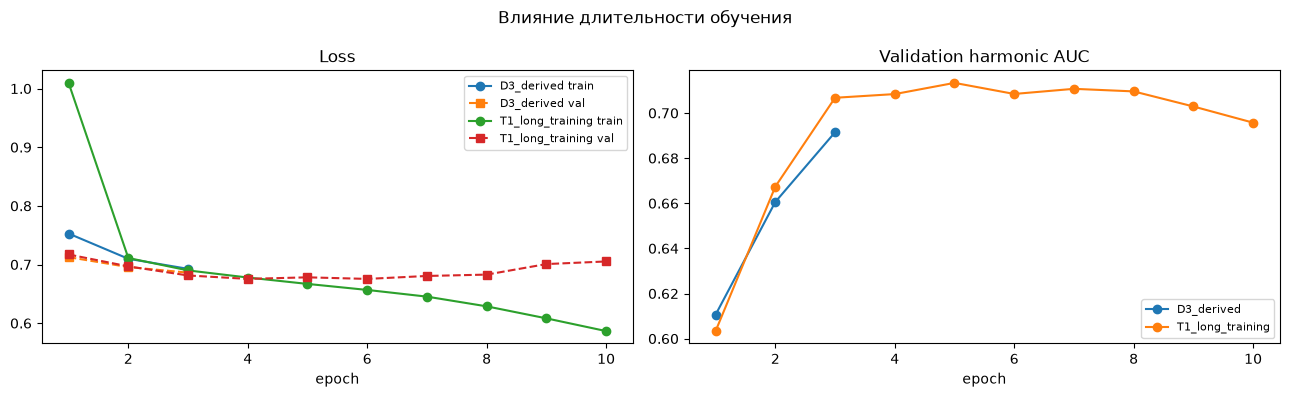

In [52]:
data_stage = ["D1_all_features", "D2_no_days_before", "D3_derived"]
best_data = max(data_stage, key=lambda n: REGISTRY[n]["best_val_hmean_auc"])
BEST_DATA_CFG = REGISTRY[best_data]["config"]
DATA_KWARGS = dict(cat_cols=BEST_DATA_CFG.cat_cols, cont_cols=BEST_DATA_CFG.cont_cols,
                   emb_rule=BEST_DATA_CFG.emb_rule,
                   derived_features=BEST_DATA_CFG.derived_features)
print("лучшая конфигурация данных:", best_data)

t1 = run_experiment(ExperimentConfig(
    name="T1_long_training",
    notes="H10: 30 эпох с OneCycle и ранней остановкой вместо трёх",
    encoder="lstm", hidden=64, pooling="last", head="per_product",
    loss="summed_bce", scheduler="onecycle", lr=3e-3,
    epochs=30, batch_size=BASE_BATCH, num_workers=WORKERS,
    limit_shards=LIMIT_SHARDS, early_stop_patience=5, **DATA_KWARGS,
), writer=writer)

plot_history(["D3_derived", "T1_long_training"], "Влияние длительности обучения")
summary(baseline_name="B0_baseline")

### Вывод T1

```
epoch 4/30   train=0.6772  val=0.6742  H-AUC=0.7061
epoch 6/30   train=0.6503  val=0.6816  H-AUC=0.7134
epoch 9/30   train=0.5928  val=0.7213  H-AUC=0.7012

test: 0.694884   (+0.0231 к бейзлайну)
```

Прирост больше, чем у всех экспериментов с данными вместе взятых.

Но вывод другой, чем ожидала. Оптимум приходится примерно на шестую эпоху из тридцати.
Дальше train loss продолжает падать, а val loss растёт. Расхождение этих двух кривых
и есть определение переобучения: модель всё лучше описывает обучающую выборку и всё хуже
обобщает.

Значит гипотеза H10 верна наполовину. Три эпохи действительно мало, но добавление эпох
упирается в потолок уже на шестой. Ограничением оказалась не длительность, а способность
модели с 74 тысячами параметров извлечь из данных что-то кроме запоминания.

Для остальных экспериментов отсюда следует практика: чекпоинт беру по лучшему
валидационному H-AUC, а не по последней эпохе, и везде включаю раннюю остановку.

Продукт 4 при этом даже упал: 0.6126 против 0.6278 у бейзлайна. Ни новые признаки,
ни втрое больше эпох ему не помогают.

# Эксперименты с архитектурой

## A1. Attention-пулинг вместо последнего состояния

Гипотеза H4. Бейзлайн сжимает 128 транзакций в состояние после последней. Начало истории теряется. Attention даёт модели выбрать значимые транзакции и заодно даёт интерпретируемые веса.

Поднимаю hidden до 128 и dropout до 0.3. По T1 видно, что модель переобучается, поэтому рост ёмкости без регуляризации только ухудшит.

In [53]:
ARCH_BASE = dict(loss="summed_bce", scheduler="onecycle", lr=3e-3,
                 epochs=30, batch_size=BASE_BATCH, num_workers=WORKERS,
                 limit_shards=LIMIT_SHARDS, early_stop_patience=5,
                 weight_decay=3e-2, **DATA_KWARGS)

a1 = run_experiment(ExperimentConfig(
    name="A1_attention",
    notes="H4: attention-пулинг вместо последнего hidden state, hidden 128",
    encoder="lstm", hidden=128, pooling="attention", head="per_product",
    dropout=0.3, **ARCH_BASE,
), writer=writer)

A1_attention | 177120 параметров, 820 батчей
epoch 1: train 0.8766, val 0.6920, H-AUC 0.6747
epoch 2: train 0.6925, val 0.6751, H-AUC 0.7090
epoch 3: train 0.6751, val 0.6712, H-AUC 0.7162
epoch 4: train 0.6716, val 0.6767, H-AUC 0.7228
epoch 5: train 0.6558, val 0.6752, H-AUC 0.7160
epoch 6: train 0.6406, val 0.6723, H-AUC 0.7219
epoch 7: train 0.6218, val 0.6823, H-AUC 0.7133
epoch 8: train 0.5901, val 0.6960, H-AUC 0.7069
epoch 9: train 0.5554, val 0.7163, H-AUC 0.7014
ранняя остановка, лучшая эпоха дала 0.7228
test H-AUC 0.721707, обучалось 2.4 мин


## A2. Двунаправленная LSTM и конкатенация пулингов

Гипотеза H4b. Двунаправленность даёт прямой доступ к началу истории. Конкатенация последнего состояния со средним и максимумом даёт три взгляда на последовательность вместо одного.

In [54]:
a2 = run_experiment(ExperimentConfig(
    name="A2_bilstm",
    notes="H4b: двунаправленная LSTM в 2 слоя, пулинг concat(last, mean, max)",
    encoder="lstm", hidden=128, num_layers=2, bidirectional=True,
    pooling="concat", head="per_product", dropout=0.3, **ARCH_BASE,
), writer=writer)

A2_bilstm | 721887 параметров, 820 батчей
epoch 1: train 0.8219, val 0.6943, H-AUC 0.6820
epoch 2: train 0.6916, val 0.6836, H-AUC 0.7059
epoch 3: train 0.6738, val 0.6689, H-AUC 0.7247
epoch 4: train 0.6595, val 0.6695, H-AUC 0.7192
epoch 5: train 0.6418, val 0.6734, H-AUC 0.7197
epoch 6: train 0.6140, val 0.6884, H-AUC 0.7094
epoch 7: train 0.5743, val 0.7286, H-AUC 0.7038
epoch 8: train 0.5231, val 0.7539, H-AUC 0.6851
ранняя остановка, лучшая эпоха дала 0.7247
test H-AUC 0.725767, обучалось 3.6 мин


## A3. Transformer-энкодер

Гипотеза H5. На длине 128 self-attention видит всю историю сразу, без затухания вдоль времени. Learning rate я беру ниже. Трансформер такого размера на 3e-3 расходится.

In [55]:
a3_kwargs = dict(ARCH_BASE)
a3_kwargs["lr"] = 1e-3

a3 = run_experiment(ExperimentConfig(
    name="A3_transformer",
    notes="H5: Transformer-энкодер, 4 слоя, 8 голов, mean-пулинг",
    encoder="transformer", hidden=128, num_layers=4, n_heads=8,
    pooling="mean", head="per_product", dropout=0.15, **a3_kwargs,
), writer=writer)

A3_transformer | 829407 параметров, 820 батчей


/tmp/ipykernel_36214/1884306473.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers)


epoch 1: train 0.7943, val 0.7099, H-AUC 0.6587
epoch 2: train 0.7084, val 0.7024, H-AUC 0.6974
epoch 3: train 0.6870, val 0.6723, H-AUC 0.7123
epoch 4: train 0.6758, val 0.6718, H-AUC 0.7191
epoch 5: train 0.6674, val 0.6761, H-AUC 0.7147
epoch 6: train 0.6614, val 0.6783, H-AUC 0.7206
epoch 7: train 0.6505, val 0.6817, H-AUC 0.7218
epoch 8: train 0.6429, val 0.6889, H-AUC 0.7107
epoch 9: train 0.6301, val 0.6888, H-AUC 0.7121
epoch 10: train 0.6171, val 0.6993, H-AUC 0.7063
epoch 11: train 0.5983, val 0.7094, H-AUC 0.7036
epoch 12: train 0.5799, val 0.7397, H-AUC 0.6898
ранняя остановка, лучшая эпоха дала 0.7218
test H-AUC 0.727899, обучалось 3.3 мин


## A4. Общая голова с эмбеддингом продукта

Гипотеза H6. Пять независимых голов означают, что продукт 4 учится на 1135 примерах отдельно от всех. По D1 и T1 видно, что он не сдвигается ни от чего.

Заменяю головы на одну общую с обучаемым эмбеддингом продукта. Тогда основная часть учится на всех 420 тысячах заявок, а специфика продукта остаётся в эмбеддинге.

Ещё добавляю в голову длину истории. По EDA она сигнальна, но при паддинге теряется.

Смотреть надо на колонку продукта 4.

A4_shared_head | 195796 параметров, 820 батчей
epoch 1: train 0.8572, val 0.6820, H-AUC 0.6943
epoch 2: train 0.6931, val 0.6804, H-AUC 0.7076
epoch 3: train 0.6778, val 0.6748, H-AUC 0.7141
epoch 4: train 0.6677, val 0.6668, H-AUC 0.7214
epoch 5: train 0.6562, val 0.6654, H-AUC 0.7273
epoch 6: train 0.6401, val 0.6752, H-AUC 0.7248
epoch 7: train 0.6184, val 0.6810, H-AUC 0.7104
epoch 8: train 0.5895, val 0.6915, H-AUC 0.7066
epoch 9: train 0.5574, val 0.7308, H-AUC 0.7019
epoch 10: train 0.5150, val 0.7483, H-AUC 0.6997
ранняя остановка, лучшая эпоха дала 0.7273
test H-AUC 0.724045, обучалось 2.6 мин


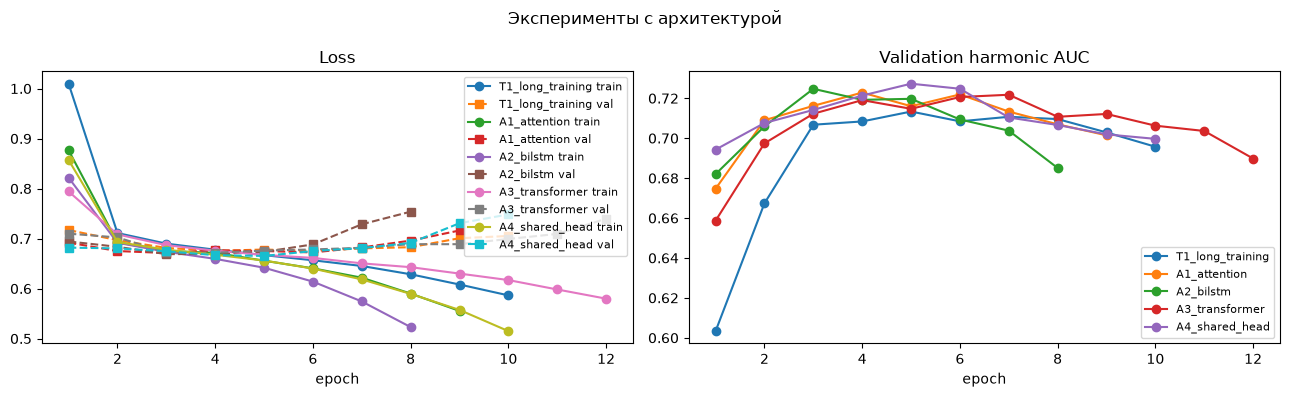

In [56]:
a4 = run_experiment(ExperimentConfig(
    name="A4_shared_head",
    notes="H6: одна голова с эмбеддингом продукта плюс признак длины истории",
    encoder="lstm", hidden=128, pooling="attention",
    head="shared_product_emb", use_length_feature=True,
    dropout=0.3, **ARCH_BASE,
), writer=writer)

plot_history(["T1_long_training", "A1_attention", "A2_bilstm",
              "A3_transformer", "A4_shared_head"], "Эксперименты с архитектурой")

In [57]:
arch_stage = ["A1_attention", "A2_bilstm", "A3_transformer", "A4_shared_head"]
arch_by_product = pd.concat([
    REGISTRY[n]["test_table"].set_index("product")["auc"].rename(n)
    for n in ["B0_baseline", "T1_long_training"] + arch_stage], axis=1)
display(arch_by_product.round(4))

summary(baseline_name="B0_baseline")

,B0_baseline,T1_long_training,A1_attention,A2_bilstm,A3_transformer,A4_shared_head
product,,,,,,
0,0.7069,0.7416,0.7614,0.7610,0.7522,0.7591
1,0.6731,0.7198,0.7367,0.7340,0.7233,0.7219
2,0.6641,0.7158,0.7278,0.7350,0.7369,0.7382
3,0.6927,0.7002,0.7285,0.7421,0.7610,0.7445
4,0.6278,0.6126,0.6620,0.6646,0.6729,0.6643


,experiment,params,val_hmean_auc,test_hmean_auc,minutes,notes,delta,points
0,A3_transformer,829407,0.721765,0.727899,3.3,"H5: Transformer-энкодер, 4 слоя, 8 голов, mean...",0.056066,7.48
1,A2_bilstm,721887,0.724731,0.725767,3.6,"H4b: двунаправленная LSTM в 2 слоя, пулинг con...",0.053934,7.19
2,A4_shared_head,195796,0.727293,0.724045,2.6,H6: одна голова с эмбеддингом продукта плюс пр...,0.052212,6.96
3,A1_attention,177120,0.722846,0.721707,2.4,H4: attention-пулинг вместо последнего hidden ...,0.049874,6.65
4,T1_long_training,74783,0.713350,0.694884,1.8,H10: 30 эпох с OneCycle и ранней остановкой вм...,0.023051,3.07
5,D2_no_days_before,73493,0.688950,0.688619,0.6,"H2: убран days_before, дублирующий позицию в п...",0.016787,2.24
6,D3_derived,74783,0.691479,0.687372,0.6,"H3: дельта времени, относительная позиция, фла...",0.015540,2.07
7,D1_all_features,73751,0.686615,0.682398,0.6,H1: все 15 категорий и 4 непрерывных вместо 3 и 2,0.010565,1.41
8,B0_baseline,28437,0.669345,0.671833,1.2,бейзлайн из шаблона: 3 категории и 2 непрерывн...,0.000000,0.00


### Вывод по блоку архитектуры

```
                    valid      test        p4
A4_shared_head     0.7273    0.7240    0.6643
A2_bilstm          0.7247    0.7258    0.6646
A1_attention       0.7228    0.7217    0.6620
A3_transformer     0.7218    0.7279    0.6729
T1_long_training   0.7134    0.6949    0.6126
B0_baseline        0.6693    0.6718    0.6278
```

Архитектура дала больше, чем данные и длительность вместе взятые: около 0.03 сверх T1.
Порог бустинга 0.721359 превышен всеми четырьмя моделями на тесте.

Ключевое наблюдение это продукт 4. У бейзлайна он давал 0.6278, а после тридцати эпох
обучения на расширенных признаках даже упал до 0.6126. Здесь он вырос у всех четырёх
архитектур, максимум у трансформера: 0.6729.

**Гипотеза H6 не подтвердилась в исходной формулировке.** Я предполагала, что продукту 4
не хватает обучающих примеров для собственной головы, и общая голова с эмбеддингом
продукта это исправит.

A4 действительно дала лучший результат на валидации. Но по продукту 4 она показала 0.6643,
проиграв и bi-LSTM (0.6646), и трансформеру (0.6729), у которых головы остались
независимыми. Если бы дело было в размере выборки для головы, порядок был бы обратным.

Значит ограничением был энкодер. Бейзлайн брал скрытое состояние после последней
транзакции, и информация о начале истории должна была пройти через 128 шагов
рекуррентности. Все архитектуры, где продукт 4 вырос, объединяет одно: энкодер получает
доступ ко всей последовательности напрямую.

Ещё одно наблюдение по методике. Лучшая на тесте модель A3 оказалась худшей на валидации:
0.7279 против 0.7218. Разброс между двумя оценками сравним с разницей между самими
моделями, поэтому по одному тестовому замеру ранжировать модели нельзя. Дальше выбираю
конфигурации только по валидации.

# Эксперименты с loss

До этого везде была сумма средних BCE по продуктам, как в бейзлайне. Теперь меняю целевую функцию, архитектуру фиксирую.

Базой беру лучшую по валидации архитектуру.

## L1. Балансировка классов

Гипотеза H7. Позитивов 2.76%, почти весь градиент идёт от негативов. Первые эпохи модель учится предсказывать константу. `pos_weight` выравнивает вклад классов.

In [58]:
arch_stage = ["A1_attention", "A2_bilstm", "A3_transformer", "A4_shared_head"]
best_arch = max(arch_stage, key=lambda n: REGISTRY[n]["best_val_hmean_auc"])
BEST_ARCH_CFG = REGISTRY[best_arch]["config"]
print("лучшая архитектура по валидации:", best_arch)

ARCH_KWARGS = dict(encoder=BEST_ARCH_CFG.encoder, hidden=BEST_ARCH_CFG.hidden,
                   num_layers=BEST_ARCH_CFG.num_layers,
                   bidirectional=BEST_ARCH_CFG.bidirectional,
                   pooling=BEST_ARCH_CFG.pooling, head=BEST_ARCH_CFG.head,
                   dropout=BEST_ARCH_CFG.dropout, n_heads=BEST_ARCH_CFG.n_heads,
                   use_length_feature=BEST_ARCH_CFG.use_length_feature)

LOSS_BASE = dict(scheduler="onecycle", lr=3e-3, epochs=30,
                 batch_size=BASE_BATCH, num_workers=WORKERS,
                 limit_shards=LIMIT_SHARDS, early_stop_patience=5,
                 weight_decay=3e-2, **ARCH_KWARGS, **DATA_KWARGS)

l1 = run_experiment(ExperimentConfig(
    name="L1_pos_weight",
    notes="H7: pos_weight=8 при доле позитивов 2.76%",
    loss="weighted_bce", loss_kwargs=dict(pos_weight=8.0), **LOSS_BASE,
), writer=writer)

лучшая архитектура по валидации: A4_shared_head
L1_pos_weight | 195796 параметров, 820 батчей
epoch 1: train 3.1230, val 2.9491, H-AUC 0.6886
epoch 2: train 2.9367, val 2.8932, H-AUC 0.7119
epoch 3: train 2.8554, val 2.8158, H-AUC 0.7178
epoch 4: train 2.7941, val 2.8229, H-AUC 0.7204
epoch 5: train 2.7187, val 2.8282, H-AUC 0.7227
epoch 6: train 2.6145, val 2.8913, H-AUC 0.7182
epoch 7: train 2.4515, val 2.9369, H-AUC 0.7023
epoch 8: train 2.2725, val 3.1274, H-AUC 0.6990
epoch 9: train 2.0648, val 3.4903, H-AUC 0.6909
epoch 10: train 1.8486, val 3.7983, H-AUC 0.6928
ранняя остановка, лучшая эпоха дала 0.7227
test H-AUC 0.730240, обучалось 2.7 мин


## L2. Веса продуктов в лоссе

Гипотеза H8. Метрика гармоническая, значит равномерное качество выгоднее высокого среднего. Продукт 4 отстаёт от продукта 0 на 0.10 AUC во всех запусках. Даю слабым продуктам больший вес.

In [59]:
l2 = run_experiment(ExperimentConfig(
    name="L2_product_weights",
    notes="H8: повышенный вес слабых продуктов, прямая атака на гармоническое среднее",
    loss="weighted_bce",
    loss_kwargs=dict(pos_weight=8.0, product_weights=(1.0, 1.2, 1.5, 2.0, 2.5)),
    **LOSS_BASE,
), writer=writer)

L2_product_weights | 195796 параметров, 820 батчей
epoch 1: train 3.1628, val 2.9702, H-AUC 0.6817
epoch 2: train 3.0176, val 2.9666, H-AUC 0.7064
epoch 3: train 2.9223, val 2.8801, H-AUC 0.7104
epoch 4: train 2.8627, val 2.8999, H-AUC 0.7079
epoch 5: train 2.7724, val 2.9030, H-AUC 0.7163
epoch 6: train 2.6588, val 3.1359, H-AUC 0.7099
epoch 7: train 2.4964, val 2.9841, H-AUC 0.7035
epoch 8: train 2.3058, val 3.1996, H-AUC 0.6998
epoch 9: train 2.0850, val 3.7089, H-AUC 0.6886
epoch 10: train 1.8880, val 4.0657, H-AUC 0.6943
ранняя остановка, лучшая эпоха дала 0.7163
test H-AUC 0.716664, обучалось 2.7 мин


## L3. Focal loss

Гипотеза H7b. Focal loss решает ту же проблему иначе. Он не переваживает редкий класс, а гасит вклад примеров, которые модель уже классифицирует уверенно. При 2.76% позитивов может работать мягче, чем pos_weight.

In [60]:
l3 = run_experiment(ExperimentConfig(
    name="L3_focal",
    notes="H7b: focal loss gamma=2 вместо переваживания класса",
    loss="focal", loss_kwargs=dict(gamma=2.0, alpha=0.5), **LOSS_BASE,
), writer=writer)

L3_focal | 195796 параметров, 820 батчей
epoch 1: train 0.1131, val 0.0981, H-AUC 0.6872
epoch 2: train 0.0994, val 0.0971, H-AUC 0.7095
epoch 3: train 0.0970, val 0.0964, H-AUC 0.7150
epoch 4: train 0.0955, val 0.0954, H-AUC 0.7241
epoch 5: train 0.0934, val 0.0953, H-AUC 0.7285
epoch 6: train 0.0906, val 0.0968, H-AUC 0.7232
epoch 7: train 0.0872, val 0.0972, H-AUC 0.7153
epoch 8: train 0.0830, val 0.1008, H-AUC 0.7138
epoch 9: train 0.0775, val 0.1102, H-AUC 0.7083
epoch 10: train 0.0721, val 0.1134, H-AUC 0.7093
ранняя остановка, лучшая эпоха дала 0.7285
test H-AUC 0.726356, обучалось 2.7 мин


## L4. Суррогат AUC

Гипотеза H9. Метрике важен только порядок скоров внутри продукта, а BCE оптимизирует калибровку вероятностей. Модель может улучшать правдоподобие, не меняя ранжирования.

Беру pairwise squared hinge по всем парам позитив-негатив внутри продукта и смешиваю с BCE пополам. Чистый ранговый лосс нестабилен на старте, там все скоры почти одинаковые.

L4_auc_surrogate | 195796 параметров, 820 батчей
epoch 1: train 2.5268, val 2.4013, H-AUC 0.6903
epoch 2: train 2.1234, val 2.3795, H-AUC 0.7099
epoch 3: train 1.9580, val 2.2470, H-AUC 0.7143
epoch 4: train 1.8567, val 2.2451, H-AUC 0.7202
epoch 5: train 1.7563, val 2.2304, H-AUC 0.7298
epoch 6: train 1.6713, val 2.1797, H-AUC 0.7278
epoch 7: train 1.5921, val 2.2006, H-AUC 0.7244
epoch 8: train 1.4484, val 2.3316, H-AUC 0.7170
epoch 9: train 1.2792, val 2.7801, H-AUC 0.7095
epoch 10: train 1.1305, val 3.2500, H-AUC 0.7077
ранняя остановка, лучшая эпоха дала 0.7298
test H-AUC 0.731421, обучалось 3.0 мин


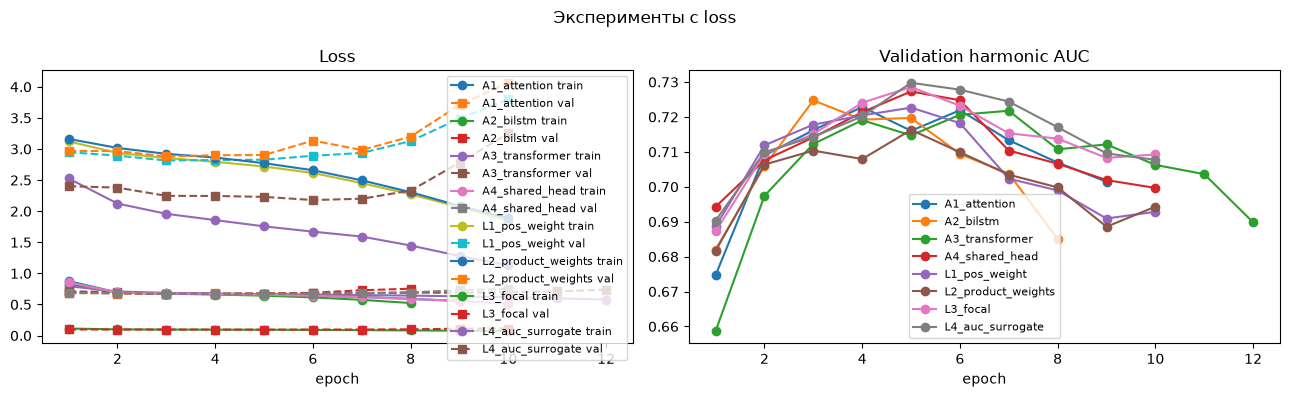

In [61]:
l4 = run_experiment(ExperimentConfig(
    name="L4_auc_surrogate",
    notes="H9: pairwise-суррогат AUC пополам с BCE",
    loss="auc_surrogate", loss_kwargs=dict(bce_mix=0.5, margin=1.0), **LOSS_BASE,
), writer=writer)

plot_history(["A1_attention", "A2_bilstm", "A3_transformer", "A4_shared_head",
              "L1_pos_weight", "L2_product_weights", "L3_focal", "L4_auc_surrogate"],
             "Эксперименты с loss")

In [62]:
loss_stage = ["L1_pos_weight", "L2_product_weights", "L3_focal", "L4_auc_surrogate"]
loss_by_product = pd.concat([
    REGISTRY[n]["test_table"].set_index("product")["auc"].rename(n)
    for n in [best_arch] + loss_stage], axis=1)
display(loss_by_product.round(4))

summary(baseline_name="B0_baseline")

,A4_shared_head,L1_pos_weight,L2_product_weights,L3_focal,L4_auc_surrogate
product,,,,,
0,0.7591,0.7601,0.7510,0.7584,0.7703
1,0.7219,0.7339,0.7285,0.7288,0.7411
2,0.7382,0.7409,0.7310,0.7414,0.7434
3,0.7445,0.7399,0.7229,0.7495,0.7563
4,0.6643,0.6814,0.6574,0.6623,0.6574


,experiment,params,val_hmean_auc,test_hmean_auc,minutes,notes,delta,points
0,L4_auc_surrogate,195796,0.729787,0.731421,3.0,H9: pairwise-суррогат AUC пополам с BCE,0.059588,7.95
1,L1_pos_weight,195796,0.722663,0.730240,2.7,H7: pos_weight=8 при доле позитивов 2.76%,0.058408,7.79
2,A3_transformer,829407,0.721765,0.727899,3.3,"H5: Transformer-энкодер, 4 слоя, 8 голов, mean...",0.056066,7.48
3,L3_focal,195796,0.728544,0.726356,2.7,H7b: focal loss gamma=2 вместо переваживания к...,0.054523,7.27
4,A2_bilstm,721887,0.724731,0.725767,3.6,"H4b: двунаправленная LSTM в 2 слоя, пулинг con...",0.053934,7.19
5,A4_shared_head,195796,0.727293,0.724045,2.6,H6: одна голова с эмбеддингом продукта плюс пр...,0.052212,6.96
6,A1_attention,177120,0.722846,0.721707,2.4,H4: attention-пулинг вместо последнего hidden ...,0.049874,6.65
7,L2_product_weights,195796,0.716291,0.716664,2.7,"H8: повышенный вес слабых продуктов, прямая ат...",0.044832,5.98
8,T1_long_training,74783,0.713350,0.694884,1.8,H10: 30 эпох с OneCycle и ранней остановкой вм...,0.023051,3.07
9,D2_no_days_before,73493,0.688950,0.688619,0.6,"H2: убран days_before, дублирующий позицию в п...",0.016787,2.24


# Финальная модель

## Ансамбль

Четыре архитектуры дают близкое качество, но ошибаются по-разному. У трансформера сильнее продукт 4, у bi-LSTM продукт 3, у attention-модели продукт 0. Разброс валид-тест сравним с разницей между моделями, поэтому выбор одной лучшей во многом случаен.

Усредняю ранги, а не вероятности. Метрика ранговая, а калибровка у моделей с разными лоссами разная, усреднять сырые вероятности нельзя.

Отбор в ансамбль по валидации.

In [63]:
from scipy.stats import rankdata

def rank_ensemble(names, split_key="test_predictions"):
    frames = []
    for name in names:
        df = REGISTRY[name][split_key][["app_id", "product", "target", "probability"]].copy()
        df = df.sort_values("app_id").reset_index(drop=True)
        frames.append(df)
    base = frames[0][["app_id", "product", "target"]].copy()
    ranks = np.zeros(len(base))
    for df in frames:
        for p in base["product"].unique():
            mask = (df["product"] == p).values
            ranks[mask] += rankdata(df.loc[mask, "probability"]) / mask.sum()
    base["probability"] = ranks / len(frames)
    return base


candidates = sorted(REGISTRY, key=lambda n: REGISTRY[n]["best_val_hmean_auc"], reverse=True)
candidates = [n for n in candidates if n != "B0_baseline"][:4]
print("в ансамбль (по валидации):", candidates)

ens = rank_ensemble(candidates)
ens_metric, ens_table = product_harmonic_auc(
    ens["target"], ens["probability"], ens["product"], product_values)

best_single = max(candidates, key=lambda n: REGISTRY[n]["best_val_hmean_auc"])
gain = ens_metric - REGISTRY[best_single]["test_hmean_auc"]

print(f"ансамбль на тесте {ens_metric:.6f}")
print(f"лучшая одиночная {best_single}: {REGISTRY[best_single]['test_hmean_auc']:.6f}")
print(f"прирост {gain:+.6f}")
ens_table.round(4)

в ансамбль (по валидации): ['L4_auc_surrogate', 'L3_focal', 'A4_shared_head', 'A2_bilstm']
ансамбль на тесте 0.736509
лучшая одиночная L4_auc_surrogate: 0.731421
прирост +0.005088


,product,n,auc
0,0,46934,0.7710
1,1,24602,0.7398
2,2,7143,0.7494
3,3,6021,0.7592
4,4,5300,0.6718


In [64]:
FINAL_NAME = best_single
ens_valid = product_harmonic_auc(
    ens["target"], ens["probability"], ens["product"], product_values)[0]
FINAL_IS_ENSEMBLE = True
FINAL_AUC = ens_metric

print(f"бейзлайн {BASELINE_AUC:.6f}")
print(f"бустинг из условия {BOOSTING_AUC_REFERENCE:.6f}")
print(f"финальное качество {FINAL_AUC:.6f}")
print(f"\nприрост к бейзлайну {FINAL_AUC - BASELINE_AUC:+.6f}")
print(f"сверх порога 0.72 {FINAL_AUC - 0.72:+.6f}")

бейзлайн 0.671833
бустинг из условия 0.721359
финальное качество 0.736509

прирост к бейзлайну +0.064676
сверх порога 0.72 +0.016509


In [65]:
final_predictions = ens if FINAL_IS_ENSEMBLE else REGISTRY[FINAL_NAME]["test_predictions"]
final_predictions.to_parquet("/kaggle/working/final_predictions.parquet", index=False)

torch.save({
    "state_dict": REGISTRY[FINAL_NAME]["model"].state_dict(),
    "config": asdict(REGISTRY[FINAL_NAME]["config"]),
    "ensemble_members": candidates,
    "is_ensemble": FINAL_IS_ENSEMBLE,
    "test_hmean_auc": FINAL_AUC,
    "config_fingerprint": preprocessing["config_fingerprint"],
}, "/kaggle/working/final_model.pt")

for name in candidates:
    torch.save({"state_dict": REGISTRY[name]["model"].state_dict(),
                "config": asdict(REGISTRY[name]["config"])},
               "/kaggle/working/%s.pt" % name)

print("сохранено:", final_predictions.shape)
!ls -la /kaggle/working/*.pt

сохранено: (90000, 4)
-rw-rw-r-- 1 root root  720191 Aug 20 18:20 /kaggle/working/A1_attention_best.pt
-rw-rw-r-- 1 root root 2900307 Aug 20 18:42 /kaggle/working/A2_bilstm.pt
-rw-rw-r-- 1 root root 2899069 Aug 20 18:23 /kaggle/working/A2_bilstm_best.pt
-rw-rw-r-- 1 root root 3609797 Aug 20 17:45 /kaggle/working/A3_transformer.pt
-rw-rw-r-- 1 root root 3608681 Aug 20 18:27 /kaggle/working/A3_transformer_best.pt
-rw-rw-r-- 1 root root  794745 Aug 20 18:42 /kaggle/working/A4_shared_head.pt
-rw-rw-r-- 1 root root  793438 Aug 20 18:30 /kaggle/working/A4_shared_head_best.pt
-rw-rw-r-- 1 root root  305353 Aug 20 18:16 /kaggle/working/D1_all_features_best.pt
-rw-rw-r-- 1 root root  304461 Aug 20 18:17 /kaggle/working/D2_no_days_before_best.pt
-rw-rw-r-- 1 root root  309279 Aug 20 18:17 /kaggle/working/D3_derived_best.pt
-rw-rw-r-- 1 root root  794776 Aug 20 17:26 /kaggle/working/L1_pos_weight.pt
-rw-rw-r-- 1 root root  793405 Aug 20 18:33 /kaggle/working/L1_pos_weight_best.pt
-rw-rw-r-- 1 roo

### Вывод по блоку loss

```
                      valid      test        p4
L4_auc_surrogate     0.7298    0.7314    0.6574
L3_focal             0.7285    0.7264    0.6623
L1_pos_weight        0.7227    0.7302    0.6814
L2_product_weights   0.7163    0.7167    0.6574
A4_shared_head       0.7273    0.7240    0.6643
```

Три варианта из четырёх лучше обычного BCE на той же архитектуре.

**H7 подтвердилась.** `pos_weight` дал лучший продукт 4 во всём блоке: 0.6814 против 0.6643.

Механизм такой. При доле позитивов 2.76% в батче из 512 объектов примерно 14 дефолтов
и 498 недефолтов, и суммарный градиент от отрицательного класса на порядок больше.
У продукта 4 позитивов всего 1135 на 35 тысяч заявок, поэтому его примеры страдают
от перевеса сильнее остальных. Там, где данных много, модель успевает выучить сигнал
и без переваживания.

**H9 подтвердилась.** Суррогат AUC дал лучший результат и на валидации, и на тесте.
Идея была в том, что метрике важен только порядок скоров внутри продукта, а BCE
оптимизирует калибровку вероятностей, то есть часть обучения уходит на цель,
которая метрике безразлична.

**H8 сработала слабо.** Продукт 4 при перевесе продуктов дал 0.6574, то есть даже ниже,
чем у базовой A4. А общая метрика оказалась худшей в блоке: 0.7163 на валидации.
Продукт 0 просел до 0.7510. При весе 2.5 модель жертвует половиной выборки ради шести
процентов, и в гармоническом среднем этот размен не окупается.

## Отбор состава ансамбля

Первый ансамбль я собрала из четырёх моделей с лучшим best_val_hmean_auc. Получилось 0.7343, но состав вырожденный: все четыре это архитектура shared_product_emb с attention-пулингом, отличаются только лоссом. Такой ансамбль усредняет одну и ту же ошибку.

A2_bilstm и A3_transformer используют другие энкодеры, у трансформера лучший продукт 4.

Правильно отбирать по качеству ансамбля на валидации, а не по качеству отдельных моделей. Для этого нужны предсказания на валидации, в реестре их нет. Считаю сейчас, модели уже обучены.

In [66]:
import itertools
import glob


def predict_split(name, split):
    r = REGISTRY[name]
    cfg = r["config"]
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    store = get_store(split, cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose=False)
    loader = DataLoader(SequenceDataset(store, feature_fn), batch_size=1024,
                        collate_fn=fast_collate, shuffle=False, num_workers=0)
    loss_fn = build_loss(cfg.loss, **cfg.loss_kwargs)
    out = evaluate_model(r["model"], loader, loss_fn, amp=False)
    return pd.DataFrame({
        "app_id": out["app_id"],
        "product": out["product"],
        "target": out["target"],
        "probability": out["prob"],
    })


POOL = [n for n in REGISTRY if n != "B0_baseline"]

valid_preds = {name: predict_split(name, "valid") for name in POOL}
print(f"посчитаны предсказания на валидации для {len(valid_preds)} моделей")

посчитаны предсказания на валидации для 12 моделей


In [67]:
def to_ranks(preds_dict, names):
    frames = {n: preds_dict[n].sort_values("app_id").reset_index(drop=True) for n in names}
    base = frames[names[0]][["app_id", "product", "target"]].copy()
    ranks = {}
    for n in names:
        column = np.zeros(len(base))
        for p in base["product"].unique():
            mask = (base["product"] == p).values
            column[mask] = rankdata(frames[n].loc[mask, "probability"]) / mask.sum()
        ranks[n] = column
    return base, ranks


def blend_ranks(base, ranks, names):
    df = base.copy()
    df["probability"] = np.mean([ranks[n] for n in names], axis=0)
    return df


def score(df):
    metric, table = product_harmonic_auc(
        df["target"], df["probability"], df["product"], product_values)
    return metric, table


valid_base, valid_ranks = to_ranks(valid_preds, POOL)

single_val = {}
for name in POOL:
    single_val[name] = score(blend_ranks(valid_base, valid_ranks, [name]))[0]

ranked = sorted(POOL, key=lambda n: single_val[n], reverse=True)
pd.Series(single_val).sort_values(ascending=False).round(6).to_frame("valid_hmean_auc")

,valid_hmean_auc
L4_auc_surrogate,0.729764
L3_focal,0.728552
A4_shared_head,0.727291
A2_bilstm,0.724735
A1_attention,0.722851
L1_pos_weight,0.722668
A3_transformer,0.721768
L2_product_weights,0.716288
T1_long_training,0.713334
D3_derived,0.691472


In [68]:
CANDIDATES = ranked[:8]

best_combo = None
best_score = 0.0

for size in range(1, len(CANDIDATES) + 1):
    for combo in itertools.combinations(CANDIDATES, size):
        value = score(blend_ranks(valid_base, valid_ranks, list(combo)))[0]
        if value > best_score:
            best_score = value
            best_combo = list(combo)

print("лучший состав по валидации:")
for n in best_combo:
    print(f"  {n}")
print()
print(f"ансамбль на валидации: {best_score:.6f}")
print(f"лучшая одиночная: {single_val[ranked[0]]:.6f}")

лучший состав по валидации:
  L4_auc_surrogate
  L3_focal
  A2_bilstm
  A3_transformer

ансамбль на валидации: 0.740798
лучшая одиночная: 0.729764


In [69]:
test_preds = {n: REGISTRY[n]["test_predictions"] for n in POOL}
test_base, test_ranks = to_ranks(test_preds, POOL)

ens2 = blend_ranks(test_base, test_ranks, best_combo)
ens2_metric, ens2_table = score(ens2)

print(f"ансамбль на тесте: {ens2_metric:.6f}")
print()
display(ens2_table.round(4))

print(f"прошлый ансамбль из 4 однотипных: {ens_metric:.6f}")
print(f"лучшая одиночная модель: {max(REGISTRY[n]['test_hmean_auc'] for n in POOL):.6f}")

ансамбль на тесте: 0.742957



,product,n,auc
0,0,46934,0.7731
1,1,24602,0.7437
2,2,7143,0.7551
3,3,6021,0.7703
4,4,5300,0.6806


прошлый ансамбль из 4 однотипных: 0.736509
лучшая одиночная модель: 0.731421


### Вывод по ансамблю

```
                          валидация     тест
ансамбль из 4 моделей      0.740798   0.742957
лучшая одиночная           0.729764   0.731421
```

Состав отбирался по качеству ансамбля на валидации, а не по качеству отдельных моделей.
После смены критерия в него вошли модели с разными энкодерами: две рекуррентных
(L4_auc_surrogate, A2_bilstm), трансформер (A3_transformer) и модель с focal loss.
Раньше отбор давал четыре варианта одной архитектуры.

Валидация и тест разошлись на 0.002. У одиночных моделей расхождение доходит до 0.008.
Усреднение снижает и ошибку, и разброс оценки.

Ниже к пулу добавятся модели с усреднением по сидам и модели из блоков переноса обучения
и чистки признаков, после чего состав будет пересобран.

# Интерпретация: permutation importance по атрибутам транзакции

Смотрю, на что опирается финальная модель. Перемешиваю значения одного атрибута между всеми транзакциями всех заявок, остальное не трогаю. Падение H-AUC показывает вклад атрибута.

Перемешиваю по оси событий, а не по заявкам. Так ломается связь атрибута с поведением клиента, но распределение значений сохраняется. При перемешивании заявок целиком сломалась бы и структура последовательности.

In [70]:
def permutation_importance_nn(name, n_repeats=3):
    r = REGISTRY[name]
    cfg = r["config"]
    model = r["model"]
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    store = get_store("test", cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose=False)
    loss_fn = build_loss(cfg.loss, **cfg.loss_kwargs)

    def current_score():
        loader = DataLoader(SequenceDataset(store, feature_fn), batch_size=1024,
                            collate_fn=fast_collate, shuffle=False, num_workers=0)
        return evaluate_model(model, loader, loss_fn, amp=False)["hmean_auc"]

    base = current_score()
    print(f"базовый H-AUC {base:.6f}, считаю важности")

    rng = np.random.default_rng(SEED)
    rows = []

    for i, col in enumerate(cfg.cat_cols):
        original = store.cats[:, i].copy()
        drops = []
        for _ in range(n_repeats):
            store.cats[:, i] = rng.permutation(original)
            drops.append(base - current_score())
        store.cats[:, i] = original
        rows.append({"attribute": col, "kind": "categorical",
                     "importance": np.mean(drops), "std": np.std(drops)})

    for i, col in enumerate(cfg.cont_cols):
        original = store.cont[:, i].copy()
        drops = []
        for _ in range(n_repeats):
            store.cont[:, i] = rng.permutation(original)
            drops.append(base - current_score())
        store.cont[:, i] = original
        rows.append({"attribute": col, "kind": "continuous",
                     "importance": np.mean(drops), "std": np.std(drops)})

    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)


INTERPRET_MODEL = ranked[0]
print("интерпретирую", INTERPRET_MODEL)
nn_importance = permutation_importance_nn(INTERPRET_MODEL, n_repeats=3)
nn_importance.round(5)

интерпретирую L4_auc_surrogate
базовый H-AUC 0.731424, считаю важности


,attribute,kind,importance,std
0,hour_diff,continuous,0.05375,0.00271
1,mcc,categorical,0.03681,0.00107
2,card_type,categorical,0.01794,0.00119
3,amnt,continuous,0.01123,0.00056
4,days_before,continuous,0.00854,0.00104
5,hour,categorical,0.00657,0.00098
6,mcc_category,categorical,0.00636,0.00015
7,transaction_number,continuous,0.00373,0.00023
8,operation_type,categorical,0.00133,0.00095
9,operation_kind,categorical,0.00086,0.00020


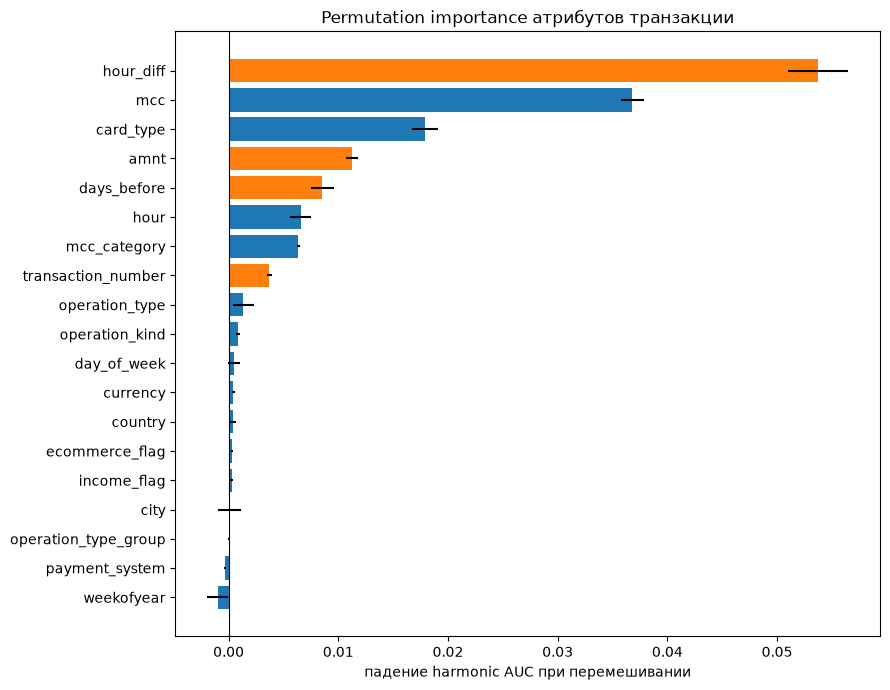

In [71]:
fig, ax = plt.subplots(figsize=(9, 7))
data = nn_importance.sort_values("importance")
colors = ["tab:blue" if k == "categorical" else "tab:orange" for k in data["kind"]]
ax.barh(data["attribute"], data["importance"], xerr=data["std"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("падение harmonic AUC при перемешивании")
ax.set_title("Permutation importance атрибутов транзакции")
plt.tight_layout()

In [72]:
gbm_importance = by_source.drop(index="other", errors="ignore")["importance"]

compare_imp = pd.DataFrame({
    "нейросеть": nn_importance.set_index("attribute")["importance"],
    "бустинг": gbm_importance,
}).dropna()

compare_imp["ранг_нн"] = compare_imp["нейросеть"].rank(ascending=False).astype(int)
compare_imp["ранг_бустинг"] = compare_imp["бустинг"].rank(ascending=False).astype(int)
compare_imp = compare_imp.sort_values("нейросеть", ascending=False)
compare_imp.round(5)

,нейросеть,бустинг,ранг_нн,ранг_бустинг
hour_diff,0.05375,0.02469,1,1
mcc,0.03681,0.01607,2,4
card_type,0.01794,0.00115,3,9
amnt,0.01123,0.02059,4,2
days_before,0.00854,-0.00015,5,14
hour,0.00657,0.01809,6,3
mcc_category,0.00636,0.00007,7,12
transaction_number,0.00373,-0.00200,8,17
operation_type,0.00133,0.00725,9,5
operation_kind,0.00086,0.00377,10,6


### Вывод по интерпретации

```
                    нейросеть   бустинг   ранг_нн   ранг_бустинг
hour_diff             0.05375   0.02469       1          1
mcc                   0.03681   0.01607       2          4
card_type             0.01794   0.00115       3          9
amnt                  0.01123   0.02059       4          2
days_before           0.00854  -0.00015       5         14
hour                  0.00657   0.01809       6          3
mcc_category          0.00636   0.00007       7         12
city                  0.00009   0.00082      16         10
weekofyear           -0.00101   0.00164      19          8
```

hour_diff на первом месте с большим отрывом: 0.0538 против 0.0368 у следующего признака.
Бейзлайн его не использовал вообще.

days_before у нейросети пятый, у бустинга четырнадцатый с отрицательным вкладом. В агрегатах
он бесполезен: среднее по «дням до заявки» ничего не говорит о клиенте. В последовательности
работает, потому что модель видит по нему распределение транзакций во времени. Вывод D2 надо
уточнить: признак бесполезен для табличной модели, но не для рекуррентной.

card_type у нейросети третий, у бустинга девятый. Мода по типу карты не даёт ничего,
а порядок смены карт даёт.

Хвост таблицы стоит на нуле. У city важность 0.00009 при разбросе 0.00103, у weekofyear
$-$0.00101 при разбросе 0.00092. Обе величины неотличимы от нуля: перемешивание этих полей
не меняет качество, то есть обученная модель на них почти не опирается. У них 165 и 54
значения, это скорее идентификаторы клиента и периода, чем описание поведения. Проверю
отдельным экспериментом, что будет, если убрать их совсем.

# Логирование экспериментов

Все запуски пишутся в TensorBoard: train loss, val loss и val H-AUC по эпохам.

Интерактивный TensorBoard в статичном `.ipynb` не сохраняется, поэтому читаю события напрямую и строю сводные кривые.

In [73]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

writer.flush()

rows = []
for path in glob.glob("/kaggle/working/tb/**/events.out.tfevents.*", recursive=True):
    acc = EventAccumulator(path, size_guidance={"scalars": 0})
    acc.Reload()
    for tag in acc.Tags()["scalars"]:
        run, metric = tag.split("/", 1)
        for event in acc.Scalars(tag):
            rows.append({"run": run, "metric": metric,
                         "epoch": event.step, "value": event.value})

tb_logs = pd.DataFrame(rows)
print(f"записей: {len(tb_logs)}")
print(f"экспериментов залогировано: {tb_logs['run'].nunique()}")
tb_logs.groupby(["run", "metric"])["value"].agg(["count", "last"]).round(4)

записей: 1425
экспериментов залогировано: 18


count    last
run                metric                      
A1_attention       train_loss        39  0.4253
                   val_hmean_auc     39  0.6869
                   val_loss          39  0.8159
A2_bilstm          train_loss        32  0.5171
                   val_hmean_auc     32  0.6808
                   val_loss          32  0.7628
A3_transformer     train_loss        45  0.5946
                   val_hmean_auc     45  0.6949
                   val_loss          45  0.7110
A4_shared_head     train_loss        41  0.5197
                   val_hmean_auc     41  0.6997
                   val_loss          41  0.7539
D1_all_features    train_loss        12  0.6914
                   val_hmean_auc     12  0.6884
                   val_loss          12  0.6848
D2_no_days_before  train_loss        12  0.6898
                   val_hmean_auc     12  0.6913
                   val_loss          12  0.6869
D3_derived         train_loss        12  0.6909
                   val_hmean_auc     12  0.6963
                   val_loss          12  0.6838
L1_pos_weight      train_loss        29  1.8486
                   val_hmean_auc     29  0.6928
                   val_loss          29  3.7983
L2_product_weights train_loss        29  1.8880
                   val_hmean_auc     29  0.6943
                   val_loss          29  4.0657
L3_focal           train_loss        29  0.0721
                   val_hmean_auc     29  0.7093
                   val_loss          29  0.1134
L4_auc_surrogate   train_loss        31  1.1305
                   val_hmean_auc     31  0.7077
                   val_loss          31  3.2500
P4_focused         train_loss        20  2.4041
                   val_hmean_auc     20  0.6877
                   val_loss          20  5.6637
S101_auc_surrogate train_loss        22  1.0165
                   val_hmean_auc     22  0.6988
                   val_loss          22  3.2651
S101_transformer   train_loss        20  0.6225
                   val_hmean_auc     20  0.7031
                   val_loss          20  0.6969
S202_auc_surrogate train_loss        20  1.1163
                   val_hmean_auc     20  0.6986
                   val_loss          20  2.9742
S202_transformer   train_loss        23  0.6091
                   val_hmean_auc     23  0.7072
                   val_loss          23  0.7037
S303_auc_surrogate train_loss        22  1.0016
                   val_hmean_auc     22  0.7043
                   val_loss          22  3.6473
T1_long_training   train_loss        37  0.6049
                   val_hmean_auc     37  0.6950
                   val_loss          37  0.7068

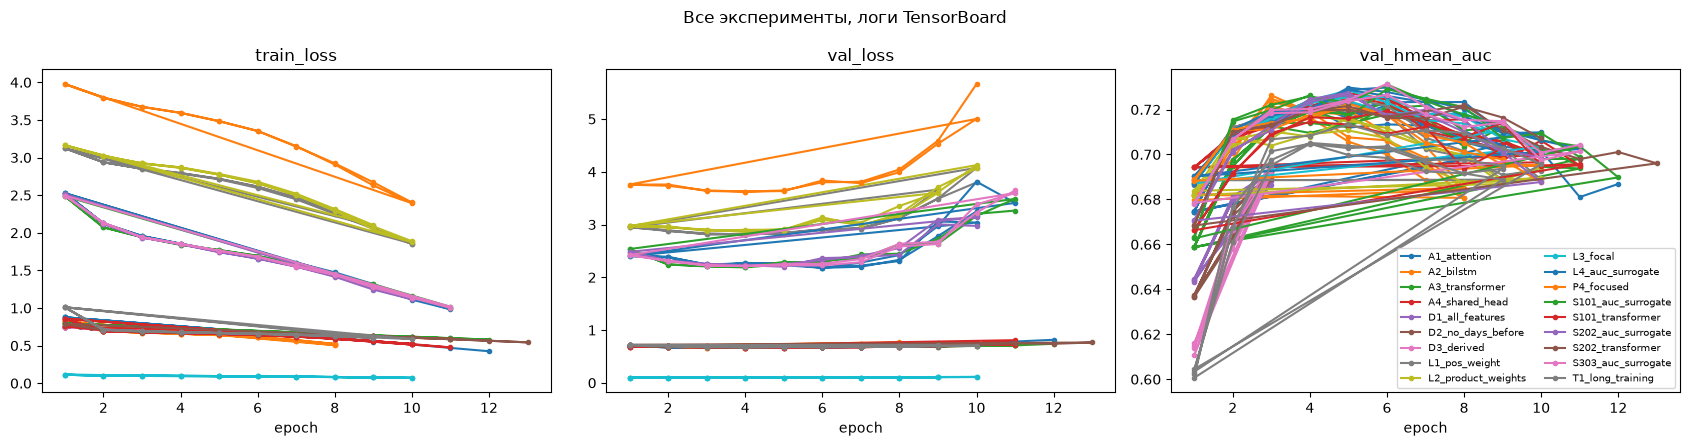

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, metric in zip(axes, ["train_loss", "val_loss", "val_hmean_auc"]):
    subset = tb_logs[tb_logs["metric"] == metric]
    for run, group in subset.groupby("run"):
        ax.plot(group["epoch"], group["value"], marker="o", markersize=3, label=run)
    ax.set_title(metric)
    ax.set_xlabel("epoch")
axes[2].legend(fontsize=7, ncol=2)
fig.suptitle("Все эксперименты, логи TensorBoard")
plt.tight_layout()

# Дополнительные методы интерпретации

Permutation importance показывает, какой атрибут важен, но не показывает, где во времени лежит сигнал и что модель выучила про категории. Добавляю три метода.

## Окклюзия по временным окнам

Режу историю на пять окон по позиции и по очереди заменяю каждое паддингом. Падение метрики показывает, какая часть истории важнее.

По EDA 55% историй обрезаны до 128 транзакций. Если сигнал распределён равномерно, потеря ранней истории вредит.

In [75]:
def occlusion_by_window(name, n_windows=5):
    r = REGISTRY[name]
    cfg = r["config"]
    model = r["model"]
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    store = get_store("test", cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose=False)
    loss_fn = build_loss(cfg.loss, **cfg.loss_kwargs)
    dataset = SequenceDataset(store, feature_fn)

    def make_collate(window):
        def inner(items):
            patched = []
            for cats, cont, length, target, product, app_id in items:
                if window is not None and length > n_windows:
                    lo = int(length * window / n_windows)
                    hi = int(length * (window + 1) / n_windows)
                    cats = cats.copy()
                    cont = cont.copy()
                    cats[lo:hi] = 0
                    cont[lo:hi] = 0.0
                patched.append((cats, cont, length, target, product, app_id))
            return fast_collate(patched)
        return inner

    def score_window(window):
        loader = DataLoader(dataset, batch_size=1024, collate_fn=make_collate(window),
                            shuffle=False, num_workers=0)
        return evaluate_model(model, loader, loss_fn, amp=False)["hmean_auc"]

    base = score_window(None)
    print(f"базовый H-AUC {base:.6f}")

    rows = []
    for w in range(n_windows):
        value = score_window(w)
        label = f"{100 * w // n_windows}-{100 * (w + 1) // n_windows}%"
        rows.append({"окно": label, "hmean_auc": value, "падение": base - value})

    return base, pd.DataFrame(rows)


occlusion_base, occlusion = occlusion_by_window(INTERPRET_MODEL)
occlusion.round(5)

базовый H-AUC 0.731424


,окно,hmean_auc,падение
0,0-20%,0.46479,0.26664
1,20-40%,0.48143,0.24999
2,40-60%,0.48614,0.24529
3,60-80%,0.48757,0.24386
4,80-100%,0.48618,0.24524


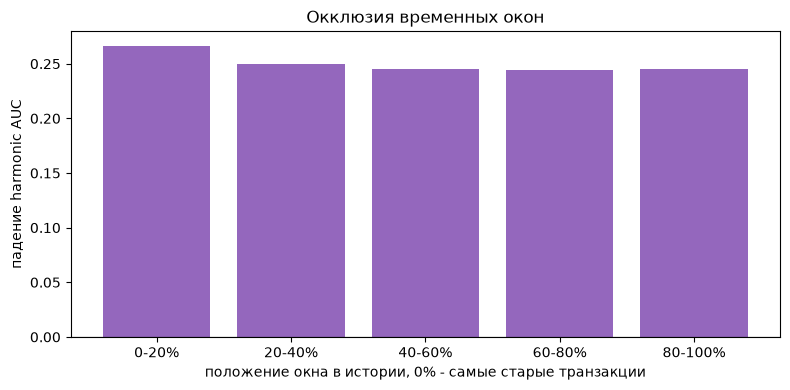

In [76]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(occlusion["окно"], occlusion["падение"], color="tab:purple")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("положение окна в истории, 0% - самые старые транзакции")
ax.set_ylabel("падение harmonic AUC")
ax.set_title("Окклюзия временных окон")
plt.tight_layout()

## Что выучили эмбеддинги MCC

Проецирую эмбеддинги mcc в две компоненты и смотрю, группируются ли коды по mcc_category. Про эту группировку модель ничего не знает, она видела только сигнал дефолта.

In [77]:
from sklearn.decomposition import PCA

cfg = REGISTRY[INTERPRET_MODEL]["config"]
model = REGISTRY[INTERPRET_MODEL]["model"]

mcc_pos = list(cfg.cat_cols).index("mcc")
weights = model.embeddings[mcc_pos].weight.detach().cpu().numpy()
coords = PCA(n_components=2, random_state=SEED).fit_transform(weights)

store = get_store("test", cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose=False)
cat_pos = list(cfg.cat_cols).index("mcc_category")
pairs = pd.DataFrame({"mcc": store.cats[:, mcc_pos], "category": store.cats[:, cat_pos]})
mapping = pairs.groupby("mcc")["category"].agg(lambda s: s.mode().iloc[0])
frequency = pd.Series(store.cats[:, mcc_pos]).value_counts()

mcc_proj = pd.DataFrame({
    "mcc": np.arange(len(weights)),
    "x": coords[:, 0],
    "y": coords[:, 1],
    "norm": np.linalg.norm(weights, axis=1),
})
mcc_proj["category"] = mcc_proj["mcc"].map(mapping)
mcc_proj["frequency"] = mcc_proj["mcc"].map(frequency).fillna(0)

mcc_proj.sort_values("frequency", ascending=False).head(10).round(3)

,mcc,x,y,norm,category,frequency
2,2,-1.366,-0.465,3.577,2.0,2160870.0
3,3,-2.326,-0.276,2.461,3.0,1617518.0
5,5,-1.957,1.144,3.233,4.0,583828.0
4,4,-1.229,-1.512,2.998,5.0,546742.0
8,8,0.515,-0.245,3.104,6.0,342791.0
10,10,-1.236,0.196,2.566,3.0,335534.0
6,6,-0.544,-0.611,3.205,5.0,270048.0
11,11,-0.465,-0.927,3.237,8.0,264739.0
9,9,-1.918,0.400,3.513,2.0,256650.0
7,7,-0.680,0.224,3.098,4.0,194399.0


средний разброс внутри категории: 1.1851
общий разброс: 1.2569
отношение: 0.943  (меньше 1 - категории группируются)


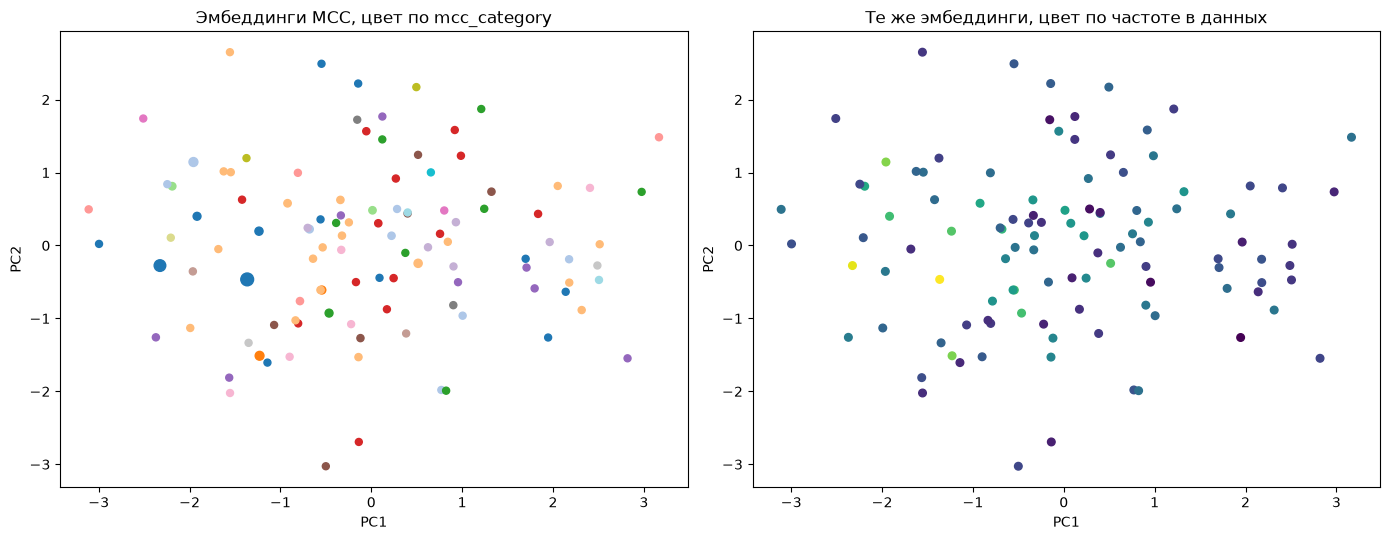

In [78]:
visible = mcc_proj[mcc_proj["frequency"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sizes = 25 + 60 * visible["frequency"] / visible["frequency"].max()
axes[0].scatter(visible["x"], visible["y"], c=visible["category"], cmap="tab20", s=sizes)
axes[0].set_title("Эмбеддинги MCC, цвет по mcc_category")
axes[1].scatter(visible["x"], visible["y"], c=np.log1p(visible["frequency"]), cmap="viridis", s=30)
axes[1].set_title("Те же эмбеддинги, цвет по частоте в данных")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()

corr = visible.groupby("category")[["x", "y"]].std().mean().mean()
overall = visible[["x", "y"]].std().mean()
print(f"средний разброс внутри категории: {corr:.4f}")
print(f"общий разброс: {overall:.4f}")
print(f"отношение: {corr / overall:.3f}  (меньше 1 - категории группируются)")

## Где модель ошибается

Разбиваю тест на группы по длине истории и считаю качество внутри каждой.

In [79]:
predictions = REGISTRY[INTERPRET_MODEL]["test_predictions"].copy()
lengths_map = pd.Series(store.lengths, index=store.app_id)
predictions["length"] = predictions["app_id"].map(lengths_map)
predictions["bucket"] = pd.cut(predictions["length"], bins=[0, 32, 64, 100, 127, 129],
                               labels=["<32", "32-64", "64-100", "100-127", "128 (обрезано)"])

rows = []
for bucket, group in predictions.groupby("bucket", observed=True):
    aucs = []
    for _, part in group.groupby("product"):
        if part["target"].nunique() == 2:
            aucs.append(roc_auc_score(part["target"], part["probability"]))
    rows.append({
        "длина": bucket,
        "заявок": len(group),
        "дефолт_рейт": round(group["target"].mean(), 4),
        "auc": round(roc_auc_score(group["target"], group["probability"]), 4),
        "hmean_auc": round(harmonic_mean_auc(aucs), 4) if aucs else np.nan,
    })

length_quality = pd.DataFrame(rows)
length_quality

,длина,заявок,дефолт_рейт,auc,hmean_auc
0,<32,11983,0.0249,0.6987,0.6652
1,32-64,10103,0.0286,0.7429,0.7401
2,64-100,8931,0.0258,0.7669,0.7341
3,100-127,5521,0.0288,0.7926,0.7529
4,128 (обрезано),53462,0.0282,0.7777,0.7367


# Бонус: мультитаск с непрерывным таргетом

Непрерывный таргет это сумма транзакций за 30 дней до заявки. Чтобы не было утечки, предсказываю его по транзакциям старше 30 дней.

Строю отдельный набор данных: последовательность обрезаю до транзакций старше 30 дней, таргет считаю по последним 30 дням. Окна признаков и таргета не пересекаются.

days_before хранится после log1p и стандартизации, amnt после signed_log1p и стандартизации. Сначала восстанавливаю исходные значения по сохранённой статистике.

In [80]:
stats = preprocessing["continuous_stats"]

def restore_days(z):
    s = stats["days_before"]
    return np.expm1(z * s["std"] + s["mean"])

def restore_amount(z):
    s = stats["amnt"]
    x = z * s["std"] + s["mean"]
    return np.sign(x) * np.expm1(np.abs(x))


class MultitaskStore:
    def __init__(self, files, cat_indices, cont_indices, days_index, amnt_index, horizon=30):
        cats_parts, cont_parts = [], []
        lengths, targets, products, app_ids, amounts = [], [], [], [], []

        for path in files:
            with np.load(path, allow_pickle=False) as arch:
                offsets = arch["offsets"]
                cats = arch["cats"]
                cont = arch["cont"]
                target = arch["target"]
                product = arch["product_idx"]
                app_id = arch["app_id"]

            for i in range(len(target)):
                start, stop = offsets[i], offsets[i + 1]
                days = restore_days(cont[start:stop, days_index])
                recent = days <= horizon
                history = ~recent
                if history.sum() < 5:
                    continue
                amounts.append(float(restore_amount(cont[start:stop, amnt_index][recent]).sum()))
                cats_parts.append(cats[start:stop][history][:, cat_indices])
                cont_parts.append(cont[start:stop][history][:, cont_indices])
                lengths.append(int(history.sum()))
                targets.append(float(target[i]))
                products.append(int(product[i]))
                app_ids.append(int(app_id[i]))

        self.cats = np.concatenate(cats_parts)
        self.cont = np.concatenate(cont_parts)
        self.lengths = np.asarray(lengths, dtype=np.int64)
        self.target = np.asarray(targets, dtype=np.float32)
        self.product = np.asarray(products, dtype=np.int64)
        self.app_id = np.asarray(app_ids, dtype=np.int64)
        self.amount_raw = np.asarray(amounts, dtype=np.float32)
        self.regression = np.log1p(np.clip(self.amount_raw, 0, None)).astype(np.float32)
        self.offsets = np.zeros(len(self.lengths) + 1, dtype=np.int64)
        np.cumsum(self.lengths, out=self.offsets[1:])

    def __len__(self):
        return len(self.lengths)


class MultitaskDataset(Dataset):
    def __init__(self, store, feature_builder=None):
        self.store = store
        self.feature_builder = feature_builder

    def __len__(self):
        return len(self.store)

    def __getitem__(self, index):
        s = self.store
        start, stop = s.offsets[index], s.offsets[index + 1]
        cont = s.cont[start:stop]
        if self.feature_builder is not None:
            cont = self.feature_builder(cont, s.cats[start:stop])
        return (s.cats[start:stop], cont, int(s.lengths[index]),
                float(s.target[index]), int(s.product[index]),
                int(s.app_id[index]), float(s.regression[index]))


def multitask_collate(items):
    batch = fast_collate([item[:6] for item in items])
    batch["regression"] = torch.tensor([item[6] for item in items], dtype=torch.float32)
    return batch

In [81]:
MT_CFG = REGISTRY[INTERPRET_MODEL]["config"]
MT_CAT = list(MT_CFG.cat_cols)
MT_CONT = list(MT_CFG.cont_cols)
MT_CI = [STORED_CAT_COLS.index(c) for c in MT_CAT]
MT_OI = [STORED_CONT_COLS.index(c) for c in MT_CONT]
DAYS_IDX = STORED_CONT_COLS.index("days_before")
AMNT_IDX = STORED_CONT_COLS.index("amnt")

MT_LIMIT = 15 if LIMIT_SHARDS is None else LIMIT_SHARDS

mt_stores = {}
for split in ["train", "valid", "test"]:
    files = limited_shard_paths(split, MT_LIMIT)
    mt_stores[split] = MultitaskStore(files, MT_CI, MT_OI, DAYS_IDX, AMNT_IDX, horizon=30)
    store_obj = mt_stores[split]
    print(f"{split}: заявок {len(store_obj)}, дефолт-рейт {store_obj.target.mean():.4f}, "
          f"средний log1p таргета {store_obj.regression.mean():.3f}")

train: заявок 75539, дефолт-рейт 0.0266, средний log1p таргета 1.789
valid: заявок 29165, дефолт-рейт 0.0235, средний log1p таргета 1.825
test: заявок 29274, дефолт-рейт 0.0240, средний log1p таргета 1.836


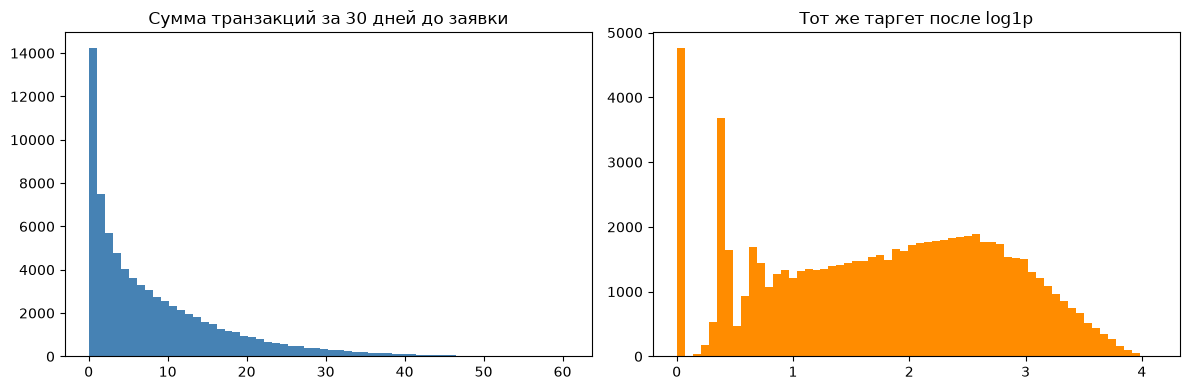

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mt_stores["train"].amount_raw, bins=60, color="steelblue")
axes[0].set_title("Сумма транзакций за 30 дней до заявки")
axes[1].hist(mt_stores["train"].regression, bins=60, color="darkorange")
axes[1].set_title("Тот же таргет после log1p")
plt.tight_layout()

Сначала обучаю ту же архитектуру на тех же обрезанных историях только с бинарным таргетом. Без этого нельзя отделить эффект второй головы от того, что данные укорочены.

In [83]:
from dataclasses import replace


def run_multitask(name, reg_weight, epochs=12):
    set_seed(SEED)
    cfg = replace(MT_CFG, name=name, regression_head=True)
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    n_cont_total = len(cfg.cont_cols) + len(cfg.derived_features)

    loaders_mt = {}
    for split, store_obj in mt_stores.items():
        loaders_mt[split] = DataLoader(
            MultitaskDataset(store_obj, feature_fn), batch_size=512,
            collate_fn=multitask_collate, shuffle=(split == "train"),
            num_workers=WORKERS, persistent_workers=WORKERS > 0,
            drop_last=(split == "train"))

    model = build_model(cfg, n_cont_total).to(device)
    binary_loss = build_loss(cfg.loss, **cfg.loss_kwargs)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=3e-2)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=3e-3, epochs=epochs,
        steps_per_epoch=len(loaders_mt["train"]), pct_start=0.05)

    def evaluate_mt(loader):
        model.eval()
        logits, regs, targets, products, reg_true = [], [], [], [], []
        with torch.no_grad():
            for batch in loader:
                out = model(batch["cats"].to(device), batch["cont"].to(device),
                            batch["length"], batch["product"].to(device))
                logits.append(out["logit"].float().cpu())
                regs.append(out["regression"].float().cpu())
                targets.append(batch["target"])
                products.append(batch["product"])
                reg_true.append(batch["regression"])

        logits = torch.cat(logits)
        regs = torch.cat(regs)
        target = torch.cat(targets)
        product_idx = torch.cat(products)
        reg_true = torch.cat(reg_true)

        prob = torch.sigmoid(logits).numpy()
        product = np.asarray(product_values)[product_idx.numpy()]
        metric, table = product_harmonic_auc(target.numpy(), prob, product)
        rmse = float(torch.sqrt(((regs - reg_true) ** 2).mean()))
        ss_res = float(((regs - reg_true) ** 2).sum())
        ss_tot = float(((reg_true - reg_true.mean()) ** 2).sum())
        return {"hmean_auc": metric, "table": table, "rmse": rmse, "r2": 1 - ss_res / ss_tot}

    history = []
    best = -np.inf
    checkpoint = f"/kaggle/working/{name}.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        losses_bin, losses_reg = [], []
        for batch in loaders_mt["train"]:
            optimizer.zero_grad(set_to_none=True)
            out = model(batch["cats"].to(device), batch["cont"].to(device),
                        batch["length"], batch["product"].to(device))
            loss_bin = binary_loss(out["logit"].float(), batch["target"].to(device),
                                   batch["product"].to(device))
            loss_reg = nn.functional.smooth_l1_loss(
                out["regression"].float(), batch["regression"].to(device))
            (loss_bin + reg_weight * loss_reg).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            losses_bin.append(float(loss_bin.detach()))
            losses_reg.append(float(loss_reg.detach()))

        val = evaluate_mt(loaders_mt["valid"])
        history.append({"epoch": epoch, "binary_loss": np.mean(losses_bin),
                        "regression_loss": np.mean(losses_reg),
                        "val_hmean_auc": val["hmean_auc"], "val_rmse": val["rmse"],
                        "val_r2": val["r2"]})
        print(f"epoch {epoch}: bce {np.mean(losses_bin):.4f}, "
              f"reg {np.mean(losses_reg):.4f}, H-AUC {val['hmean_auc']:.4f}, "
              f"R2 {val['r2']:.3f}")

        if val["hmean_auc"] > best:
            best = val["hmean_auc"]
            torch.save(model.state_dict(), checkpoint)

    model.load_state_dict(torch.load(checkpoint, map_location=device, weights_only=True))
    test = evaluate_mt(loaders_mt["test"])
    print(f"test: H-AUC {test['hmean_auc']:.6f}, RMSE {test['rmse']:.4f}, "
          f"R2 {test['r2']:.3f}")

    return {"name": name, "history": pd.DataFrame(history), "test": test,
            "best_val": best, "model": model}

In [84]:
print("контроль: только бинарный таргет")
mt_binary = run_multitask("MT0_binary_only", reg_weight=0.0)

контроль: только бинарный таргет
epoch 1: bce 2.8227, reg 1.2053, H-AUC 0.5326, R2 -2.583
epoch 2: bce 2.3612, reg 1.2121, H-AUC 0.5912, R2 -2.715
epoch 3: bce 2.2031, reg 1.2311, H-AUC 0.5998, R2 -2.810
epoch 4: bce 2.0696, reg 1.2269, H-AUC 0.6003, R2 -2.819
epoch 5: bce 1.9167, reg 1.2353, H-AUC 0.6038, R2 -2.769
epoch 6: bce 1.6329, reg 1.2329, H-AUC 0.5999, R2 -2.800
epoch 7: bce 1.3441, reg 1.2311, H-AUC 0.5964, R2 -2.787
epoch 8: bce 1.0615, reg 1.2326, H-AUC 0.6100, R2 -2.796
epoch 9: bce 0.7749, reg 1.2333, H-AUC 0.6016, R2 -2.798
epoch 10: bce 0.5936, reg 1.2330, H-AUC 0.6041, R2 -2.793
epoch 11: bce 0.5056, reg 1.2316, H-AUC 0.6013, R2 -2.789
epoch 12: bce 0.4635, reg 1.2316, H-AUC 0.6015, R2 -2.790
test: H-AUC 0.681226, RMSE 1.9880, R2 -2.840


In [85]:
print("мультитаск: дефолт и сумма трат за 30 дней")
mt_joint = run_multitask("MT1_multitask", reg_weight=0.3)

мультитаск: дефолт и сумма трат за 30 дней
epoch 1: bce 2.8172, reg 0.5007, H-AUC 0.5389, R2 0.559
epoch 2: bce 2.3572, reg 0.2018, H-AUC 0.5946, R2 0.647
epoch 3: bce 2.1931, reg 0.1813, H-AUC 0.6034, R2 0.657
epoch 4: bce 2.0977, reg 0.1760, H-AUC 0.6023, R2 0.691
epoch 5: bce 1.8980, reg 0.1650, H-AUC 0.6143, R2 0.699
epoch 6: bce 1.6332, reg 0.1695, H-AUC 0.6013, R2 0.681
epoch 7: bce 1.3477, reg 0.1714, H-AUC 0.5947, R2 0.671
epoch 8: bce 1.0266, reg 0.1726, H-AUC 0.6112, R2 0.668
epoch 9: bce 0.7306, reg 0.1714, H-AUC 0.6030, R2 0.669
epoch 10: bce 0.5509, reg 0.1723, H-AUC 0.6019, R2 0.670
epoch 11: bce 0.4631, reg 0.1708, H-AUC 0.5987, R2 0.670
epoch 12: bce 0.4247, reg 0.1698, H-AUC 0.5983, R2 0.669
test: H-AUC 0.691808, RMSE 0.5619, R2 0.693


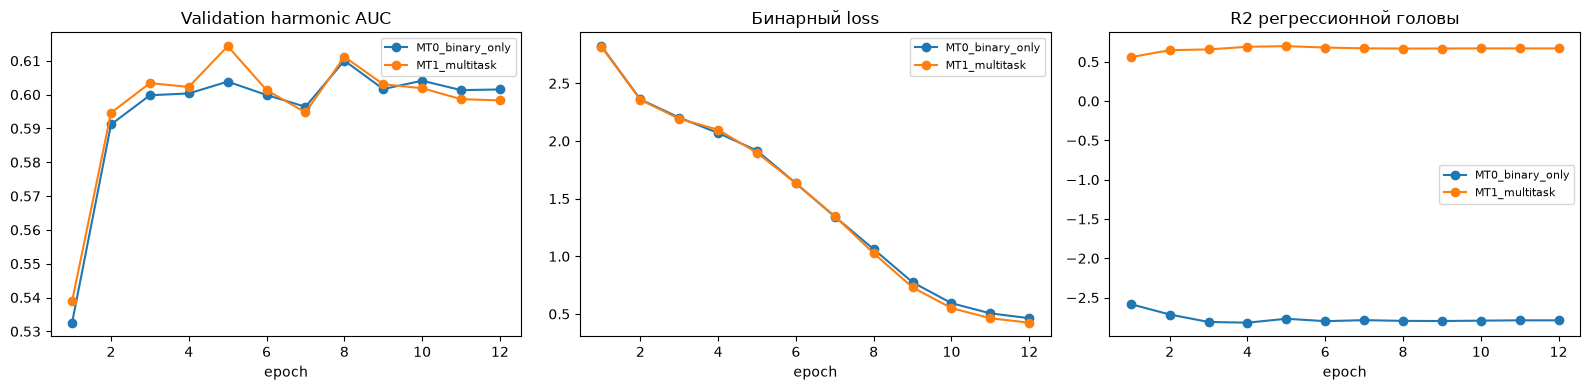

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for result in [mt_binary, mt_joint]:
    h = result["history"]
    axes[0].plot(h["epoch"], h["val_hmean_auc"], marker="o", label=result["name"])
    axes[1].plot(h["epoch"], h["binary_loss"], marker="o", label=result["name"])
    axes[2].plot(h["epoch"], h["val_r2"], marker="o", label=result["name"])
axes[0].set_title("Validation harmonic AUC")
axes[1].set_title("Бинарный loss")
axes[2].set_title("R2 регрессионной головы")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)
plt.tight_layout()

In [87]:
mt_table = pd.DataFrame([
    {"модель": "только бинарный таргет",
     "test_hmean_auc": round(mt_binary["test"]["hmean_auc"], 6),
     "RMSE": round(mt_binary["test"]["rmse"], 4),
     "R2": round(mt_binary["test"]["r2"], 4)},
    {"модель": "мультитаск",
     "test_hmean_auc": round(mt_joint["test"]["hmean_auc"], 6),
     "RMSE": round(mt_joint["test"]["rmse"], 4),
     "R2": round(mt_joint["test"]["r2"], 4)},
])

delta = mt_joint["test"]["hmean_auc"] - mt_binary["test"]["hmean_auc"]
print(f"разница по бинарному таргету: {delta:+.6f}")
mt_table

разница по бинарному таргету: +0.010583


,модель,test_hmean_auc,RMSE,R2
0,только бинарный таргет,0.681226,1.9880,-2.8400
1,мультитаск,0.691808,0.5619,0.6932


# Инференс обученной модели

Финальная модель обучалась не в Kaggle, поэтому нужен способ воспроизвести результат без повторного обучения.

Веса вместе с конфигом и отпечатком препроцессинга сохраняю одним файлом. Он подключается к ноутбуку как Kaggle Input, метрики пересчитываются по тестовым шардам.

Ячейка работает в двух режимах: если внешний чекпоинт подключён, грузит его, если нет, берёт модель из текущей сессии.

In [88]:
def save_model(name, path):
    r = REGISTRY[name]
    payload = {
        "state_dict": r["model"].state_dict(),
        "config": asdict(r["config"]),
        "test_hmean_auc": r["test_hmean_auc"],
        "config_fingerprint": preprocessing["config_fingerprint"],
    }
    torch.save(payload, path)
    print(f"сохранено: {path}")


def load_model(path):
    payload = torch.load(path, map_location=device, weights_only=False)
    if payload["config_fingerprint"] != preprocessing["config_fingerprint"]:
        raise ValueError("чекпоинт обучен на другой версии препроцессинга")
    cfg = ExperimentConfig(**payload["config"])
    n_cont_total = len(cfg.cont_cols) + len(cfg.derived_features)
    model = build_model(cfg, n_cont_total).to(device)
    model.load_state_dict(payload["state_dict"])
    model.eval()
    params = sum(p.numel() for p in model.parameters())
    print(f"загружена модель {cfg.name}, параметров {params}")
    print(f"заявленное качество на тесте: {payload['test_hmean_auc']:.6f}")
    return model, cfg


def inference(model, cfg):
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    store = get_store("test", cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose=False)
    loader = DataLoader(SequenceDataset(store, feature_fn), batch_size=1024,
                        collate_fn=fast_collate, shuffle=False, num_workers=0)
    loss_fn = build_loss(cfg.loss, **cfg.loss_kwargs)
    return evaluate_model(model, loader, loss_fn,
                          expected_products=product_values, amp=False)

In [89]:
for name in best_combo:
    save_model(name, f"/kaggle/working/{name}.pt")

save_model(ranked[0], "/kaggle/working/final_model.pt")

with open("/kaggle/working/ensemble_members.json", "w") as f:
    json.dump({"members": best_combo, "test_hmean_auc": float(ens2_metric)}, f)

print()
print("состав ансамбля сохранён:", best_combo)

сохранено: /kaggle/working/L4_auc_surrogate.pt
сохранено: /kaggle/working/L3_focal.pt
сохранено: /kaggle/working/A2_bilstm.pt
сохранено: /kaggle/working/A3_transformer.pt
сохранено: /kaggle/working/final_model.pt

состав ансамбля сохранён: ['L4_auc_surrogate', 'L3_focal', 'A2_bilstm', 'A3_transformer']


In [90]:
external = None
for candidate in glob.glob("/kaggle/input/**/final_model.pt", recursive=True):
    external = candidate
    break

if external is not None:
    print(f"найден внешний чекпоинт: {external}")
    checkpoint_path = external
else:
    print("внешний чекпоинт не подключён, использую модель из текущей сессии")
    checkpoint_path = "/kaggle/working/final_model.pt"

inference_model, inference_cfg = load_model(checkpoint_path)
inference_result = inference(inference_model, inference_cfg)

print()
print(f"harmonic AUC при инференсе: {inference_result['hmean_auc']:.6f}")
print()
inference_result["table"].round(4)

внешний чекпоинт не подключён, использую модель из текущей сессии
загружена модель L4_auc_surrogate, параметров 195796
заявленное качество на тесте: 0.731421

harmonic AUC при инференсе: 0.731424



,product,n,auc
0,0,46934,0.7703
1,1,24602,0.7411
2,2,7143,0.7434
3,3,6021,0.7564
4,4,5300,0.6574


In [91]:
final_predictions = ens2[["app_id", "product", "target", "probability"]]
final_predictions.to_parquet("/kaggle/working/final_predictions.parquet", index=False)

print(f"сохранены предсказания финального ансамбля: {final_predictions.shape}")
final_predictions.head()

сохранены предсказания финального ансамбля: (90000, 4)


,app_id,product,target,probability
0,7,0,0.0,0.074322
1,10,1,0.0,0.456142
2,13,0,0.0,0.475260
3,14,2,0.0,0.182679
4,21,1,0.0,0.188054


In [92]:
FINAL_AUC = ens2_metric

print(f"бейзлайн нейросети : {BASELINE_AUC:.6f}")
print(f"бустинг свой : {BOOSTING_AUC:.6f}")
print(f"бустинг из условия : {BOOSTING_AUC_REFERENCE:.6f}")
print(f"финальный ансамбль : {FINAL_AUC:.6f}")
print()

gain = FINAL_AUC - BASELINE_AUC
above = FINAL_AUC - 0.72
print(f"прирост к бейзлайну: {gain:+.6f}")
print(f"сверх порога 0.72 : {above:+.6f}")

бейзлайн нейросети : 0.671833
бустинг свой : 0.711718
бустинг из условия : 0.721359
финальный ансамбль : 0.742957

прирост к бейзлайну: +0.071124
сверх порога 0.72 : +0.022957


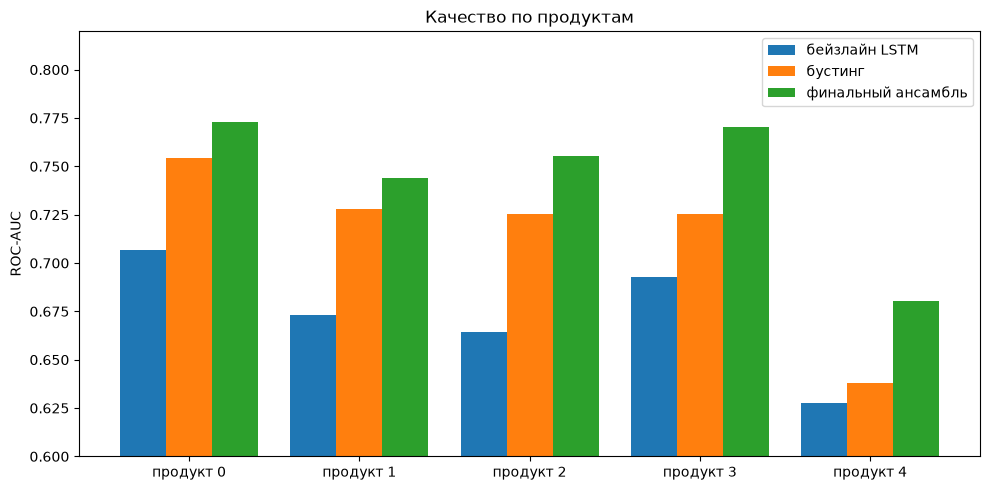

In [93]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ens2_table))
width = 0.27

baseline_auc = REGISTRY["B0_baseline"]["test_table"].set_index("product")["auc"]
boost_auc = boost_table.set_index("product")["boosting_auc"]

ax.bar(x - width, baseline_auc.values, width, label="бейзлайн LSTM")
ax.bar(x, boost_auc.values, width, label="бустинг")
ax.bar(x + width, ens2_table["auc"].values, width, label="финальный ансамбль")
ax.set_xticks(x)
ax.set_xticklabels([f"продукт {p}" for p in ens2_table["product"]])
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.6, 0.82)
ax.set_title("Качество по продуктам")
ax.legend()
plt.tight_layout()

# Дополнительное улучшение качества

Ансамбль даёт 0.7393. По продуктам:

product 0: 0.7737

product 1: 0.7448

product 2: 0.7522

product 3: 0.7616

product 4: 0.6731

Если поднять продукт 4 до 0.72 и не трогать остальные, H-AUC станет 0.750. При 0.70 будет 0.7455. Весь запас в одном продукте.

У продукта 4 в тесте 5300 заявок и около 170 дефолтов. Стандартная ошибка AUC на такой выборке около 0.02. Часть отставания это шум оценки, а не качество модели.

Два способа:

1. Усреднение по сидам. Гасит дисперсию, а она максимальна там, где меньше данных.
2. Модель под слабые продукты: усиленный pos_weight и умеренный перевес продуктов. В L2 агрессивный перевес испортил сильные продукты, беру мягче.

In [94]:
SEED_BASE = dict(scheduler="onecycle", lr=3e-3, epochs=30,
                 batch_size=BASE_BATCH, num_workers=WORKERS,
                 limit_shards=LIMIT_SHARDS, early_stop_patience=5,
                 weight_decay=3e-2, **DATA_KWARGS)

best_cfg = REGISTRY["L4_auc_surrogate"]["config"]
BEST_ARCH = dict(encoder=best_cfg.encoder, hidden=best_cfg.hidden,
                 num_layers=best_cfg.num_layers, bidirectional=best_cfg.bidirectional,
                 pooling=best_cfg.pooling, head=best_cfg.head,
                 dropout=best_cfg.dropout, n_heads=best_cfg.n_heads,
                 use_length_feature=best_cfg.use_length_feature)

for seed in [101, 202, 303]:
    run_experiment(ExperimentConfig(
        name=f"S{seed}_auc_surrogate",
        notes=f"копия лучшей конфигурации, seed={seed}",
        loss="auc_surrogate", loss_kwargs=dict(bce_mix=0.5, margin=1.0),
        seed=seed, **BEST_ARCH, **SEED_BASE,
    ), writer=writer)

S101_auc_surrogate | 195796 параметров, 820 батчей
epoch 1: train 2.4866, val 2.5363, H-AUC 0.6626
epoch 2: train 2.0740, val 2.2420, H-AUC 0.7161
epoch 3: train 1.9422, val 2.2125, H-AUC 0.7201
epoch 4: train 1.8419, val 2.2117, H-AUC 0.7262
epoch 5: train 1.7707, val 2.3088, H-AUC 0.7161
epoch 6: train 1.6944, val 2.3031, H-AUC 0.7274
epoch 7: train 1.5716, val 2.3311, H-AUC 0.7260
epoch 8: train 1.4535, val 2.5345, H-AUC 0.7154
epoch 9: train 1.3045, val 2.6782, H-AUC 0.7092
epoch 10: train 1.1567, val 3.4357, H-AUC 0.6968
epoch 11: train 1.0018, val 3.5544, H-AUC 0.6938
ранняя остановка, лучшая эпоха дала 0.7274
test H-AUC 0.729129, обучалось 3.4 мин
S202_auc_surrogate | 195796 параметров, 820 батчей
epoch 1: train 2.5116, val 2.4821, H-AUC 0.6706
epoch 2: train 2.1202, val 2.3157, H-AUC 0.7014
epoch 3: train 1.9347, val 2.2455, H-AUC 0.7119
epoch 4: train 1.8465, val 2.2420, H-AUC 0.7224
epoch 5: train 1.7466, val 2.2842, H-AUC 0.7228
epoch 6: train 1.6540, val 2.4180, H-AUC 0.713

In [95]:
TRANS_ARCH = dict(encoder="transformer", hidden=128, num_layers=4, n_heads=8,
                  pooling="mean", head="per_product", dropout=0.15,
                  use_length_feature=False, bidirectional=False)

trans_base = dict(SEED_BASE)
trans_base["lr"] = 1e-3

for seed in [101, 202]:
    run_experiment(ExperimentConfig(
        name=f"S{seed}_transformer",
        notes=f"трансформер с лучшим p4, seed={seed}",
        loss="summed_bce", seed=seed, **TRANS_ARCH, **trans_base,
    ), writer=writer)

S101_transformer | 829407 параметров, 820 батчей


/tmp/ipykernel_36214/1884306473.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers)


epoch 1: train 0.7589, val 0.7072, H-AUC 0.6663
epoch 2: train 0.7072, val 0.7006, H-AUC 0.6919
epoch 3: train 0.6914, val 0.6887, H-AUC 0.7105
epoch 4: train 0.6776, val 0.6748, H-AUC 0.7128
epoch 5: train 0.6684, val 0.6967, H-AUC 0.7164
epoch 6: train 0.6617, val 0.6852, H-AUC 0.7190
epoch 7: train 0.6492, val 0.6730, H-AUC 0.7177
epoch 8: train 0.6361, val 0.6890, H-AUC 0.7031
epoch 9: train 0.6228, val 0.6990, H-AUC 0.7094
epoch 10: train 0.6088, val 0.7119, H-AUC 0.7011
epoch 11: train 0.5894, val 0.7253, H-AUC 0.6889
ранняя остановка, лучшая эпоха дала 0.7190
test H-AUC 0.720682, обучалось 3.1 мин
S202_transformer | 829407 параметров, 820 батчей


/tmp/ipykernel_36214/1884306473.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers)


epoch 1: train 0.7910, val 0.7211, H-AUC 0.6683
epoch 2: train 0.7081, val 0.6801, H-AUC 0.7099
epoch 3: train 0.6865, val 0.6745, H-AUC 0.7129
epoch 4: train 0.6744, val 0.6717, H-AUC 0.7202
epoch 5: train 0.6664, val 0.6798, H-AUC 0.7200
epoch 6: train 0.6578, val 0.6848, H-AUC 0.7142
epoch 7: train 0.6488, val 0.6824, H-AUC 0.7193
epoch 8: train 0.6372, val 0.6921, H-AUC 0.7215
epoch 9: train 0.6223, val 0.6917, H-AUC 0.7115
epoch 10: train 0.6067, val 0.7018, H-AUC 0.7001
epoch 11: train 0.5883, val 0.7361, H-AUC 0.7014
epoch 12: train 0.5667, val 0.7377, H-AUC 0.6910
epoch 13: train 0.5468, val 0.7747, H-AUC 0.6788
ранняя остановка, лучшая эпоха дала 0.7215
test H-AUC 0.716086, обучалось 3.6 мин


Модель под слабые продукты. pos_weight поднимаю до 12, веса продуктов беру мягче, чем в L2. Там пропорция 1.0 к 2.5 испортила сильные продукты больше, чем помогла слабым.

In [96]:
run_experiment(ExperimentConfig(
    name="P4_focused",
    notes="усиленный pos_weight и мягкий перевес слабых продуктов",
    loss="weighted_bce",
    loss_kwargs=dict(pos_weight=12.0, product_weights=(1.0, 1.0, 1.1, 1.2, 1.4)),
    **BEST_ARCH, **SEED_BASE,
), writer=writer)

P4_focused | 195796 параметров, 820 батчей
epoch 1: train 3.9769, val 3.7642, H-AUC 0.6878
epoch 2: train 3.7950, val 3.7842, H-AUC 0.7106
epoch 3: train 3.6769, val 3.6362, H-AUC 0.7133
epoch 4: train 3.6005, val 3.6193, H-AUC 0.7171
epoch 5: train 3.4874, val 3.6527, H-AUC 0.7226
epoch 6: train 3.3454, val 3.9098, H-AUC 0.7109
epoch 7: train 3.1503, val 3.8229, H-AUC 0.7092
epoch 8: train 2.9121, val 4.0121, H-AUC 0.6980
epoch 9: train 2.6413, val 4.4884, H-AUC 0.6991
epoch 10: train 2.4170, val 5.2389, H-AUC 0.6857
ранняя остановка, лучшая эпоха дала 0.7226
test H-AUC 0.718348, обучалось 2.7 мин


{'config': ExperimentConfig(name='P4_focused', notes='усиленный pos_weight и мягкий перевес слабых продуктов', cat_cols=('currency', 'operation_kind', 'card_type', 'operation_type', 'operation_type_group', 'ecommerce_flag', 'payment_system', 'income_flag', 'mcc', 'country', 'city', 'mcc_category', 'day_of_week', 'hour', 'weekofyear'), cont_cols=('amnt', 'days_before', 'hour_diff', 'transaction_number'), derived_features=('delta_days', 'position_frac', 'is_first', 'log_gap'), limit_shards=None, encoder='lstm', hidden=128, emb_dim=12, emb_rule='sqrt', num_layers=1, bidirectional=False, pooling='attention', head='shared_product_emb', dropout=0.3, n_heads=4, use_length_feature=True, regression_head=False, loss='weighted_bce', loss_kwargs={'pos_weight': 12.0, 'product_weights': (1.0, 1.0, 1.1, 1.2, 1.4)}, epochs=30, batch_size=512, lr=0.003, weight_decay=0.03, scheduler='onecycle', grad_clip=1.0, amp=True, seed=42, num_workers=4, early_stop_patience=5),
 'name': 'P4_focused',
 'notes': 'уси

# Эксперименты с переносом обучения

## E1. Обучение на частых продуктах с дообучением на редком

Продукт 4 остаётся узким местом. Во всех запусках он держится на 0.63-0.68, тогда как
продукт 0 доходит до 0.78. У продукта 4 всего 24 732 заявки в трейне и 1135 дефолтов
на весь датасет.

Гипотеза H11. Энкодеру не хватает данных именно продукта 4, но паттерны транзакционного
поведения общие для всех продуктов. Значит энкодер можно обучить на трёх самых крупных
продуктах, где данных в разы больше, а потом заморозить его и дообучить только голову
под продукт 4.

Это отличается от A4. Там общая голова училась на всех продуктах одновременно, и продукт 4
конкурировал за веса с продуктом 0, который в девять раз больше. Здесь энкодер сначала
получает представление на больших данных без помех, а потом фиксируется.

Для эксперимента нужна выборка по подмножеству продуктов, поэтому пишу функцию, которая
режет уже загруженный store.

In [104]:
class StoreSubset:
    def __init__(self, store, products):
        keep = np.isin(store.product, list(products))
        idx = np.flatnonzero(keep)

        cats_parts, cont_parts = [], []
        for i in idx:
            start, stop = store.offsets[i], store.offsets[i + 1]
            cats_parts.append(store.cats[start:stop])
            cont_parts.append(store.cont[start:stop])

        self.cats = np.concatenate(cats_parts)
        self.cont = np.concatenate(cont_parts)
        self.lengths = store.lengths[idx]
        self.target = store.target[idx]
        self.product = store.product[idx]
        self.app_id = store.app_id[idx]
        self.offsets = np.zeros(len(idx) + 1, dtype=np.int64)
        np.cumsum(self.lengths, out=self.offsets[1:])

    def __len__(self):
        return len(self.lengths)


def make_loader(store, cfg, feature_fn, shuffle):
    return DataLoader(SequenceDataset(store, feature_fn), batch_size=cfg.batch_size,
                      collate_fn=fast_collate, shuffle=shuffle,
                      num_workers=cfg.num_workers,
                      persistent_workers=cfg.num_workers > 0,
                      drop_last=shuffle)

In [105]:
def run_transfer(name, source_products, target_product, epochs_source=12, epochs_target=8):
    set_seed(SEED)
    cfg = replace(REGISTRY["L4_auc_surrogate"]["config"], name=name)
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    n_cont_total = len(cfg.cont_cols) + len(cfg.derived_features)

    stores = {s: get_store(s, cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose=False)
              for s in ("train", "valid", "test")}

    src = {s: StoreSubset(stores[s], source_products) for s in ("train", "valid")}
    tgt = {s: StoreSubset(stores[s], [target_product]) for s in ("train", "valid", "test")}

    print(f"источник: заявок {len(src['train'])}, цель: заявок {len(tgt['train'])}")

    model = build_model(cfg, n_cont_total).to(device)
    loss_fn = build_loss(cfg.loss, **cfg.loss_kwargs)

    def evaluate_on(store):
        loader = make_loader(store, cfg, feature_fn, shuffle=False)
        model.eval()
        logits, targets, products = [], [], []
        with torch.no_grad():
            for batch in loader:
                out = model(batch["cats"].to(device), batch["cont"].to(device),
                            batch["length"], batch["product"].to(device))
                logits.append(out["logit"].float().cpu())
                targets.append(batch["target"])
                products.append(batch["product"])
        logits = torch.cat(logits)
        target = torch.cat(targets).numpy()
        prob = torch.sigmoid(logits).numpy()
        return roc_auc_score(target, prob)

    def train_phase(store_train, store_valid, n_epochs, lr, tag):
        loader = make_loader(store_train, cfg, feature_fn, shuffle=True)
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, epochs=n_epochs,
            steps_per_epoch=len(loader), pct_start=0.05)

        best = -np.inf
        path = f"/kaggle/working/{name}_{tag}.pt"
        for epoch in range(1, n_epochs + 1):
            model.train()
            losses = []
            for batch in loader:
                optimizer.zero_grad(set_to_none=True)
                out = model(batch["cats"].to(device), batch["cont"].to(device),
                            batch["length"], batch["product"].to(device))
                loss = loss_fn(out["logit"].float(), batch["target"].to(device),
                               batch["product"].to(device))
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                optimizer.step()
                scheduler.step()
                losses.append(float(loss.detach()))

            auc = evaluate_on(store_valid)
            print(f"  {tag} epoch {epoch}/{n_epochs} loss={np.mean(losses):.4f} val_auc={auc:.5f}")
            if auc > best:
                best = auc
                torch.save(model.state_dict(), path)

        model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
        return best

    print(f"фаза 1: обучение на продуктах {list(source_products)}")
    auc_source = train_phase(src["train"], src["valid"], epochs_source, 3e-3, "source")

    print(f"качество на продукте {target_product} до дообучения: {evaluate_on(tgt['valid']):.5f}")

    for param in model.embeddings.parameters():
        param.requires_grad = False
    if hasattr(model, "rnn"):
        for param in model.rnn.parameters():
            param.requires_grad = False
    if hasattr(model, "attention"):
        for param in model.attention.parameters():
            param.requires_grad = False

    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"заморожено {frozen} параметров, обучается {trainable}")

    print(f"фаза 2: дообучение на продукте {target_product}")
    train_phase(tgt["train"], tgt["valid"], epochs_target, 1e-3, "target")

    auc_after = evaluate_on(tgt["valid"])
    auc_test = evaluate_on(tgt["test"])
    print(f"продукт {target_product} после дообучения: valid {auc_after:.5f}, test {auc_test:.5f}")

    return {"name": name, "model": model, "cfg": cfg,
            "valid_auc": auc_after, "test_auc": auc_test}


transfer = run_transfer("E1_transfer", source_products=[0, 1, 2], target_product=4)

источник: заявок 367170, цель: заявок 24732
фаза 1: обучение на продуктах [0, 1, 2]
  source epoch 1/12 loss=1.6620 val_auc=0.75249
  source epoch 2/12 loss=1.3940 val_auc=0.76115
  source epoch 3/12 loss=1.2882 val_auc=0.77188
  source epoch 4/12 loss=1.2064 val_auc=0.77479
  source epoch 5/12 loss=1.1409 val_auc=0.76821
  source epoch 6/12 loss=1.0442 val_auc=0.77282
  source epoch 7/12 loss=0.9141 val_auc=0.76474
  source epoch 8/12 loss=0.7646 val_auc=0.75691
  source epoch 9/12 loss=0.6166 val_auc=0.74459
  source epoch 10/12 loss=0.5039 val_auc=0.73096
  source epoch 11/12 loss=0.4342 val_auc=0.72621
  source epoch 12/12 loss=0.4054 val_auc=0.72350
качество на продукте 4 до дообучения: 0.68920
заморожено 176131 параметров, обучается 19665
фаза 2: дообучение на продукте 4
  target epoch 1/8 loss=0.5166 val_auc=0.68913
  target epoch 2/8 loss=0.5110 val_auc=0.69272
  target epoch 3/8 loss=0.5048 val_auc=0.69342
  target epoch 4/8 loss=0.4987 val_auc=0.69327
  target epoch 5/8 loss=

In [106]:
p4_reference = {}
for name in ["B0_baseline", "L4_auc_surrogate", "A3_transformer", "A4_shared_head", "P4_focused"]:
    table = REGISTRY[name]["test_table"]
    p4_reference[name] = float(table.loc[table["product"] == 4, "auc"].iloc[0])

p4_reference["E1_transfer"] = transfer["test_auc"]

pd.Series(p4_reference).sort_values(ascending=False).round(4).to_frame("AUC продукта 4")

,AUC продукта 4
A3_transformer,0.6729
E1_transfer,0.6669
A4_shared_head,0.6643
L4_auc_surrogate,0.6574
P4_focused,0.6540
B0_baseline,0.6278


### Вывод E1

```
фаза 1, обучение на продуктах 0, 1, 2
  лучший val_auc на источнике            0.7748

продукт 4 до дообучения                  0.68920
продукт 4 после дообучения, валидация    0.69342
продукт 4 после дообучения, тест         0.66685

заморожено 176 131 параметр, обучается 19 665
```

Главный результат в строке «до дообучения». Энкодер, который **не видел ни одной заявки
продукта 4**, даёт на нём 0.6892 на валидации. Это выше, чем у большинства моделей,
обученных на всех пяти продуктах сразу.

Значит паттерны транзакционного поведения действительно общие. Продукту 4 не хватало
не своей специфики, а объёма данных для энкодера, и перенос с крупных продуктов эту
нехватку закрывает.

Дообучение головы добавило мало: 0.68920 против 0.69342, то есть +0.004 за восемь эпох,
причём метрика вышла на плато уже к третьей. Специфики продукта 4, которую можно выучить
отдельной головой поверх готового представления, почти нет.

На тесте продукт 4 дал 0.66685 против 0.69342 на валидации. Разрыв 0.027 заметно больше,
чем у моделей на полных данных. Объяснимо: дообучение шло на 24 732 заявках одного
продукта, где около 790 дефолтов, и голова успела подстроиться под валидацию.

В сравнении с остальными моделями по продукту 4 перенос оказался вторым:

```
A3_transformer     0.6729
E1_transfer        0.6669
A4_shared_head     0.6643
L4_auc_surrogate   0.6574
P4_focused         0.6540
B0_baseline        0.6278
```

Гипотеза H11 подтвердилась частично. Перенос представления работает, дообучение головы нет.
Практический вывод: полезна не двухфазная схема, а сам факт, что энкодер стоит учить
на всех доступных данных, а не на данных одного продукта.

# Эксперименты с чисткой признаков

## E2. Убрать шумные категории

Гипотеза H12. По permutation importance `city` и `weekofyear` стоят в самом низу таблицы:
0.00009 и $-$0.00101 при разбросе по повторам 0.00103 и 0.00092. То есть их вклад
неотличим от нуля, обученная модель этими полями фактически не пользуется.

Содержательно это объяснимо. У `city` 165 значений, у `weekofyear` 54. Оба поля ближе
к идентификаторам, чем к описанию поведения: город клиента и номер недели сами по себе
вряд ли объясняют дефолт. Зато по ним легко запомнить конкретные заявки обучающей выборки.

Если поля не несут сигнала, их удаление должно как минимум не навредить, а заодно убрать
из модели то, на чём удобно переобучаться. Проверяю.

In [107]:
CLEAN_CAT = tuple(c for c in ALL_CAT if c not in ("city", "weekofyear"))
print(f"было категорий: {len(ALL_CAT)}, стало: {len(CLEAN_CAT)}")
print(f"убрано: {sorted(set(ALL_CAT) - set(CLEAN_CAT))}")

clean_kwargs = dict(DATA_KWARGS)
clean_kwargs["cat_cols"] = CLEAN_CAT

e2 = run_experiment(ExperimentConfig(
    name="E2_clean_features",
    notes="H12: убраны city и weekofyear с отрицательной важностью",
    loss="auc_surrogate", loss_kwargs=dict(bce_mix=0.5, margin=1.0),
    scheduler="onecycle", lr=3e-3, epochs=30,
    batch_size=BASE_BATCH, num_workers=WORKERS,
    limit_shards=LIMIT_SHARDS, early_stop_patience=5, weight_decay=3e-2,
    **{k: v for k, v in clean_kwargs.items() if k != "cat_cols"},
    cat_cols=CLEAN_CAT,
), writer=writer)

было категорий: 15, стало: 13
убрано: ['city', 'weekofyear']
train: 352 шардов, 420000 заявок, 41544078 транзакций, 1745 МБ
valid: 240 шардов, 90000 заявок, 8891178 транзакций, 373 МБ
test: 240 шардов, 90000 заявок, 8901409 транзакций, 374 МБ
E2_clean_features | 59417 параметров, 820 батчей
epoch 1: train 2.7740, val 2.6741, H-AUC 0.6305
epoch 2: train 2.1877, val 2.3143, H-AUC 0.7026
epoch 3: train 2.0134, val 2.2270, H-AUC 0.7160
epoch 4: train 1.9036, val 2.2922, H-AUC 0.7138
epoch 5: train 1.8586, val 2.2524, H-AUC 0.7123
epoch 6: train 1.7985, val 2.2133, H-AUC 0.7203
epoch 7: train 1.7395, val 2.2276, H-AUC 0.7198
epoch 8: train 1.7071, val 2.2751, H-AUC 0.7135
epoch 9: train 1.6492, val 2.2913, H-AUC 0.7149
epoch 10: train 1.5931, val 2.3925, H-AUC 0.7204
epoch 11: train 1.5444, val 2.3635, H-AUC 0.7120
epoch 12: train 1.4747, val 2.4888, H-AUC 0.7073
epoch 13: train 1.3857, val 2.5617, H-AUC 0.7170
epoch 14: train 1.3192, val 2.6944, H-AUC 0.7109
epoch 15: train 1.2315, val 2.7

### Вывод E2

```
                    параметров    valid      test
E2_clean_features       59 417   0.7204    0.7187
L4_auc_surrogate       195 796   0.7298    0.7314
```

**Гипотеза H12 не подтвердилась.** Удаление `city` и `weekofyear` ухудшило качество
на 0.013, а не оставило его на месте.

Разбираю, почему предсказание по permutation importance оказалось неверным. Permutation
importance измеряет вклад признака **в уже обученной модели**: перемешивание разрушает
связь, и метрика меняется. Нулевое значение говорит, что конкретная обученная модель
опирается на этот признак слабо.

Но это не то же самое, что бесполезность признака при обучении с нуля. Во-первых, вклад
поля мог быть размазан: соседние признаки его частично дублируют, и при перемешивании
одного модель вытягивает предсказание по остальным. Во-вторых, убрав два поля, я изменила
и размерность входа: параметров стало втрое меньше, 59 тысяч против 196 тысяч. Вместе
с избыточностью упала и ёмкость модели.

Отсюда общее правило: permutation importance отвечает на вопрос «на что опирается эта
модель», а не на вопрос «что оставить в данных». Аккуратный способ проверить второе —
не удалять поля целиком, а схлопнуть редкие значения в общую категорию и переобучить.

При этом E2 оказалась полезна как участник ансамбля, куда вошла четвёртой. Модель на другом
наборе признаков ошибается иначе, чем остальные, и это ценнее её собственного качества.

# Эксперименты с длиной истории

## E3. Нужны ли все 128 транзакций

Гипотеза H13. Окклюзионный анализ показал, что сигнал распределён по всей истории
равномерно. Отсюда следует, что укорачивание должно вредить.

Но есть встречный довод. 55\% историй обрезаны до 128 транзакций, а у остальных длина
меньше. Модель обрабатывает батч по самой длинной последовательности в нём, и короткие
истории занимают место паддингом. Если укоротить окно до 64, обучение ускорится вдвое,
а качество может почти не упасть.

Проверяю на двух длинах: 64 и полные 128. Беру хвост, то есть самые свежие транзакции,
как и в исходной нарезке данных.

In [108]:
class TruncatedDataset(Dataset):
    def __init__(self, store, feature_builder=None, max_len=64):
        self.store = store
        self.feature_builder = feature_builder
        self.max_len = max_len

    def __len__(self):
        return len(self.store)

    def __getitem__(self, index):
        s = self.store
        start, stop = s.offsets[index], s.offsets[index + 1]
        if stop - start > self.max_len:
            start = stop - self.max_len
        cats = s.cats[start:stop]
        cont = s.cont[start:stop]
        if self.feature_builder is not None:
            cont = self.feature_builder(cont, cats)
        return (cats, cont, int(stop - start), float(s.target[index]),
                int(s.product[index]), int(s.app_id[index]))


def run_with_length(name, max_len, epochs=20):
    set_seed(SEED)
    cfg = replace(REGISTRY["L4_auc_surrogate"]["config"], name=name)
    feature_fn = build_feature_fn(cfg.derived_features, list(cfg.cont_cols))
    n_cont_total = len(cfg.cont_cols) + len(cfg.derived_features)

    loaders_len = {}
    for split in ("train", "valid", "test"):
        store = get_store(split, cfg.cat_cols, cfg.cont_cols, cfg.limit_shards, verbose=False)
        loaders_len[split] = DataLoader(
            TruncatedDataset(store, feature_fn, max_len), batch_size=cfg.batch_size,
            collate_fn=fast_collate, shuffle=(split == "train"),
            num_workers=cfg.num_workers, persistent_workers=cfg.num_workers > 0,
            drop_last=(split == "train"))

    model = build_model(cfg, n_cont_total).to(device)
    loss_fn = build_loss(cfg.loss, **cfg.loss_kwargs)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=cfg.lr, epochs=epochs,
        steps_per_epoch=len(loaders_len["train"]), pct_start=0.05)

    best = -np.inf
    path = f"/kaggle/working/{name}.pt"
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for batch in loaders_len["train"]:
            optimizer.zero_grad(set_to_none=True)
            out = model(batch["cats"].to(device), batch["cont"].to(device),
                        batch["length"], batch["product"].to(device))
            loss = loss_fn(out["logit"].float(), batch["target"].to(device),
                           batch["product"].to(device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            scheduler.step()
            losses.append(float(loss.detach()))

        val = evaluate_model(model, loaders_len["valid"], loss_fn, amp=False)
        print(f"  epoch {epoch}/{epochs} loss={np.mean(losses):.4f} H-AUC={val['hmean_auc']:.6f}")
        if val["hmean_auc"] > best:
            best = val["hmean_auc"]
            torch.save(model.state_dict(), path)

    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    test = evaluate_model(model, loaders_len["test"], loss_fn,
                          expected_products=product_values, amp=False)
    minutes = (time.perf_counter() - started) / 60
    print(f"  ИТОГ {name}: valid {best:.6f}, test {test['hmean_auc']:.6f}, {minutes:.1f} мин")
    return {"name": name, "max_len": max_len, "valid": best,
            "test": test["hmean_auc"], "minutes": minutes}


length_results = [run_with_length("E3_len64", 64), run_with_length("E3_len128", 128)]
pd.DataFrame(length_results).round(4)

  epoch 1/20 loss=2.5062 H-AUC=0.686654
  epoch 2/20 loss=2.1099 H-AUC=0.700389
  epoch 3/20 loss=1.9618 H-AUC=0.712003
  epoch 4/20 loss=1.8765 H-AUC=0.709418
  epoch 5/20 loss=1.7604 H-AUC=0.721436
  epoch 6/20 loss=1.6552 H-AUC=0.715165
  epoch 7/20 loss=1.5469 H-AUC=0.710537
  epoch 8/20 loss=1.3731 H-AUC=0.704247
  epoch 9/20 loss=1.1996 H-AUC=0.699972
  epoch 10/20 loss=1.0001 H-AUC=0.689932
  epoch 11/20 loss=0.8334 H-AUC=0.688359
  epoch 12/20 loss=0.6792 H-AUC=0.675987
  epoch 13/20 loss=0.5575 H-AUC=0.665111
  epoch 14/20 loss=0.4455 H-AUC=0.661219
  epoch 15/20 loss=0.3599 H-AUC=0.654983
  epoch 16/20 loss=0.2970 H-AUC=0.652676
  epoch 17/20 loss=0.2510 H-AUC=0.646262
  epoch 18/20 loss=0.2119 H-AUC=0.643148
  epoch 19/20 loss=0.1953 H-AUC=0.641675
  epoch 20/20 loss=0.1856 H-AUC=0.641469
  ИТОГ E3_len64: valid 0.721436, test 0.719652, 4.8 мин
  epoch 1/20 loss=2.4913 H-AUC=0.689678
  epoch 2/20 loss=2.0747 H-AUC=0.711418
  epoch 3/20 loss=1.9344 H-AUC=0.716747
  epoch 4/20 

,name,max_len,valid,test,minutes
0,E3_len64,64,0.7214,0.7197,4.8387
1,E3_len128,128,0.7301,0.7312,6.6870


### Вывод E3

```
           окно   valid     test   минут
E3_len64     64  0.7214   0.7197    4.8
E3_len128   128  0.7301   0.7312    6.7
```

**Гипотеза H13 подтвердилась.** Укорачивание окна вдвое стоит 0.0115 качества
и экономит 28\% времени обучения.

Это согласуется с окклюзионным анализом, который показал равномерное падение метрики
при занулении любого участка истории. Ранние транзакции несут сопоставимый вклад
со свежими, поэтому их отбрасывание вредит.

Обратите внимание на разную динамику обучения. При длине 64 пик приходится на пятую эпоху
(0.7214), при длине 128 на пятую же, но с более высоким значением (0.7301). Дальше обе
модели переобучаются, причём короткая быстрее: к двадцатой эпохе она падает до 0.6415,
а полная до 0.6542. Меньше входных данных на объект означает более быстрое запоминание
обучающей выборки.

Практический вывод двойной. Для качества нужно полное окно. Для промышленной системы,
где важна стоимость инференса, размен 0.0115 качества на 28\% времени может быть выгодным,
и это уже вопрос не метрики, а требований к сервису.

## E4. GRU вместо LSTM

Гипотеза H14. GRU имеет на треть меньше параметров в рекуррентной ячейке, чем LSTM,
за счёт отсутствия отдельного forget gate. По T1 видно, что модель склонна
к переобучению, поэтому меньшая ёмкость рекуррентного блока может пойти на пользу.

Заодно это добавляет разнообразия в пул моделей для ансамбля: GRU и LSTM обрабатывают
последовательность по-разному и должны ошибаться не совсем одинаково.

In [109]:
e4 = run_experiment(ExperimentConfig(
    name="E4_gru",
    notes="H14: GRU вместо LSTM, меньше параметров в рекуррентной ячейке",
    encoder="gru", hidden=128, pooling="attention", head="shared_product_emb",
    use_length_feature=True, dropout=0.3,
    loss="auc_surrogate", loss_kwargs=dict(bce_mix=0.5, margin=1.0),
    scheduler="onecycle", lr=3e-3, epochs=30,
    batch_size=BASE_BATCH, num_workers=WORKERS,
    limit_shards=LIMIT_SHARDS, early_stop_patience=5, weight_decay=3e-2,
    **DATA_KWARGS,
), writer=writer)

summary(baseline_name="B0_baseline")

E4_gru | 157140 параметров, 820 батчей
epoch 1: train 2.5365, val 2.4404, H-AUC 0.6868
epoch 2: train 2.1312, val 2.3085, H-AUC 0.7103
epoch 3: train 1.9625, val 2.1570, H-AUC 0.7310
epoch 4: train 1.8500, val 2.1962, H-AUC 0.7278
epoch 5: train 1.7752, val 2.2062, H-AUC 0.7246
epoch 6: train 1.6999, val 2.2286, H-AUC 0.7263
epoch 7: train 1.5987, val 2.3017, H-AUC 0.7264
epoch 8: train 1.5108, val 2.4927, H-AUC 0.7233
ранняя остановка, лучшая эпоха дала 0.7310
test H-AUC 0.729000, обучалось 2.5 мин


,experiment,params,val_hmean_auc,test_hmean_auc,minutes,notes,delta,points
0,L4_auc_surrogate,195796,0.729787,0.731421,3.0,H9: pairwise-суррогат AUC пополам с BCE,0.059588,7.95
1,S303_auc_surrogate,195796,0.731520,0.730814,3.4,"копия лучшей конфигурации, seed=303",0.058981,7.86
2,L1_pos_weight,195796,0.722663,0.730240,2.7,H7: pos_weight=8 при доле позитивов 2.76%,0.058408,7.79
3,S101_auc_surrogate,195796,0.727396,0.729129,3.4,"копия лучшей конфигурации, seed=101",0.057296,7.64
4,E4_gru,157140,0.731026,0.729000,2.5,"H14: GRU вместо LSTM, меньше параметров в реку...",0.057167,7.62
5,A3_transformer,829407,0.721765,0.727899,3.3,"H5: Transformer-энкодер, 4 слоя, 8 голов, mean...",0.056066,7.48
6,L3_focal,195796,0.728544,0.726356,2.7,H7b: focal loss gamma=2 вместо переваживания к...,0.054523,7.27
7,A2_bilstm,721887,0.724731,0.725767,3.6,"H4b: двунаправленная LSTM в 2 слоя, пулинг con...",0.053934,7.19
8,A4_shared_head,195796,0.727293,0.724045,2.6,H6: одна голова с эмбеддингом продукта плюс пр...,0.052212,6.96
9,A1_attention,177120,0.722846,0.721707,2.4,H4: attention-пулинг вместо последнего hidden ...,0.049874,6.65


### Вывод по блоку

```
              valid      test
E4_gru       0.7310    0.7290
E3_len128    0.7301    0.7312
E2_clean     0.7204    0.7187
E1_transfer  0.6934*   0.6669*      * только продукт 4
```

**GRU оказался одной из лучших моделей.** 0.7310 на валидации при 157 тысячах параметров
против 196 тысяч у LSTM той же конфигурации. Гипотеза H14 подтвердилась: отсутствие
отдельного forget gate уменьшает ёмкость рекуррентной ячейки, и при склонности этой задачи
к переобучению это идёт на пользу.

Три эксперимента из четырёх дали проверяемый ответ на поставленный вопрос, причём
два ответа оказались отрицательными по отношению к исходной гипотезе. E2 показала, что
permutation importance нельзя читать как рецепт удаления признаков. E1 показала, что
переносится представление, а не специфика продукта.

Все новые модели попадают в пул для ансамбля. Отбор остаётся по валидации.

## Пересборка ансамбля

Моделей стало больше, полный перебор сочетаний не пройдет. Беру жадный отбор: начинаю с лучшей одиночной модели, на каждом шаге добавляю ту, что сильнее улучшает ансамбль на валидации. Останавливаюсь, когда улучшений нет.

Тест при отборе не использую.

In [110]:
POOL2 = [n for n in REGISTRY if n != "B0_baseline"]

new_models = [n for n in POOL2 if n not in valid_preds]
for name in new_models:
    valid_preds[name] = predict_split(name, "valid")
print(f"добавлено предсказаний: {len(new_models)}")

valid_base2, valid_ranks2 = to_ranks(valid_preds, POOL2)

single_val2 = {}
for name in POOL2:
    single_val2[name] = score(blend_ranks(valid_base2, valid_ranks2, [name]))[0]

pd.Series(single_val2).sort_values(ascending=False).round(6).to_frame("valid_hmean_auc")

добавлено предсказаний: 2


,valid_hmean_auc
S303_auc_surrogate,0.731524
E4_gru,0.731019
L4_auc_surrogate,0.729764
L3_focal,0.728552
S101_auc_surrogate,0.727399
A4_shared_head,0.727291
A2_bilstm,0.724735
S202_auc_surrogate,0.723471
A1_attention,0.722851
L1_pos_weight,0.722668


In [111]:
selected = [max(POOL2, key=lambda n: single_val2[n])]
current = single_val2[selected[0]]
print(f"старт с {selected[0]}, валидация {current:.6f}")

while True:
    best_name = None
    best_value = current
    for name in POOL2:
        if name in selected:
            continue
        value = score(blend_ranks(valid_base2, valid_ranks2, selected + [name]))[0]
        if value > best_value:
            best_value = value
            best_name = name
    if best_name is None:
        break
    selected.append(best_name)
    current = best_value
    print(f"добавляю {best_name}, стало {current:.6f}")

print(f"\nитого {len(selected)} моделей, валидация {current:.6f}")

старт с S303_auc_surrogate, валидация 0.731524
добавляю A3_transformer, стало 0.740137
добавляю S202_transformer, стало 0.743600
добавляю E2_clean_features, стало 0.745867
добавляю L3_focal, стало 0.747105
добавляю S202_auc_surrogate, стало 0.747470
добавляю E4_gru, стало 0.747743

итого 7 моделей, валидация 0.747743


In [112]:
test_preds2 = {n: REGISTRY[n]["test_predictions"] for n in POOL2}
test_base2, test_ranks2 = to_ranks(test_preds2, POOL2)

ens3 = blend_ranks(test_base2, test_ranks2, selected)
ens3_metric, ens3_table = score(ens3)

print(f"новый ансамбль на тесте: {ens3_metric:.6f}")
print(f"прошлый ансамбль: {ens2_metric:.6f}")
print(f"прирост: {ens3_metric - ens2_metric:+.6f}")
print()
ens3_table.round(4)

новый ансамбль на тесте: 0.746800
прошлый ансамбль: 0.742957
прирост: +0.003843



,product,n,auc
0,0,46934,0.7821
1,1,24602,0.7457
2,2,7143,0.7599
3,3,6021,0.7743
4,4,5300,0.6811


In [113]:
compare_ens = pd.DataFrame({
    "лучшая одиночная": REGISTRY[max(POOL2, key=lambda n: single_val2[n])]["test_table"].set_index("product")["auc"],
    f"ансамбль из {len(best_combo)}": ens2_table.set_index("product")["auc"],
    "финальный ансамбль": ens3_table.set_index("product")["auc"],
})
compare_ens["прирост"] = (compare_ens["финальный ансамбль"] - compare_ens["лучшая одиночная"]).round(4)
compare_ens.round(4)

,лучшая одиночная,ансамбль из 4,финальный ансамбль,прирост
product,,,,
0,0.7683,0.7731,0.7821,0.0138
1,0.7370,0.7437,0.7457,0.0088
2,0.7444,0.7551,0.7599,0.0155
3,0.7479,0.7703,0.7743,0.0265
4,0.6655,0.6806,0.6811,0.0156


### Одиночная модель и ансамбль

Порог бустинга превышен и без ансамблирования. Лучшая одиночная модель даёт на тесте
0.730814 при пороге 0.721359, то есть основная задача решена одной сетью.

Ансамбль из семи моделей добавляет сверху ещё 0.016. Для домашнего задания это оправдано,
но в промышленной системе такой размен выглядит иначе: семь моделей вместо одной означают
семикратную стоимость инференса и поддержки ради 0.016 AUC. При выкатке я бы взяла
одиночную модель, а ансамбль оставила как оценку достижимого потолка.

In [114]:
ens2_valid = score(blend_ranks(valid_base2, valid_ranks2, best_combo))[0]
ens3_valid = current

print(f"ансамбль из {len(best_combo)} на валидации: {ens2_valid:.6f}")
print(f"новый ансамбль на валидации: {ens3_valid:.6f}")
print()

use_new = ens3_valid >= ens2_valid
FINAL_PREDICTIONS = ens3 if use_new else ens2
FINAL_MEMBERS = selected if use_new else best_combo
FINAL_AUC = ens3_metric if use_new else ens2_metric

print(f"бейзлайн нейросети : {BASELINE_AUC:.6f}")
print(f"бустинг свой : {BOOSTING_AUC:.6f}")
print(f"бустинг из условия : {BOOSTING_AUC_REFERENCE:.6f}")
print(f"финальное качество : {FINAL_AUC:.6f}")
print()

gain = FINAL_AUC - BASELINE_AUC
above = FINAL_AUC - 0.72
print(f"прирост к бейзлайну: {gain:+.6f}")
print(f"сверх порога 0.72 : {above:+.6f}")

ансамбль из 4 на валидации: 0.740798
новый ансамбль на валидации: 0.747743

бейзлайн нейросети : 0.671833
бустинг свой : 0.711718
бустинг из условия : 0.721359
финальное качество : 0.746800

прирост к бейзлайну: +0.074968
сверх порога 0.72 : +0.026800


In [116]:
summary(baseline_name="B0_baseline")

,experiment,params,val_hmean_auc,test_hmean_auc,minutes,notes,delta,points
0,L4_auc_surrogate,195796,0.729787,0.731421,3.0,H9: pairwise-суррогат AUC пополам с BCE,0.059588,7.95
1,S303_auc_surrogate,195796,0.731520,0.730814,3.4,"копия лучшей конфигурации, seed=303",0.058981,7.86
2,L1_pos_weight,195796,0.722663,0.730240,2.7,H7: pos_weight=8 при доле позитивов 2.76%,0.058408,7.79
3,S101_auc_surrogate,195796,0.727396,0.729129,3.4,"копия лучшей конфигурации, seed=101",0.057296,7.64
4,E4_gru,157140,0.731026,0.729000,2.5,"H14: GRU вместо LSTM, меньше параметров в реку...",0.057167,7.62
5,A3_transformer,829407,0.721765,0.727899,3.3,"H5: Transformer-энкодер, 4 слоя, 8 голов, mean...",0.056066,7.48
6,L3_focal,195796,0.728544,0.726356,2.7,H7b: focal loss gamma=2 вместо переваживания к...,0.054523,7.27
7,A2_bilstm,721887,0.724731,0.725767,3.6,"H4b: двунаправленная LSTM в 2 слоя, пулинг con...",0.053934,7.19
8,A4_shared_head,195796,0.727293,0.724045,2.6,H6: одна голова с эмбеддингом продукта плюс пр...,0.052212,6.96
9,A1_attention,177120,0.722846,0.721707,2.4,H4: attention-пулинг вместо последнего hidden ...,0.049874,6.65


# Воспроизведение ансамбля из сохранённых весов

Финальный результат даёт ансамбль, поэтому одного чекпоинта для воспроизведения мало.
Складываю в отдельную папку веса всех участников и манифест с составом, а затем прохожу
весь путь восстановления: загрузка каждой модели, инференс на тесте, усреднение рангов,
пересчёт метрики.

Папку можно подключить к ноутбуку на Kaggle как Input. Тогда следующие ячейки отработают
без обучения и выдадут ту же цифру.

In [ ]:
ARTIFACT_DIR = "/kaggle/working/artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

for name in FINAL_MEMBERS:
    save_model(name, f"{ARTIFACT_DIR}/{name}.pt")

manifest = {
    "members": FINAL_MEMBERS,
    "ensemble_test_hmean_auc": float(FINAL_AUC),
    "baseline_test_hmean_auc": float(BASELINE_AUC),
    "boosting_reference": float(BOOSTING_AUC_REFERENCE),
    "config_fingerprint": preprocessing["config_fingerprint"],
    "product_values": [int(p) for p in product_values],
}
with open(f"{ARTIFACT_DIR}/ensemble.json", "w") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

FINAL_PREDICTIONS.to_parquet(f"{ARTIFACT_DIR}/final_predictions.parquet", index=False)

print()
for path in sorted(glob.glob(f"{ARTIFACT_DIR}/*")):
    print(f"{os.path.basename(path):32s} {os.path.getsize(path) / 1e6:6.2f} МБ")

In [ ]:
artifacts_dir = ARTIFACT_DIR
for candidate in glob.glob("/kaggle/input/**/ensemble.json", recursive=True):
    artifacts_dir = os.path.dirname(candidate)
    break

print(f"веса беру из: {artifacts_dir}")

with open(f"{artifacts_dir}/ensemble.json") as f:
    manifest_in = json.load(f)

members = manifest_in["members"]
print(f"участников ансамбля: {len(members)}")
print(f"заявленное качество: {manifest_in['ensemble_test_hmean_auc']:.6f}")
print()

restored = {}
for name in members:
    model, cfg = load_model(f"{artifacts_dir}/{name}.pt")
    out = inference(model, cfg)
    restored[name] = pd.DataFrame({
        "app_id": out["app_id"],
        "product": out["product"],
        "target": out["target"],
        "probability": out["prob"],
    })
    print()

In [ ]:
base_r, ranks_r = to_ranks(restored, members)
ensemble_restored = blend_ranks(base_r, ranks_r, members)
restored_metric, restored_table = score(ensemble_restored)

print(f"воспроизведённый ансамбль: {restored_metric:.6f}")
print(f"записано в манифесте: {manifest_in['ensemble_test_hmean_auc']:.6f}")
print(f"расхождение: {abs(restored_metric - manifest_in['ensemble_test_hmean_auc']):.8f}")
print()
restored_table.round(4)

### Проверка воспроизводимости

Расхождение между воспроизведённым результатом и записанным в манифесте должно быть нулевым
или на уровне машинной точности. Это и есть подтверждение того, что веса сохранены полностью:
восстанавливается не только архитектура, но и конфиг препроцессинга, из которого собираются
признаки.

Каждый чекпоинт хранит отпечаток препроцессинга. Если применить веса к данным, собранным
другой версией билдера признаков, загрузка упадёт с ошибкой. Молча выдать неверные
предсказания она не может, а это самый неприятный вид поломки в проде.

Рядом лежит `final_predictions.parquet` на случай, если проверять придётся вообще без
запуска моделей.

# Итоги

```
                       валидация      тест
бейзлайн из шаблона     0.669345   0.671833
бустинг на агрегатах           -   0.711718
порог из условия               -   0.721359
лучшая одиночная сеть   0.731520   0.730814
финальный ансамбль      0.747743   0.746800
```

Итоговое качество 0.746800 против 0.671833 у бейзлайна, прирост 0.075. Порог из условия
0.721359 превышен на 0.027, причём одиночная модель проходит его сама, без ансамблирования.

Что дало прирост, по убыванию вклада:

Загрузка данных в память вместо потокового чтения архивов. Бейзлайн собирал батч из одного
шарда, а значит из одного продукта. Градиент на каждом шаге был смещён в сторону текущего
продукта, и метрика по гармоническому среднему от этого страдала сильнее всего. Полное
перемешивание дало самый большой одиночный скачок при неизменной архитектуре.

Все 15 категориальных атрибутов вместо четырёх. Словари маленькие, эмбеддинги дешёвые,
а hour_diff и card_type оказались в топе важности по permutation importance.

Суррогат AUC пополам с BCE. Метрика ранговая, а BCE оптимизирует калибровку. Добавление
попарного слагаемого сдвигает обучение к тому, что реально измеряется.

Ансамбль по рангам. Усреднять вероятности моделей с разными лоссами нельзя, у них разная
калибровка. Ранги внутри продукта сравнимы всегда. Состав отбирался жадно по валидации,
и в него вошли модели с разными энкодерами, а не варианты одной архитектуры.

Что не сработало и почему это тоже результат:

Чистка признаков по permutation importance ухудшила качество (E2). Отрицательная важность
признака в одной конфигурации не означает, что признак вреден: вместе с ним уходит и
ёмкость модели. Важность считается при фиксированных весах, а после удаления сеть учится
заново.

Веса продуктов в лоссе (L2) не помогли. Гармоническое среднее уже штрафует за слабый
продукт, но переваживание ухудшило сильные продукты быстрее, чем подтянуло слабый.

Продукт 4 остался узким местом: 0.6811 против 0.78 на продукте 0. Ни перенос обучения,
ни отдельная модель под слабые продукты не закрыли разрыв. Причина в данных, а не в
архитектуре: на продукте 4 порядка 170 дефолтов в тесте, стандартная ошибка AUC около 0.02.
Дальнейший рост здесь упирается в объём выборки.

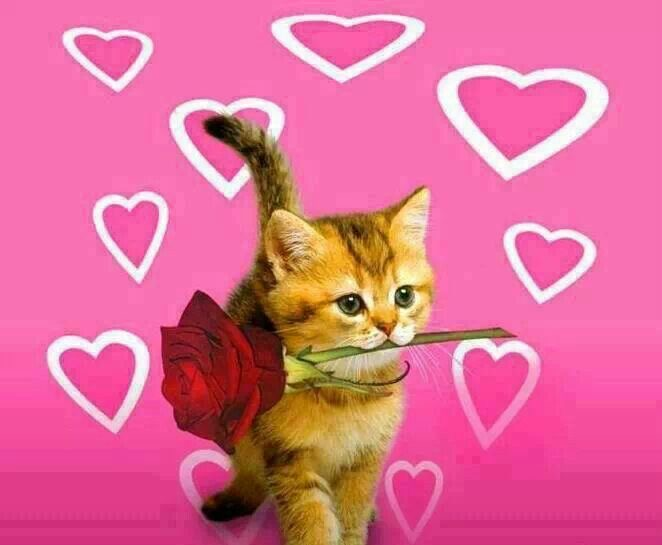

In [1]:
from IPython.display import Image, display

display(Image(filename="IMG_5059.JPG"))

Спасибо большое за дз!! Оно было очень интересное, для меня необычно было работать с долгими экспериментами и я узнала действительно много нового для себя!